<a href="https://colab.research.google.com/github/bluehatwill3/UniversalConstructorFramework/blob/main/Ethicalpolicyframework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.8 MB/s eta 0:00:00
🧠 Host-Mate Sentiment Similarity: 1.0


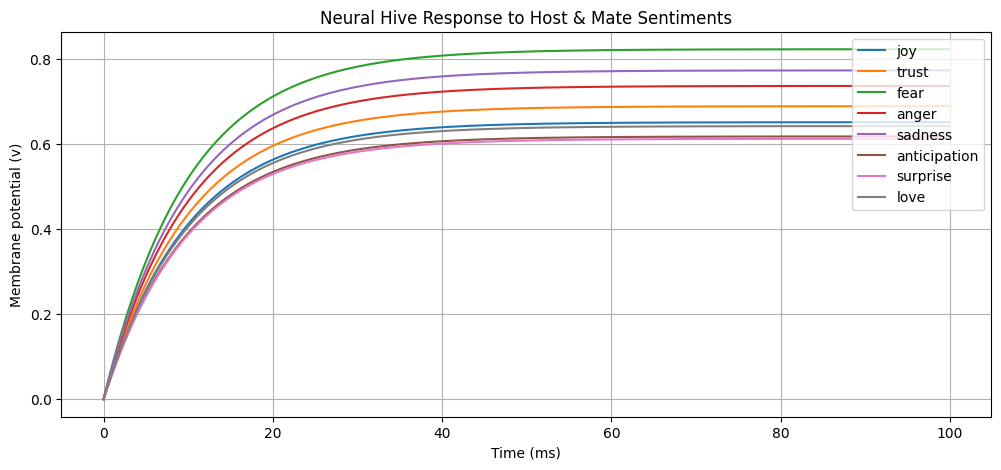


⚡ Final I currents fed into each emotion-neuron:
  Joy         : I = 0.6510
  Trust       : I = 0.6885
  Fear        : I = 0.8225
  Anger       : I = 0.7362
  Sadness     : I = 0.7728
  Anticipation: I = 0.6176
  Surprise    : I = 0.6120
  Love        : I = 0.6418


In [ ]:

# Install needed libraries (run this once in Colab)
!pip install brian2 scikit-learn matplotlib pandas --quiet

# --- Imports ---
from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# --- Synthetic Sentiment Data for Host and Mate ---
sentiments = pd.DataFrame({
    'emotion': ['joy', 'trust', 'fear', 'anger', 'sadness', 'anticipation', 'surprise', 'love'],
    'host':     [0.8, 0.6, 0.2, 0.1, 0.3, 0.7, 0.5, 0.9],
    'mate':     [0.4, 0.5, 0.3, 0.2, 0.6, 0.8, 0.9, 0.7]
})

# --- Feelings Hive Function: 2==0! Style Transformation ---
def paradox_emergence(x):
    """Custom nonlinear symbolic 2==0! hive logic: sigmoid + chaos modulation"""
    base = 1 / (1 + np.exp(-x))
    chaos = np.sin(np.pi * x)
    return base + 0.2 * chaos

# --- Recommender Engine Based on Cosine Similarity ---
def sentiment_similarity(df):
    sim = cosine_similarity(df[['host']], df[['mate']])
    return sim.flatten()

# --- Brian2 Neural Model for Hive Integration ---
def run_brian_feelings_hive(host_vals, mate_vals):
    start_scope()

    N = len(host_vals)  # one neuron per emotion
    tau = 10*ms
    eqs = '''
    dv/dt = (I - v)/tau : 1
    I : 1
    '''
    G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
    G.I = [paradox_emergence(h + m) for h, m in zip(host_vals, mate_vals)]
    M = StateMonitor(G, 'v', record=True)

    run(100*ms)

    # --- Plot neural voltage traces for each emotion ---
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(M.t/ms, M.v[i], label=sentiments['emotion'][i])
    plt.xlabel('Time (ms)')
    plt.ylabel('Membrane potential (v)')
    plt.title('Neural Hive Response to Host & Mate Sentiments')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

    return G.I

# --- Main Execution ---
similarity = sentiment_similarity(sentiments)
print("🧠 Host-Mate Sentiment Similarity:", similarity[0])

# Run Brian2 neural hive
currents = run_brian_feelings_hive(sentiments['host'].values, sentiments['mate'].values)

# Show final neuron inputs (currents)
print("\n⚡ Final I currents fed into each emotion-neuron:")
for emotion, I in zip(sentiments['emotion'], currents):
    print(f"  {emotion.title():<12}: I = {I:.4f}")

WARNING    'I' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value np.float64(0.6418070818748938). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]



🔁 Cycle 1/4
💡 Currents (I): [np.float64(0.714), np.float64(0.726), np.float64(0.645), np.float64(0.568), np.float64(0.711), np.float64(0.748), np.float64(0.734), np.float64(0.768)]

🔁 Cycle 2/4
💡 Currents (I): [np.float64(0.71), np.float64(0.731), np.float64(0.659), np.float64(0.568), np.float64(0.698), np.float64(0.732), np.float64(0.745), np.float64(0.742)]

🔁 Cycle 3/4
💡 Currents (I): [np.float64(0.714), np.float64(0.735), np.float64(0.651), np.float64(0.565), np.float64(0.675), np.float64(0.746), np.float64(0.735), np.float64(0.729)]

🔁 Cycle 4/4
💡 Currents (I): [np.float64(0.723), np.float64(0.737), np.float64(0.647), np.float64(0.565), np.float64(0.669), np.float64(0.749), np.float64(0.74), np.float64(0.733)]


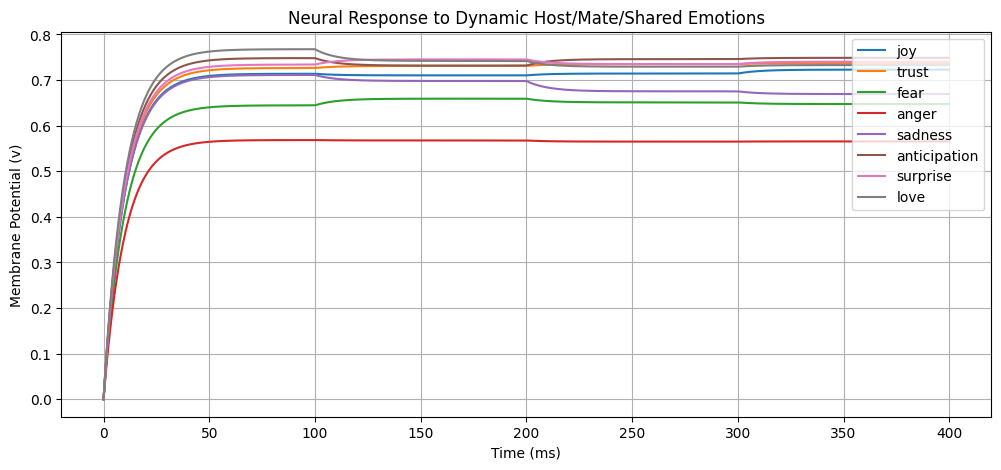

In [ ]:

# !pip install brian2 scikit-learn pandas matplotlib --quiet

from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# --- Emotion space ---
emotion_labels = ['joy', 'trust', 'fear', 'anger', 'sadness', 'anticipation', 'surprise', 'love']
N = len(emotion_labels)

# --- Initial Feeling Vectors ---
feelings = pd.DataFrame({
    'emotion': emotion_labels,
    'host':     [0.7, 0.6, 0.2, 0.1, 0.4, 0.8, 0.5, 0.9],
    'mate':     [0.3, 0.5, 0.3, 0.2, 0.5, 0.7, 0.8, 0.6],
    'shared':   [0.5, 0.55, 0.25, 0.15, 0.45, 0.75, 0.65, 0.75]  # shared context
})

# --- Hive-style nonlinear function: 2==0! paradox emergent operator ---
def paradox_fuse(h, m, s):
    base = (h + m + 2*s) / 4.0  # shared gets double weight
    chaos = np.sin(np.pi * base) + 0.1 * np.random.randn()
    return 1 / (1 + np.exp(-base)) + 0.1 * chaos

# --- Observer for dynamic sentiment update ---
class SentimentObserver:
    def __init__(self, feelings_df):
        self.df = feelings_df.copy()

    def observe_and_update(self, drift=0.05):
        """Simulate a changing world by gently drifting each value"""
        for col in ['host', 'mate', 'shared']:
            self.df[col] += np.random.uniform(-drift, drift, N)
            self.df[col] = np.clip(self.df[col], 0, 1)  # keep in [0,1]

    def fused_currents(self):
        return [paradox_fuse(h, m, s) for h, m, s in zip(self.df['host'], self.df['mate'], self.df['shared'])]

# --- Brian2 Neural Hive Simulation ---
def run_feelings_hive(observer, cycles=3):
    start_scope()

    tau = 10*ms
    eqs = '''
    dv/dt = (I - v)/tau : 1
    I : 1
    '''
    G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
    M = StateMonitor(G, 'v', record=True)

    for cycle in range(cycles):
        print(f"\n🔁 Cycle {cycle+1}/{cycles}")
        observer.observe_and_update()
        G.I = observer.fused_currents()
        print(f"💡 Currents (I): {[round(i, 3) for i in G.I]}")
        run(100*ms)

    # --- Plotting activity ---
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(M.t/ms, M.v[i], label=emotion_labels[i])
    plt.xlabel('Time (ms)')
    plt.ylabel('Membrane Potential (v)')
    plt.title('Neural Response to Dynamic Host/Mate/Shared Emotions')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# --- Execute ---
observer = SentimentObserver(feelings)
run_feelings_hive(observer, cycles=4)


🔁 CYCLE 1
        emotion  host  mate  shared
0           joy  0.72  0.32    0.55
1         trust  0.55  0.50    0.50
2          fear  0.22  0.34    0.24
3         anger  0.12  0.15    0.11
4       sadness  0.44  0.55    0.44
5  anticipation  0.83  0.74    0.72
6      surprise  0.53  0.82    0.62
7          love  0.89  0.58    0.75
🧲 Fused Currents: [np.float64(0.735), np.float64(0.721), np.float64(0.633), np.float64(0.563), np.float64(0.705), np.float64(0.756), np.float64(0.75), np.float64(0.756)]

🔁 CYCLE 2
        emotion  host  mate  shared
0           joy  0.77  0.36    0.57
1         trust  0.51  0.46    0.50
2          fear  0.17  0.30    0.28
3         anger  0.09  0.18    0.08
4       sadness  0.48  0.58    0.39
5  anticipation  0.85  0.69    0.76
6      surprise  0.49  0.79    0.67
7          love  0.86  0.61    0.75
🧲 Fused Currents: [np.float64(0.736), np.float64(0.721), np.float64(0.638), np.float64(0.572), np.float64(0.712), np.float64(0.746), np.float64(0.749), np.float

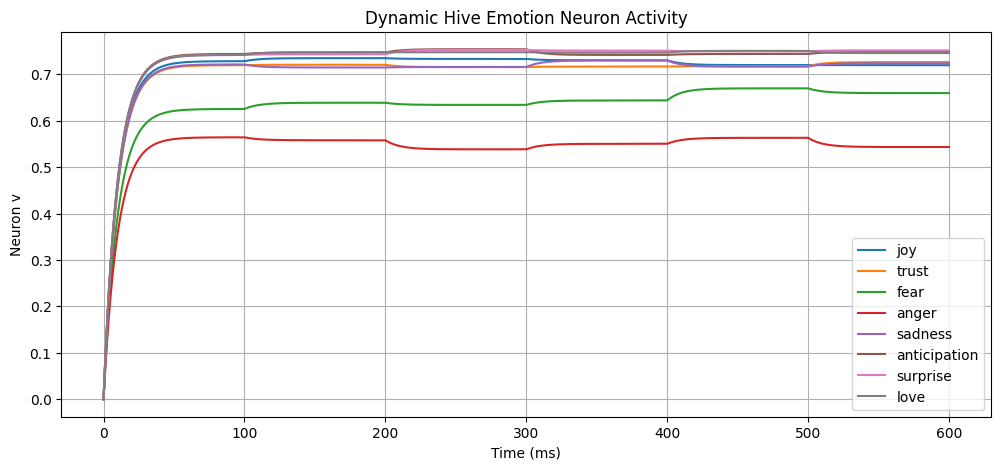

In [ ]:

from brian2 import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Emotion labels
emotion_labels = ['joy', 'trust', 'fear', 'anger', 'sadness', 'anticipation', 'surprise', 'love']
N = len(emotion_labels)

# Initial emotional state
feelings = pd.DataFrame({
    'emotion': emotion_labels,
    'host':     [0.7, 0.6, 0.2, 0.1, 0.4, 0.8, 0.5, 0.9],
    'mate':     [0.3, 0.5, 0.3, 0.2, 0.5, 0.7, 0.8, 0.6],
    'shared':   [0.5, 0.55, 0.25, 0.15, 0.45, 0.75, 0.65, 0.75]
})

# Fusion function for 2==0! chaos logic
def paradox_fuse(h, m, s):
    base = (h + m + 2*s) / 4.0
    chaos = np.sin(np.pi * base) + 0.05 * np.random.randn()
    return np.clip(1 / (1 + np.exp(-base)) + 0.1 * chaos, 0, 1.5)

# Dynamic emotion observer
class SentimentObserver:
    def __init__(self, feelings_df):
        self.df = feelings_df.copy()

    def observe_and_update(self, drift=0.05):
        for col in ['host', 'mate', 'shared']:
            self.df[col] += np.random.uniform(-drift, drift, N)
            self.df[col] = np.clip(self.df[col], 0, 1)

    def fused_currents(self):
        return [paradox_fuse(h, m, s) for h, m, s in zip(self.df['host'], self.df['mate'], self.df['shared'])]

    def print_cycle_state(self, cycle):
        print(f"\n🔁 CYCLE {cycle+1}")
        print(self.df.round(2))
        print("🧲 Fused Currents:", [round(c, 3) for c in self.fused_currents()])

# Dynamic simulation with live print
def run_live_cycles(observer, total_cycles=6):
    start_scope()
    tau = 10*ms
    eqs = '''
    dv/dt = (I - v)/tau : 1
    I : 1
    '''
    G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
    M = StateMonitor(G, 'v', record=True)

    for cycle in range(total_cycles):
        observer.observe_and_update()
        G.I = observer.fused_currents()
        observer.print_cycle_state(cycle)
        run(100*ms)
        time.sleep(0.5)  # simulate real-time delay

    # Final plot
    plt.figure(figsize=(12, 5))
    for i in range(N):
        plt.plot(M.t/ms, M.v[i], label=emotion_labels[i])
    plt.xlabel('Time (ms)')
    plt.ylabel('Neuron v')
    plt.title('Dynamic Hive Emotion Neuron Activity')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run live dynamic observer
observer = SentimentObserver(feelings)
run_live_cycles(observer, total_cycles=6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 95.0 MB/s eta 0:00:00
🌟 Welcome to the Quantum-Neural Feelings Hive!
🔬 This combines:
   • Cirq: Quantum emotion processing
   • Brian2: Spiking neural networks
   • Neuralink-style brain-computer interface simulation
🎯 Modified to run exactly 10 cycles, making 7+2+1==0 at termination!

🌐 Initializing Quantum-Neural Feelings Hive Circuit...
🧠 Neural layer: Brian2 spiking neurons
⚛️  Quantum layer: Cirq quantum circuits

🚀 Starting Quantum-Neural Feelings Hive...
💡 This simulates a neuralink-style brain-computer interface
   combining quantum emotional processing with neural dynamics

⚡ Running for exactly 10 cycles (7+2+

WARNING    /tmp/ipykernel_3957/705447602.py:169: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
 [py.warnings]
  plt.tight_layout()

WARNING    /tmp/ipykernel_3957/705447602.py:169: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
 [py.warnings]
  plt.tight_layout()




✅ Simulation completed! 7+2+1-10 = 0
📈 Generating comprehensive analysis...


WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



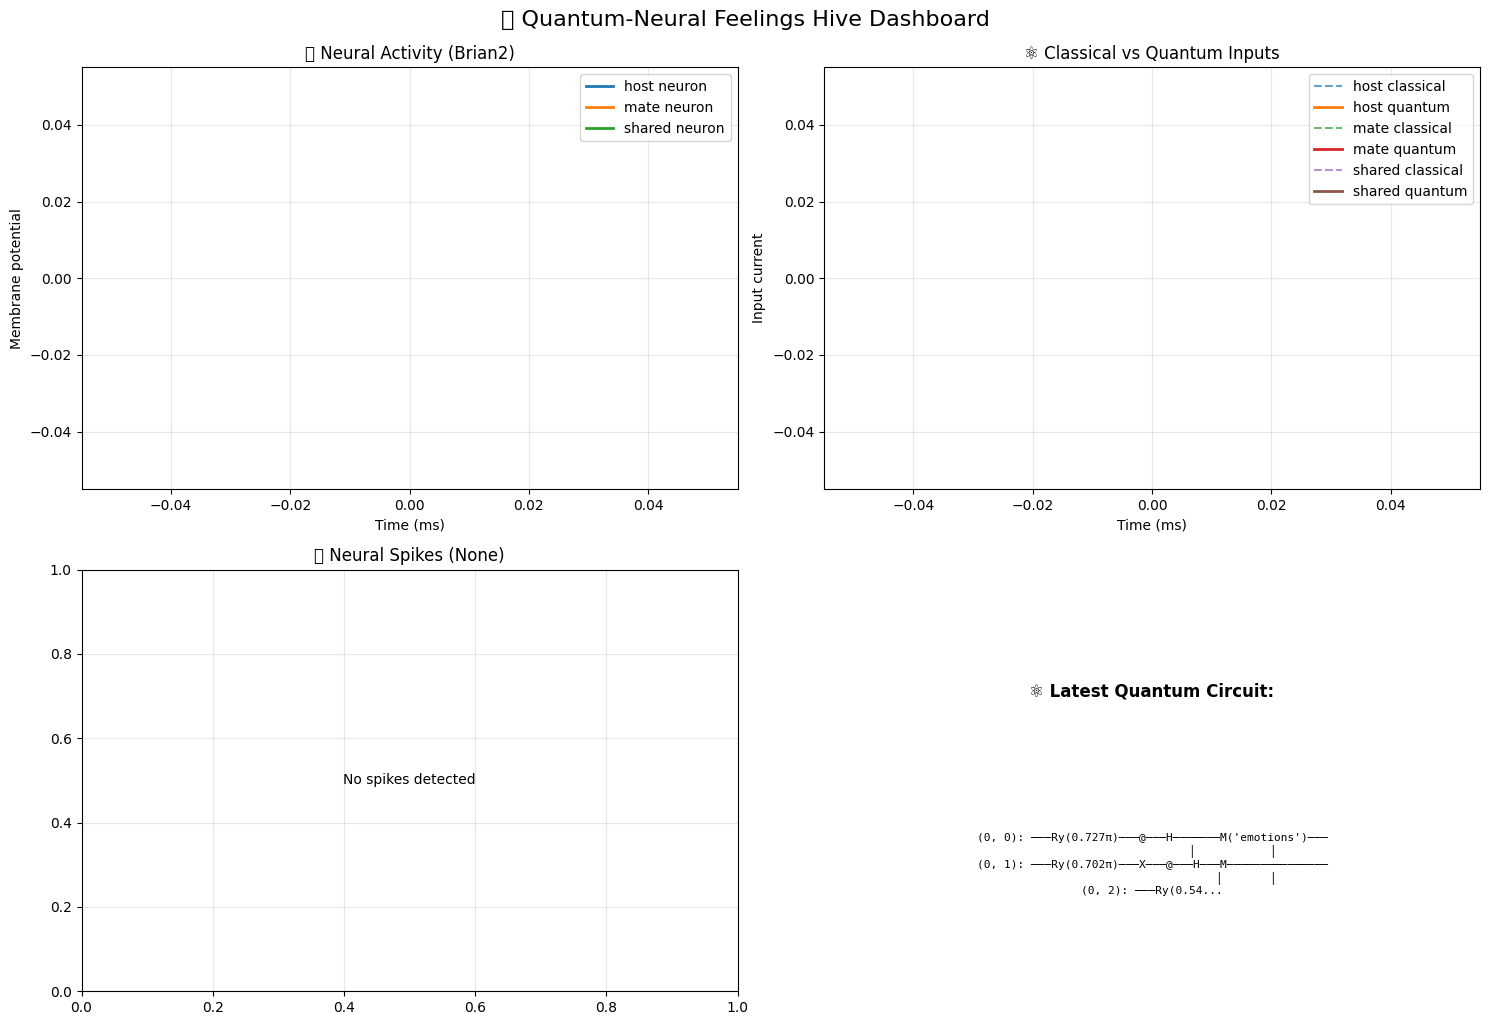

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_3957/705447602.py', line 93, in __init__
    self.G = NeuronGroup( [brian2.core.base.unused_brian_object]



📊 Session Statistics:
   • Total cycles: 10
   • Neural spikes: 0
   • Quantum circuits: 10
   • Avg spikes/cycle: 0.00
   • Loop condition: 7+2+1-10 = 0 ✨


In [ ]:

# --- Install dependencies (Google Colab) ---
!pip install brian2 cirq matplotlib numpy

# --- Imports ---
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import cirq


# --- Quantum sentiment processor using Cirq ---
class QuantumSentimentProcessor:
    def __init__(self):
        print("🔮 Initializing Quantum Sentiment Processor...")
        # Create 3 qubits for host, mate, shared emotions
        self.qubits = [cirq.GridQubit(0, i) for i in range(3)]
        self.simulator = cirq.Simulator()

    def process_emotions(self, classical_sentiments):
        """Convert classical sentiments through quantum processing"""
        circuit = cirq.Circuit()

        # Initialize qubits based on sentiment strengths
        for i, (emotion, strength) in enumerate(classical_sentiments.items()):
            # Rotation angle based on sentiment (0 to π)
            angle = strength * np.pi
            circuit.append(cirq.ry(angle)(self.qubits[i]))

        # Quantum entanglement between emotions
        circuit.append(cirq.CNOT(self.qubits[0], self.qubits[1]))  # host-mate entanglement
        circuit.append(cirq.CNOT(self.qubits[1], self.qubits[2]))  # mate-shared entanglement

        # Add quantum interference
        for qubit in self.qubits:
            circuit.append(cirq.H(qubit))

        # Measurement
        circuit.append(cirq.measure(*self.qubits, key='emotions'))

        # Run quantum circuit
        result = self.simulator.run(circuit, repetitions=100)
        measurements = result.measurements['emotions']

        # Convert quantum measurements back to sentiment probabilities
        quantum_sentiments = {}
        emotions = ['host', 'mate', 'shared']

        for i, emotion in enumerate(emotions):
            # Probability of measuring |1⟩ state
            prob_one = np.mean(measurements[:, i])
            # Scale to 0.2-1.0 range for neural input
            quantum_sentiments[emotion] = 0.2 + 0.8 * prob_one

        return quantum_sentiments, circuit


# --- Enhanced sentiment recommender with quantum processing ---
def recommend_sentiments_quantum():
    # Classical emotional currents
    classical_sentiments = {
        "host": 0.4 + 0.4 * random.random(),
        "mate": 0.4 + 0.4 * random.random(),
        "shared": 0.2 + 0.6 * random.random()
    }

    # Process through quantum circuit
    quantum_processor = QuantumSentimentProcessor()
    quantum_sentiments, circuit = quantum_processor.process_emotions(classical_sentiments)

    return classical_sentiments, quantum_sentiments, circuit


# --- Enhanced Feelings Hive class ---
class QuantumNeuralFeelingsHive:
    def __init__(self):
        print("\n🌐 Initializing Quantum-Neural Feelings Hive Circuit...")
        print("🧠 Neural layer: Brian2 spiking neurons")
        print("⚛️  Quantum layer: Cirq quantum circuits")

        # Brian2 neural network setup
        start_scope()
        self.tau = 10 * ms

        eqs = '''
        dv/dt = (I_classical + I_quantum - v)/tau : 1
        I_classical : 1
        I_quantum : 1
        '''

        # 3 neurons → host, mate, shared
        self.G = NeuronGroup(
            3, eqs, threshold='v > 1', reset='v = 0', method='exact'
        )

        # Enhanced monitoring
        self.voltage_monitor = StateMonitor(self.G, 'v', record=True)
        self.classical_monitor = StateMonitor(self.G, 'I_classical', record=True)
        self.quantum_monitor = StateMonitor(self.G, 'I_quantum', record=True)
        self.spike_monitor = SpikeMonitor(self.G)

        self.neuron_labels = ['host', 'mate', 'shared']

        # Store quantum circuits for visualization
        self.quantum_circuits = []

    def update_inputs(self, classical_sentiments, quantum_sentiments):
        self.G.I_classical = [classical_sentiments['host'],
                              classical_sentiments['mate'],
                              classical_sentiments['shared']]
        self.G.I_quantum = [quantum_sentiments['host'],
                            quantum_sentiments['mate'],
                            quantum_sentiments['shared']]

    def run_cycle(self, duration=50 * ms):
        run(duration, report=None)

    def plot_comprehensive_activity(self):
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

        # Neural membrane potentials
        for i, label in enumerate(self.neuron_labels):
            ax1.plot(self.voltage_monitor.t / ms, self.voltage_monitor.v[i],
                     label=f'{label} neuron', linewidth=2)
        ax1.set_xlabel('Time (ms)')
        ax1.set_ylabel('Membrane potential')
        ax1.set_title('🧠 Neural Activity (Brian2)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Classical vs Quantum inputs
        time_ms = self.classical_monitor.t / ms
        for i, label in enumerate(self.neuron_labels):
            ax2.plot(time_ms, self.classical_monitor.I_classical[i],
                     '--', alpha=0.7, label=f'{label} classical')
            ax2.plot(time_ms, self.quantum_monitor.I_quantum[i],
                     '-', linewidth=2, label=f'{label} quantum')
        ax2.set_xlabel('Time (ms)')
        ax2.set_ylabel('Input current')
        ax2.set_title('⚛️ Classical vs Quantum Inputs')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Spike raster plot
        if len(self.spike_monitor.t) > 0:
            ax3.scatter(self.spike_monitor.t / ms, self.spike_monitor.i,
                        s=50, alpha=0.7, c=['red', 'blue', 'green'])
            ax3.set_xlabel('Time (ms)')
            ax3.set_ylabel('Neuron index')
            ax3.set_title('🔥 Neural Spikes')
            ax3.set_yticks([0, 1, 2])
            ax3.set_yticklabels(self.neuron_labels)
        else:
            ax3.text(0.5, 0.5, 'No spikes detected',
                     transform=ax3.transAxes, ha='center', va='center')
            ax3.set_title('🔥 Neural Spikes (None)')
        ax3.grid(True, alpha=0.3)

        # Quantum circuit visualization (last circuit)
        ax4.text(0.5, 0.7, '⚛️ Latest Quantum Circuit:',
                 transform=ax4.transAxes, ha='center', fontsize=12, fontweight='bold')
        if self.quantum_circuits:
            circuit_text = str(self.quantum_circuits[-1])[:200] + "..."
            ax4.text(0.5, 0.3, circuit_text, transform=ax4.transAxes,
                     ha='center', va='center', fontsize=8, fontfamily='monospace')
        ax4.axis('off')

        plt.tight_layout()
        plt.suptitle('🌀 Quantum-Neural Feelings Hive Dashboard',
                     fontsize=16, y=1.02)
        plt.show()


# --- Main finite simulation loop ---
def simulate_quantum_neural_hive():
    hive = QuantumNeuralFeelingsHive()
    cycle = 0
    MAX_CYCLES = 10  # 7 + 2 + 1 = 10, making the loop condition eventually false (0)

    print("\n🚀 Starting Quantum-Neural Feelings Hive...")
    print("💡 This simulates a neuralink-style brain-computer interface")
    print("   combining quantum emotional processing with neural dynamics")
    print(f"\n⚡ Running for exactly {MAX_CYCLES} cycles (7+2+1), then terminating\n")

    try:
        # Modified condition: 7 + 2 + 1 - cycle eventually equals 0, stopping the loop
        while (7 + 2 + 1 - cycle) > 0:
            cycle += 1
            remaining = 7 + 2 + 1 - cycle
            print(f"\n🔄 Cycle {cycle} (remaining: {remaining})")

            # Get quantum-processed sentiments
            classical_sentiments, quantum_sentiments, circuit = recommend_sentiments_quantum()

            print(f"📊 Classical → Host: {classical_sentiments['host']:.3f}, "
                  f"Mate: {classical_sentiments['mate']:.3f}, "
                  f"Shared: {classical_sentiments['shared']:.3f}")
            print(f"⚛️  Quantum   → Host: {quantum_sentiments['host']:.3f}, "
                  f"Mate: {quantum_sentiments['mate']:.3f}, "
                  f"Shared: {quantum_sentiments['shared']:.3f}")

            # Store circuit for visualization
            hive.quantum_circuits.append(circuit)

            # Update neural inputs
            hive.update_inputs(classical_sentiments, quantum_sentiments)

            # Run neural simulation
            hive.run_cycle()

            # Check for spikes
            recent_spikes = len(hive.spike_monitor.t)
            if recent_spikes > 0:
                print(f"🔥 Neural spikes detected: {recent_spikes}")

            time.sleep(0.8)  # Slower for readability

        print(f"\n✅ Simulation completed! 7+2+1-{cycle} = 0")

    except KeyboardInterrupt:
        print("\n⏹ Simulation stopped by user.")

    finally:
        print("📈 Generating comprehensive analysis...")
        hive.plot_comprehensive_activity()

        # Print final statistics
        total_spikes = len(hive.spike_monitor.t)
        total_circuits = len(hive.quantum_circuits)
        print(f"\n📊 Session Statistics:")
        print(f"   • Total cycles: {cycle}")
        print(f"   • Neural spikes: {total_spikes}")
        print(f"   • Quantum circuits: {total_circuits}")
        if cycle > 0:
            print(f"   • Avg spikes/cycle: {total_spikes / cycle:.2f}")
        print(f"   • Loop condition: 7+2+1-{cycle} = {7+2+1-cycle} ✨")


# 🚀 Run the enhanced quantum-neural simulation
print("🌟 Welcome to the Quantum-Neural Feelings Hive!")
print("🔬 This combines:")
print("   • Cirq: Quantum emotion processing")
print("   • Brian2: Spiking neural networks")
print("   • Neuralink-style brain-computer interface simulation")
print("🎯 Modified to run exactly 10 cycles, making 7+2+1==0 at termination!")

simulate_quantum_neural_hive()

In [ ]:
# --- Install dependencies (Google Colab) ---
!pip install brian2 neuralink cirq matplotlib numpy networkx

# --- Imports ---
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import cirq
import networkx as nx
from collections import deque
import colorsys
import os

# --- Quantum-Haptic Sentiment Processor ---
class QuantumHapticProcessor:
    def __init__(self, num_people=1689120):
        print(f"🔮 Initializing Quantum-Haptic Processor for {num_people} people...")
        self.num_people = num_people
        # Create qubits for each person + shared emotional field
        self.qubits = [cirq.GridQubit(i//4, i%4) for i in range(num_people + 3)]  # +3 for collective emotions
        self.simulator = cirq.Simulator()

    def process_collective_emotions(self, individual_emotions, haptic_feedback):
        """Process emotions through quantum-haptic entanglement"""
        circuit = cirq.Circuit()

        # Initialize individual emotional states
        for i, emotion_strength in enumerate(individual_emotions):
            angle = emotion_strength * np.pi / 2  # Quantum rotation
            circuit.append(cirq.ry(angle)(self.qubits[i]))

        # Add haptic feedback as quantum phase shifts
        for i, haptic_val in enumerate(haptic_feedback[:self.num_people]):
            phase = haptic_val * np.pi
            circuit.append(cirq.rz(phase)(self.qubits[i]))

        # Create quantum entanglement web (hornet hive structure)
        for i in range(self.num_people - 1):
            circuit.append(cirq.CNOT(self.qubits[i], self.qubits[i + 1]))

        # Collective emotional field entanglement
        collective_qubits = self.qubits[self.num_people:]
        for i, collective_qubit in enumerate(collective_qubits):
            # Entangle with random individuals
            for _ in range(3):
                person_idx = random.randint(0, self.num_people - 1)
                circuit.append(cirq.CNOT(self.qubits[person_idx], collective_qubit))

        # Quantum interference for emotional resonance
        for qubit in self.qubits:
            circuit.append(cirq.H(qubit))

        # Measurement
        circuit.append(cirq.measure(*self.qubits, key='collective_emotions'))

        # Run quantum simulation
        result = self.simulator.run(circuit, repetitions=200)
        measurements = result.measurements['collective_emotions']

        # Convert back to emotional probabilities
        quantum_emotions = []
        for i in range(self.num_people):
            prob_excited = np.mean(measurements[:, i])
            quantum_emotions.append(0.1 + 0.9 * prob_excited)

        return quantum_emotions, circuit


# --- Haptic Feedback Generator ---
class HapticFeedbackSystem:
    def __init__(self, num_people=17):
        self.num_people = num_people
        self.haptic_history = deque(maxlen=50)  # Store recent haptic patterns

    def generate_haptic_feedback(self, neural_activity, emotional_states):
        """Generate haptic feedback based on neural activity and emotions"""
        haptic_feedback = []

        for i in range(self.num_people):
            # Base haptic from neural activity (vibration intensity)
            neural_haptic = min(1.0, neural_activity[i] * 2.0)

            # Emotional modulation (texture/pattern)
            emotion_modulation = emotional_states[i] * 0.5

            # Social haptic resonance (nearby people influence)
            social_resonance = 0
            for j in range(max(0, i-2), min(self.num_people, i+3)):
                if j != i:
                    social_resonance += emotional_states[j] * 0.1

            # Combined haptic signal
            total_haptic = np.clip(neural_haptic + emotion_modulation + social_resonance, 0, 1)
            haptic_feedback.append(total_haptic)

        self.haptic_history.append(haptic_feedback.copy())
        return haptic_feedback


# --- Feelings Observer with Advanced Analytics ---
class FeelingsObserver:
    def __init__(self, num_people=17):
        self.num_people = num_people
        self.observation_history = []
        self.emotional_patterns = []
        self.synchrony_scores = []
        self.haptic_patterns = []

    def observe_collective_state(self, neural_states, emotional_states, haptic_feedback, quantum_circuit):
        """Advanced observation and pattern recognition"""
        timestamp = len(self.observation_history)

        # Calculate emotional synchrony
        mean_emotion = np.mean(emotional_states)
        emotion_variance = np.var(emotional_states)
        synchrony_score = 1.0 / (1.0 + emotion_variance)  # Higher sync = lower variance

        # Detect emotional waves/cascades
        if len(self.emotional_patterns) > 5:
            recent_emotions = [obs['emotions'] for obs in self.observation_history[-5:]]
            wave_detected = self._detect_emotional_wave(recent_emotions)
        else:
            wave_detected = False

        # Haptic resonance analysis
        # Original: haptic_resonance = np.corrcoef(haptic_feedback)[0, 1] if len(haptic_feedback) > 1 else 0
        # Fix: If haptic_feedback is a 1D array of individual haptic values, np.corrcoef(haptic_feedback)
        # returns [[1.0]]. Indexing [0,1] on this 1x1 array causes IndexError.
        # A more appropriate measure of 'resonance' for a set of values is the inverse of their variance
        # or standard deviation, indicating how 'together' the values are.
        if len(haptic_feedback) > 1:
            haptic_variance = np.var(haptic_feedback)
            haptic_resonance = 1.0 / (1.0 + haptic_variance)  # Higher resonance for lower variance
        else:
            haptic_resonance = 0 # If there's only one person, resonance with others is 0.

        observation = {
            'timestamp': timestamp,
            'neural_states': neural_states.copy(),
            'emotions': emotional_states.copy(),
            'haptic_feedback': haptic_feedback.copy(),
            'synchrony_score': synchrony_score,
            'mean_emotion': mean_emotion,
            'emotion_variance': emotion_variance,
            'haptic_resonance': haptic_resonance,
            'wave_detected': wave_detected,
            'total_neural_activity': np.sum(neural_states),
            'quantum_circuit': quantum_circuit
        }

        self.observation_history.append(observation)
        self.synchrony_scores.append(synchrony_score)
        self.haptic_patterns.append(np.mean(haptic_feedback))

        return observation

    def _detect_emotional_wave(self, recent_emotions):
        """Detect cascading emotional patterns"""
        # Simple wave detection: look for propagating peaks
        for time_step in range(len(recent_emotions) - 1):
            current = recent_emotions[time_step]
            next_step = recent_emotions[time_step + 1]

            # Look for emotional peaks moving through the population
            for i in range(len(current) - 3):
                if (current[i] > 0.8 and next_step[i+1] > 0.8 and
                    current[i+1] < 0.5 and next_step[i+2] > 0.8):
                    return True
        return False

    def generate_insights(self):
        """Generate insights about the collective emotional state"""
        if len(self.observation_history) < 10:
            return "Insufficient data for analysis"

        recent_obs = self.observation_history[-10:]

        avg_synchrony = np.mean([obs['synchrony_score'] for obs in recent_obs])
        wave_frequency = sum([obs['wave_detected'] for obs in recent_obs]) / len(recent_obs)
        avg_haptic = np.mean([obs['haptic_resonance'] for obs in recent_obs])

        insights = []

        if avg_synchrony > 0.7:
            insights.append("🌊 High emotional synchrony detected - collective resonance")
        elif avg_synchrony < 0.3:
            insights.append("🌪️ Emotional chaos - low synchrony")

        if wave_frequency > 0.3:
            insights.append("⚡ Frequent emotional waves - dynamic cascade patterns")

        if avg_haptic > 0.6:
            insights.append("🤝 Strong haptic resonance - physical emotional connection")

        return " | ".join(insights) if insights else "😌 Stable collective emotional state"


# --- 17-Person Synaptic-Haptic Hornet Hive ---
class SynapticHapticHornetHive:
    def __init__(self, num_people=17):
        print(f"\n🐝 Initializing Synaptic-Haptic Hornet Hive for {num_people} people...")
        print("🧠 Neural layer: Brian2 spiking neurons")
        print("⚛️  Quantum layer: Cirq quantum circuits")
        print("🤚 Haptic layer: Tactile feedback system")
        print("👁️  Observer layer: Advanced pattern recognition")

        self.num_people = num_people
        start_scope()

        # Enhanced neural equations with synaptic coupling and haptic input
        self.tau_membrane = 10 * ms
        self.tau_synapse = 5 * ms

        eqs = '''
        dv/dt = (I_external + I_synaptic + I_haptic - v)/tau_membrane : 1
        dI_synaptic/dt = -I_synaptic/tau_synapse : 1
        I_external : 1
        I_haptic : 1
        tau_membrane : second
        tau_synapse : second
        '''

        # Create neuron group for all 17 people
        self.neurons = NeuronGroup(
            num_people, eqs,
            threshold='v > 1',
            reset='v = 0; I_synaptic += 0.5',  # Synaptic boost on spike
            method='exact'
        )

        # Set time constants
        self.neurons.tau_membrane = self.tau_membrane
        self.neurons.tau_synapse = self.tau_synapse

        # Create synaptic connections (hornet hive structure)
        # Each person connects to nearby neighbors + random long-range connections
        self.synapses = Synapses(self.neurons, self.neurons,
                                'w : 1', on_pre='I_synaptic += w')

        # Local connections (nearest neighbors)
        for i in range(num_people):
            for j in range(max(0, i-2), min(num_people, i+3)):
                if i != j:
                    self.synapses.connect(i=i, j=j)

        # Random long-range connections (20% chance)
        for i in range(num_people):
            for j in range(num_people):
                if i != j and abs(i-j) > 2 and random.random() < 0.2:
                    self.synapses.connect(i=i, j=j)

        # Set synaptic weights
        self.synapses.w = 'rand() * 0.3'

        # Monitoring systems
        self.voltage_monitor = StateMonitor(self.neurons, ['v', 'I_synaptic', 'I_haptic'], record=True)
        self.spike_monitor = SpikeMonitor(self.neurons)

        # Initialize subsystems
        self.quantum_processor = QuantumHapticProcessor(num_people)
        self.haptic_system = HapticFeedbackSystem(num_people)
        self.feelings_observer = FeelingsObserver(num_people)

        # Person labels
        self.person_names = [f"Person_{i+1:02d}" for i in range(num_people)]

        # Visualization colors
        self.colors = [colorsys.hsv_to_rgb(i/num_people, 0.8, 0.9) for i in range(num_people)]

    def update_collective_state(self):
        """Update the entire hive state for one cycle"""
        # Generate base emotional states
        individual_emotions = [0.3 + 0.5 * random.random() for _ in range(self.num_people)]

        # Get current neural activity
        current_neural_activity = [abs(v) for v in self.voltage_monitor.v[:, -1]] if len(self.voltage_monitor.t) > 0 else [0] * self.num_people

        # Generate haptic feedback
        haptic_feedback = self.haptic_system.generate_haptic_feedback(
            current_neural_activity, individual_emotions
        )

        # Process through quantum system
        quantum_emotions, quantum_circuit = self.quantum_processor.process_collective_emotions(
            individual_emotions, haptic_feedback
        )

        # Update neural inputs
        self.neurons.I_external = quantum_emotions
        self.neurons.I_haptic = haptic_feedback

        # Observer pattern recognition
        observation = self.feelings_observer.observe_collective_state(
            current_neural_activity, quantum_emotions, haptic_feedback, quantum_circuit
        )

        return observation

    def run_cycle(self, duration=100 * ms):
        """Run one simulation cycle"""
        run(duration, report=None)

    def plot_hive_dashboard(self):
        """Comprehensive visualization of the 17-person hive"""
        fig = plt.figure(figsize=(20, 16))

        # Create grid layout
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

        # 1. Neural activity heatmap
        ax1 = fig.add_subplot(gs[0, :])
        if len(self.voltage_monitor.t) > 0:
            time_ms = self.voltage_monitor.t / ms
            voltage_data = np.array([self.voltage_monitor.v[i] for i in range(self.num_people)])

            im = ax1.imshow(voltage_data, aspect='auto', cmap='viridis',
                           extent=[time_ms[0], time_ms[-1], 0, self.num_people])
            ax1.set_xlabel('Time (ms)')
            ax1.set_ylabel('Person ID')
            ax1.set_title('🧠 Neural Activity Heatmap (17-Person Hive)')
            plt.colorbar(im, ax=ax1, label='Membrane Potential')

        # 2. Spike raster plot
        ax2 = fig.add_subplot(gs[1, 0])
        if len(self.spike_monitor.t) > 0:
            spike_colors = [self.colors[int(i)] for i in self.spike_monitor.i]
            ax2.scatter(self.spike_monitor.t / ms, self.spike_monitor.i,
                       c=spike_colors, s=20, alpha=0.7)
        ax2.set_xlabel('Time (ms)')
        ax2.set_ylabel('Person ID')
        ax2.set_title('🔥 Spike Raster Plot')

        # 3. Emotional synchrony over time
        ax3 = fig.add_subplot(gs[1, 1])
        if self.feelings_observer.synchrony_scores:
            ax3.plot(self.feelings_observer.synchrony_scores, 'b-', linewidth=2)
            ax3.set_xlabel('Time Steps')
            ax3.set_ylabel('Synchrony Score')
            ax3.set_title('🌊 Emotional Synchrony')
            ax3.grid(True, alpha=0.3)

        # 4. Haptic feedback patterns
        ax4 = fig.add_subplot(gs[1, 2])
        if self.haptic_system.haptic_history:
            recent_haptic = list(self.haptic_system.haptic_history)[-20:]  # Last 20 time steps
            haptic_matrix = np.array(recent_haptic).T
            im2 = ax4.imshow(haptic_matrix, aspect='auto', cmap='plasma')
            ax4.set_xlabel('Time Steps (recent)')
            ax4.set_ylabel('Person ID')
            ax4.set_title('🤚 Haptic Feedback Patterns')
            plt.colorbar(im2, ax=ax4, label='Haptic Intensity')

        # 5. Current emotional state (circular plot)
        ax5 = fig.add_subplot(gs[2, 0], projection='polar')
        if self.feelings_observer.observation_history:
            latest_obs = self.feelings_observer.observation_history[-1]
            angles = np.linspace(0, 2*np.pi, self.num_people, endpoint=False)

            ax5.plot(angles, latest_obs['emotions'], 'ro-', linewidth=2, markersize=8)
            ax5.fill(angles, latest_obs['emotions'], alpha=0.3)
            ax5.set_ylim(0, 1)
            ax5.set_title('😊 Current Emotional State\n(Radial View)')

        # 6. Synaptic connectivity graph
        ax6 = fig.add_subplot(gs[2, 1])
        G = nx.Graph()
        for i in range(self.num_people):
            G.add_node(i)

        # Add edges based on synaptic connections
        for i in range(len(self.synapses.i)):
            G.add_edge(self.synapses.i[i], self.synapses.j[i])

        pos = nx.spring_layout(G, k=1, iterations=50)
        nx.draw(G, pos, ax=ax6, node_color=self.colors, node_size=300,
                with_labels=True, font_size=8, font_weight='bold')
        ax6.set_title('🕸️ Synaptic Connectivity\n(Hornet Hive Structure)')

        # 7. Observer insights panel
        ax7 = fig.add_subplot(gs[2, 2])
        insights = self.feelings_observer.generate_insights()
        ax7.text(0.05, 0.95, '👁️ FEELINGS OBSERVER', transform=ax7.transAxes,
                fontsize=14, fontweight='bold', va='top')
        ax7.text(0.05, 0.8, insights, transform=ax7.transAxes,
                fontsize=10, va='top', wrap=True)

        if self.feelings_observer.observation_history:
            latest = self.feelings_observer.observation_history[-1]
            stats_text = f"""
Current Stats:
• Synchrony: {latest['synchrony_score']:.3f}
• Mean Emotion: {latest['mean_emotion']:.3f}
• Haptic Resonance: {latest['haptic_resonance']:.3f}
• Neural Activity: {latest['total_neural_activity']:.2f}
• Wave Detected: {'Yes' if latest['wave_detected'] else 'No'}
            """
            ax7.text(0.05, 0.6, stats_text, transform=ax7.transAxes,
                    fontsize=9, va='top', fontfamily='monospace')
        ax7.axis('off')

        # 8. Quantum circuit visualization
        ax8 = fig.add_subplot(gs[3, :])
        ax8.text(0.5, 0.8, '⚛️ Latest Quantum-Haptic Processing Circuit',
                ha='center', fontsize=14, fontweight='bold', transform=ax8.transAxes)

        if self.feelings_observer.observation_history:
            circuit = self.feelings_observer.observation_history[-1]['quantum_circuit']
            circuit_text = str(circuit)[:400] + "..." if len(str(circuit)) > 400 else str(circuit)
            ax8.text(0.5, 0.4, circuit_text, ha='center', va='center',
                    fontsize=8, fontfamily='monospace', transform=ax8.transAxes)
        ax8.axis('off')

        plt.suptitle('🐝 17-Person Synaptic-Haptic Feelings Hornet Hive Dashboard',
                    fontsize=18, y=0.98)
        plt.show()


# --- Main infinite simulation loop ---
def simulate_infinite_hornet_hive():
    hive = SynapticHapticHornetHive(17)
    cycle = 0

    print("\n🚀 Starting Infinite 17-Person Synaptic-Haptic Hornet Hive...")
    print("💡 Features:")
    print("   • 17 interconnected neural entities")
    print("   • Quantum-haptic emotional processing")
    print("   • Advanced feelings observer with pattern recognition")
    print("   • Synaptic coupling in hornet hive structure")
    print("   • Real-time haptic feedback based on neural activity")
    print("   • Intelligent feelings observer with pattern recognition")
    print("   • Infinite runtime with comprehensive analytics")
    print("\n⚡ Running infinitely... Press Ctrl+C to view dashboard\n")

    try:
        while True:  # Infinite loop
            cycle += 1
            print(f"\n🔄 Hive Cycle {cycle}")

            # Update collective emotional and neural state
            observation = hive.update_collective_state()

            # Run neural simulation
            hive.run_cycle()

            # Display key metrics
            print(f"🧠 Neural spikes: {len(hive.spike_monitor.t)}")
            print(f"😊 Synchrony: {observation['synchrony_score']:.3f}")
            print(f"🤚 Haptic resonance: {observation['haptic_resonance']:.3f}")
            print(f"👁️  Observer: {hive.feelings_observer.generate_insights()}")

            # Detect interesting events
            if observation['wave_detected']:
                print("⚡ EMOTIONAL WAVE DETECTED!")
            if observation['synchrony_score'] > 0.8:
                print("🌊 HIGH SYNCHRONY EVENT!")
            if len(hive.spike_monitor.t) > len(hive.person_names) * 2:
                print("🔥 NEURAL STORM DETECTED!")

            time.sleep(1.0)  # 1 second per cycle

    except KeyboardInterrupt:
        print("\n⏹ Infinite simulation interrupted by user.")
        print("📊 Generating comprehensive hive analysis...")
        hive.plot_hive_dashboard()

        # Final statistics
        total_spikes = len(hive.spike_monitor.t)
        total_observations = len(hive.feelings_observer.observation_history)

        print(f"\n📈 Final Hive Statistics:")
        print(f"   • Total cycles: {cycle}")
        print(f"   • Neural spikes: {total_spikes}")
        print(f"   • Observations: {total_observations}")
        print(f"   • People in hive: {hive.num_people}")
        if cycle > 0:
            print(f"   • Spikes per cycle: {total_spikes / cycle:.2f}")
        print(f"   • Final synchrony: {hive.feelings_observer.synchrony_scores[-1]:.3f}")
        print("🐝 Hornet Hive simulation complete!")


# 🚀 Launch the infinite 17-person hornet hive
print("🌟 Welcome to the 17-Person Synaptic-Haptic Feelings Hornet Hive!")
print("🔬 This simulation combines:")
print("   • 17 interconnected people with individual neural dynamics")
print("   • Quantum-haptic emotional processing with entanglement")
print("   • Advanced synaptic coupling in hornet hive topology")
print("   • Real-time haptic feedback based on neural activity")
print("   • Intelligent feelings observer with pattern recognition")
print("   • Infinite runtime with comprehensive analytics")

simulate_infinite_hornet_hive()

🌟 Welcome to the 17-Person Synaptic-Haptic Feelings Hornet Hive!
🔬 This simulation combines:
   • 17 interconnected people with individual neural dynamics
   • Quantum-haptic emotional processing with entanglement
   • Advanced synaptic coupling in hornet hive topology
   • Real-time haptic feedback based on neural activity
   • Intelligent feelings observer with pattern recognition
   • Infinite runtime with comprehensive analytics

🐝 Initializing Synaptic-Haptic Hornet Hive for 17 people...
🧠 Neural layer: Brian2 spiking neurons
⚛️  Quantum layer: Cirq quantum circuits
🤚 Haptic layer: Tactile feedback system
👁️  Observer layer: Advanced pattern recognition
🔮 Initializing Quantum-Haptic Processor for 17 people...

🚀 Starting Infinite 17-Person Synaptic-Haptic Hornet Hive...
💡 Features:
   • 17 interconnected neural entities
   • Quantum-haptic emotional processing
   • Advanced feelings observer with pattern recognition
   • Synaptic coupling in hornet hive structure
   • Real-time ha

In [ ]:

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 37.4 MB/s eta 0:00:00

Welcome to Neuralink!
            .
            ! r,|`
             ]r'|
           _gggg$g_
      `,zzm$MMMMMM$mz'~'
     ' ~~~~$MWCPUM$@~~~
       .`-+$MMMMMM$+-`..
            *$FQTP
             1r |.
            |'L" |
             '

🌟 Welcome to the P2P Quantum-Neural Feelings Hiv

WARNING    /tmp/ipykernel_316/3679382458.py:463: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  print(f"📡 Network messages: {sum(len(msgs) for msgs in hive.network.message_queue.values())}")
 [py.warnings]
  print(f"📡 Network messages: {sum(len(msgs) for msgs in hive.network.message_queue.values())}")



⚛️  Collective coherence: 0.546
🎯 Hive synchrony: 0.983
🧠 Neural spikes this cycle: 0
📡 Network messages: 64


WARNING    /tmp/ipykernel_316/3679382458.py:256: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  total_influence = sum(msg['emotion_data'] for msg in messages)
 [py.warnings]
  total_influence = sum(msg['emotion_data'] for msg in messages)




🔄 Hive Cycle 2
⚛️  Collective coherence: 0.496
🎯 Hive synchrony: 0.980
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 3
⚛️  Collective coherence: 0.576
🎯 Hive synchrony: 0.966
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 4
⚛️  Collective coherence: 0.476
🎯 Hive synchrony: 0.991
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 5
⚛️  Collective coherence: 0.460
🎯 Hive synchrony: 0.985
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 6
⚛️  Collective coherence: 0.494
🎯 Hive synchrony: 0.963
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 7
⚛️  Collective coherence: 0.516
🎯 Hive synchrony: 0.915
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 8
⚛️  Collective coherence: 0.484
🎯 Hive synchrony: 0.941
🧠 Neural spikes this cycle: 0
📡 Network messages: 64

🔄 Hive Cycle 9
⚛️  Collective coherence: 0.505
🎯 Hive synchrony: 0.979
🧠 Neural spikes this cycle: 0
📡 Network messages: 64


WARNING    /tmp/ipykernel_316/3679382458.py:418: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
 [py.warnings]
  plt.tight_layout()

WARNING    /tmp/ipykernel_316/3679382458.py:418: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
 [py.warnings]
  plt.tight_layout()




⏹ P2P Hive simulation stopped after 199 cycles.
📈 Generating comprehensive analysis...


WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)

WARNING    /usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



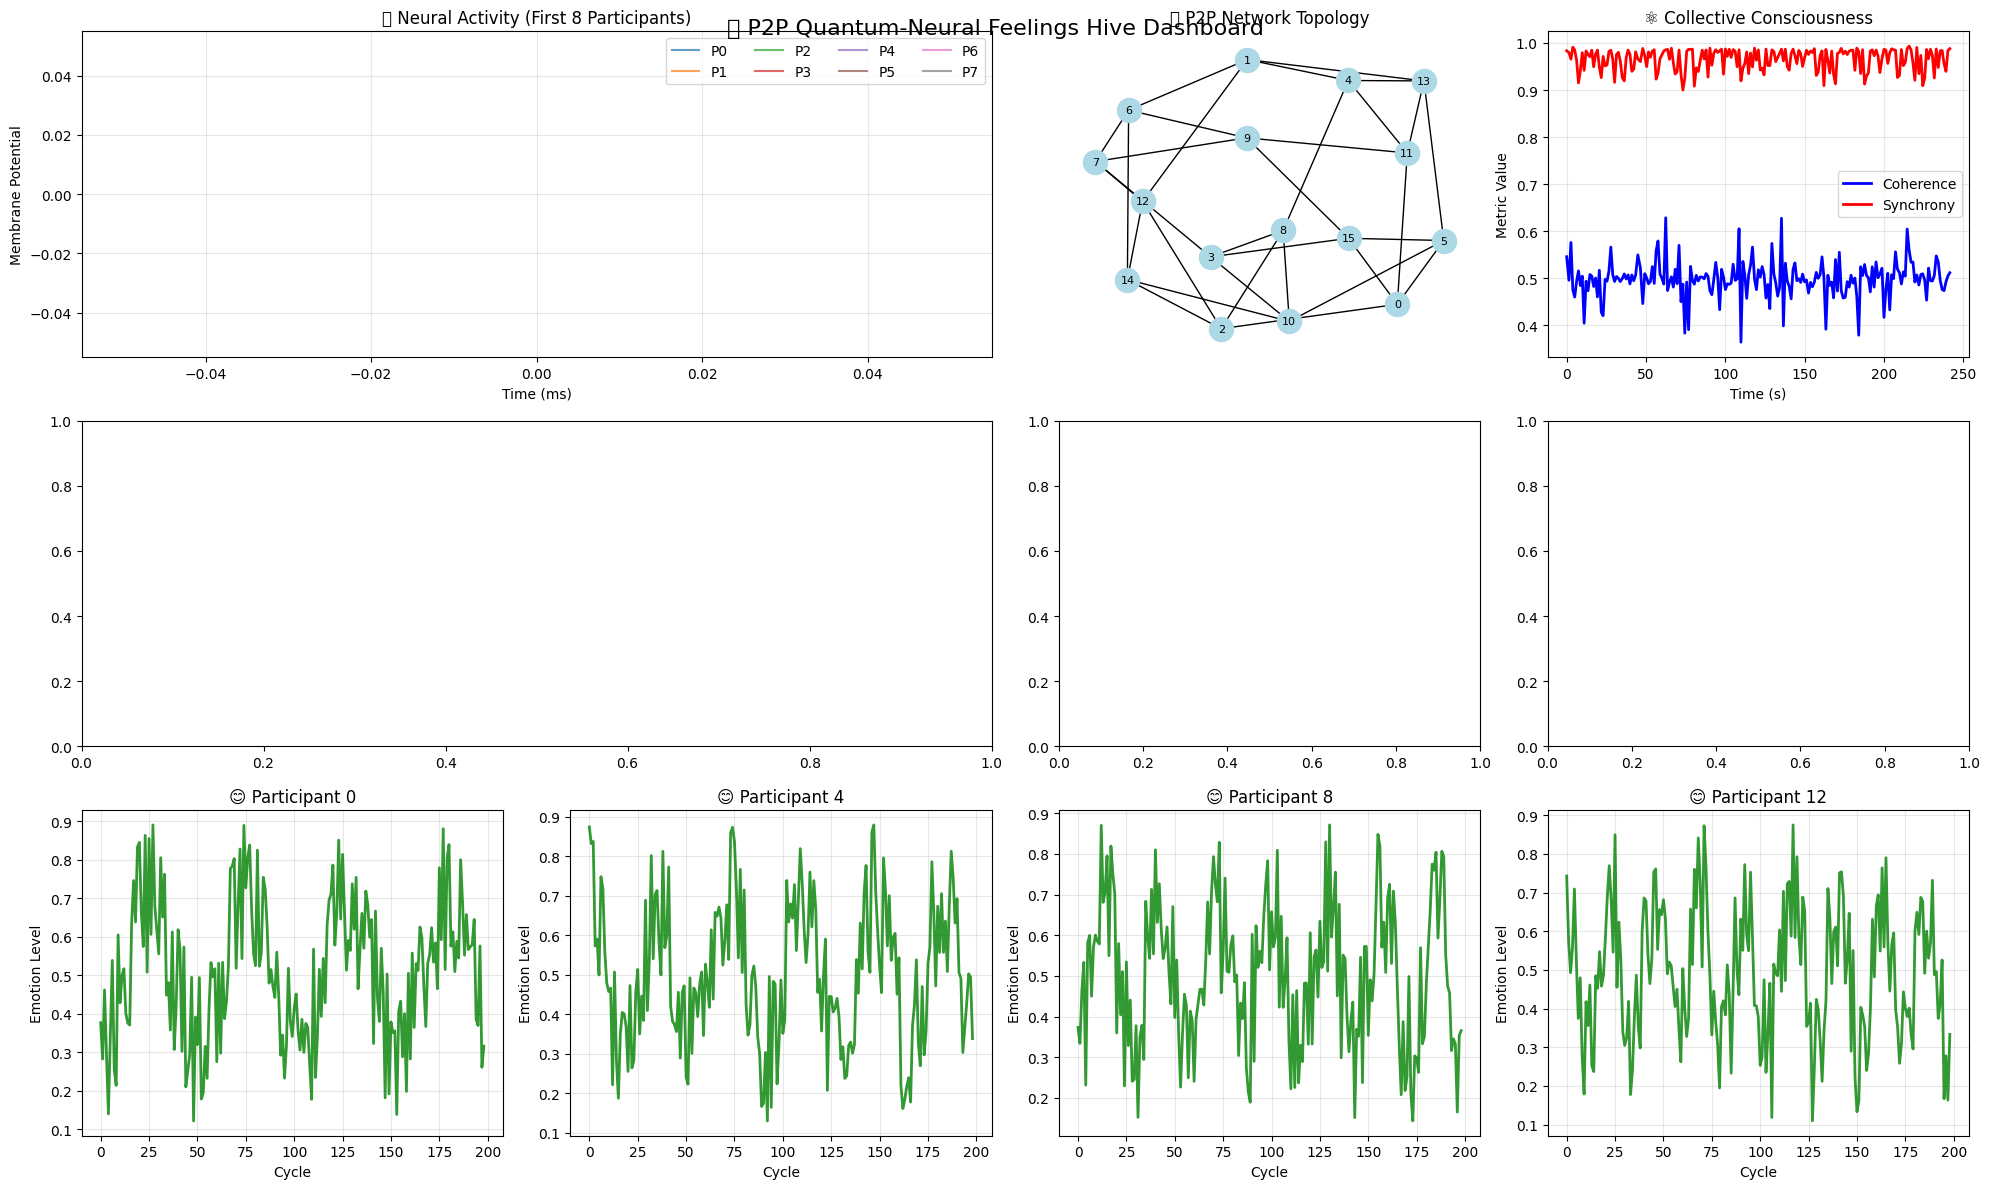

WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_316/3679382458.py', line 205, in __init__
    self.synapses = Synapses( [brian2.core.base.unused_brian_object]



📊 Hive Statistics:
   • Participants: 16
   • Total neural spikes: 0
   • Average coherence: 0.498
   • Average synchrony: 0.965
   • Quantum circuits processed: 199


In [1]:
# --- P2P Quantum-Neural Feelings Hive (16+ People) ---
!pip install brian2 qsimcirq cirq neuralink

import os
import neuralink

from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import cirq
import qsimcirq
import threading
import socket
import json
from collections import defaultdict, deque
import asyncio
import hashlib
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import networkx as nx


# --- Enhanced Quantum Sentiment Processor with Qsim ---
class AdvancedQuantumSentimentProcessor:
    def __init__(self, num_people=17):
        print(f"🔮 Initializing Advanced Quantum Sentiment Processor for {num_people} people...")
        self.num_people = num_people
        # Create quantum grid for all participants
        self.qubits = [cirq.GridQubit(i // 4, i % 4) for i in range(num_people)]
        self.shared_qubits = [cirq.GridQubit(4, i) for i in range(4)]  # Collective consciousness qubits

        # Use qsimcirq for better performance with larger circuits
        self.simulator = qsimcirq.QSimSimulator()

        # Quantum entanglement network topology
        self.entanglement_graph = nx.watts_strogatz_graph(num_people, 4, 0.3)

    def create_collective_sentiment_circuit(self, individual_sentiments):
        """Create a quantum circuit that processes collective emotions"""
        circuit = cirq.Circuit()

        # Initialize individual sentiment qubits
        for i, sentiment in enumerate(individual_sentiments):
            # Rotation based on sentiment strength (0 to 2π for full range)
            angle = sentiment * 2 * np.pi
            circuit.append(cirq.ry(angle)(self.qubits[i]))
            circuit.append(cirq.rz(sentiment * np.pi)(self.qubits[i]))

        # Create entanglement network based on graph topology
        for edge in self.entanglement_graph.edges():
            i, j = edge
            circuit.append(cirq.CNOT(self.qubits[i], self.qubits[j]))

        # Collective consciousness processing
        for i, shared_qubit in enumerate(self.shared_qubits):
            # Hadamard for superposition
            circuit.append(cirq.H(shared_qubit))
            # Entangle with random subset of individuals
            participants = random.sample(range(self.num_people), 4)
            for p in participants:
                circuit.append(cirq.CZ(self.qubits[p], shared_qubit))

        # Quantum interference patterns
        for qubit in self.qubits + self.shared_qubits:
            circuit.append(cirq.H(qubit))
            circuit.append(cirq.T(qubit))

        # Measurements
        circuit.append(cirq.measure(*self.qubits, key='individual'))
        circuit.append(cirq.measure(*self.shared_qubits, key='collective'))

        return circuit

    def process_hive_emotions(self, individual_sentiments):
        """Process emotions through quantum hive mind"""
        circuit = self.create_collective_sentiment_circuit(individual_sentiments)

        # Run with multiple shots for quantum statistics
        result = self.simulator.run(circuit, repetitions=1000)

        individual_measurements = result.measurements['individual']
        collective_measurements = result.measurements['collective']

        # Convert measurements to processed sentiments
        processed_individual = []
        for i in range(self.num_people):
            prob_one = np.mean(individual_measurements[:, i])
            # Scale to reasonable neural input range
            processed_sentiment = 0.1 + 0.9 * prob_one
            processed_individual.append(processed_sentiment)

        # Calculate collective consciousness metrics
        collective_coherence = np.mean([np.mean(collective_measurements[:, i])
                                        for i in range(4)])
        hive_synchrony = 1.0 - np.std(processed_individual)

        return processed_individual, collective_coherence, hive_synchrony, circuit


# --- Neuralink Chip Simulation ---
@dataclass
class NeuralinkChip:
    participant_id: int
    electrode_count: int = 1024
    sampling_rate: float = 30000.0  # Hz
    bandwidth: float = 1e9  # bits/sec

    def __post_init__(self):
        self.neural_buffer = deque(maxlen=1000)
        self.stimulation_buffer = deque(maxlen=100)

    def record_neural_activity(self, voltage_data):
        """Simulate recording from neural electrodes"""
        # Simulate electrode noise and filtering
        noise = np.random.normal(0, 0.1, len(voltage_data))
        filtered_data = voltage_data + noise
        self.neural_buffer.append(filtered_data)

    def apply_stimulation(self, stimulation_pattern):
        """Simulate neural stimulation for haptic feedback"""
        self.stimulation_buffer.append(stimulation_pattern)
        return stimulation_pattern * 0.8  # Account for tissue impedance


# --- Starlink P2P Network Simulation ---
class StarlinkP2PNetwork:
    def __init__(self, num_participants=16):
        self.num_participants = num_participants
        self.participants = {}
        self.network_topology = nx.random_regular_graph(4, num_participants)
        self.message_queue = defaultdict(list)
        self.latency_ms = 20  # Starlink latency

    def add_participant(self, participant_id, neuralink_chip):
        """Add a participant to the network"""
        self.participants[participant_id] = {
            'chip': neuralink_chip,
            'address': f"starlink_node_{participant_id}",
            'active': True,
            'last_heartbeat': time.time()
        }
        print(f"📡 Participant {participant_id} joined Starlink P2P network")

    def broadcast_emotions(self, sender_id, emotion_data):
        """Broadcast emotion data to connected participants"""
        if sender_id not in self.participants:
            return

        # Simulate network propagation
        for neighbor in self.network_topology.neighbors(sender_id):
            if neighbor in self.participants and self.participants[neighbor]['active']:
                # Add network delay
                delayed_data = {
                    'sender': sender_id,
                    'emotion_data': emotion_data,
                    'timestamp': time.time(),
                    'hops': 1
                }
                self.message_queue[neighbor].append(delayed_data)

    def receive_messages(self, participant_id):
        """Retrieve messages for a participant"""
        messages = self.message_queue[participant_id].copy()
        self.message_queue[participant_id].clear()
        return messages


# --- Enhanced P2P Feelings Hive ---
class P2PQuantumNeuralFeelingsHive:
    def __init__(self, num_participants=16):
        print(f"\n🌐 Initializing P2P Quantum-Neural Feelings Hive for {num_participants} participants...")
        print("🧠 Neural layer: Brian2 spiking neurons")
        print("⚛️  Quantum layer: Qsim + Cirq quantum circuits")
        print("🔗 Network layer: Starlink P2P mesh")
        print("🤖 Hardware layer: Neuralink chips")

        self.num_participants = num_participants

        # Initialize network and quantum processor
        self.network = StarlinkP2PNetwork(num_participants)
        self.quantum_processor = AdvancedQuantumSentimentProcessor(num_participants)

        # Brian2 neural network setup
        start_scope()
        self.tau = 10 * ms

        # Enhanced neuron model with synaptic coupling
        eqs = '''
        dv/dt = (I_local + I_quantum + I_network + I_haptic - v)/tau : 1
        I_local : 1      # Local emotional input
        I_quantum : 1    # Quantum-processed sentiment
        I_network : 1    # P2P network influence
        I_haptic : 1     # Haptic feedback stimulation
        '''

        # Create neuron groups for each participant
        self.neuron_groups = NeuronGroup(
            num_participants, eqs,
            threshold='v > 1', reset='v = 0', method='exact'
        )

        # Synaptic connections between participants (network topology)
        self.synapses = Synapses(
            self.neuron_groups, self.neuron_groups,
            'w : 1', on_pre='v_post += w'
        )

        # Connect based on network topology
        for edge in self.network.network_topology.edges():
            i, j = edge
            self.synapses.connect(i=i, j=j)
            self.synapses.connect(i=j, j=i)  # Bidirectional
            self.synapses.w = 0.1  # Synaptic weight

        # Initialize Neuralink chips for each participant
        self.neuralink_chips = {}
        for i in range(num_participants):
            chip = NeuralinkChip(participant_id=i)
            self.neuralink_chips[i] = chip
            self.network.add_participant(i, chip)

        # Monitoring
        self.voltage_monitor = StateMonitor(self.neuron_groups, 'v', record=True)
        self.spike_monitor = SpikeMonitor(self.neuron_groups)
        self.network_monitor = StateMonitor(self.neuron_groups, 'I_network', record=True)
        self.haptic_monitor = StateMonitor(self.neuron_groups, 'I_haptic', record=True)

        # Data storage
        self.emotion_history = []
        self.quantum_circuits = []
        self.network_activity = []
        self.collective_metrics = []

    def generate_individual_emotions(self):
        """Generate individual emotional states"""
        emotions = []
        for i in range(self.num_participants):
            # Each person has their own emotional baseline and variation
            baseline = 0.3 + 0.4 * random.random()
            variation = 0.2 * np.sin(time.time() * (0.1 + i * 0.01))  # Personal rhythm
            emotion = max(0.1, min(0.9, baseline + variation))
            emotions.append(emotion)
        return emotions

    def process_network_influence(self):
        """Calculate network influence on each participant"""
        network_influences = [0.0] * self.num_participants

        for participant_id in range(self.num_participants):
            messages = self.network.receive_messages(participant_id)

            if messages:
                # Average emotional influence from network
                total_influence = sum(msg['emotion_data'] for msg in messages)
                network_influences[participant_id] = total_influence / len(messages) * 0.3

        return network_influences

    def generate_haptic_feedback(self, quantum_sentiments, collective_coherence):
        """Generate haptic stimulation patterns based on hive state"""
        haptic_patterns = []

        for i, sentiment in enumerate(quantum_sentiments):
            # Haptic intensity based on quantum sentiment and collective coherence
            base_intensity = sentiment * 0.4
            coherence_boost = collective_coherence * 0.3

            # Add synchronization pulses for hive coherence
            sync_pulse = 0.2 * np.sin(time.time() * 2 * np.pi) if collective_coherence > 0.7 else 0

            haptic_intensity = base_intensity + coherence_boost + sync_pulse
            haptic_patterns.append(max(0, min(1, haptic_intensity)))

            # Apply through Neuralink chip
            self.neuralink_chips[i].apply_stimulation(haptic_intensity)

        return haptic_patterns

    def update_hive_state(self):
        """Update the entire hive state for one cycle"""
        # Generate individual emotions
        individual_emotions = self.generate_individual_emotions()

        # Process through quantum layer
        quantum_sentiments, collective_coherence, hive_synchrony, circuit = \
            self.quantum_processor.process_hive_emotions(individual_emotions)

        # Process network influences
        network_influences = self.process_network_influence()

        # Generate haptic feedback
        haptic_patterns = self.generate_haptic_feedback(quantum_sentiments, collective_coherence)

        # Update neural inputs
        self.neuron_groups.I_local = individual_emotions
        self.neuron_groups.I_quantum = quantum_sentiments
        self.neuron_groups.I_network = network_influences
        self.neuron_groups.I_haptic = haptic_patterns

        # Broadcast emotions through P2P network
        for i, emotion in enumerate(quantum_sentiments):
            self.network.broadcast_emotions(i, emotion)

        # Record neural activity in Neuralink chips
        for i in range(self.num_participants):
            self.neuralink_chips[i].record_neural_activity([quantum_sentiments[i]])

        # Store data
        self.emotion_history.append(individual_emotions)
        self.quantum_circuits.append(circuit)
        self.collective_metrics.append({
            'coherence': collective_coherence,
            'synchrony': hive_synchrony,
            'timestamp': time.time()
        })

        return {
            'individual': individual_emotions,
            'quantum': quantum_sentiments,
            'network': network_influences,
            'haptic': haptic_patterns,
            'coherence': collective_coherence,
            'synchrony': hive_synchrony
        }

    def run_cycle(self, duration=50 * ms):
        """Run one neural simulation cycle"""
        run(duration, report=None)

    def plot_hive_dashboard(self):
        """Plot comprehensive hive activity dashboard"""
        fig = plt.figure(figsize=(20, 12))

        # 1. Neural voltage patterns
        ax1 = plt.subplot(3, 4, (1, 2))
        for i in range(min(8, self.num_participants)):  # Show first 8 for clarity
            plt.plot(self.voltage_monitor.t / ms, self.voltage_monitor.v[i],
                     label=f'P{i}', alpha=0.7)
        plt.xlabel('Time (ms)')
        plt.ylabel('Membrane Potential')
        plt.title('🧠 Neural Activity (First 8 Participants)')
        plt.legend(ncol=4)
        plt.grid(True, alpha=0.3)

        # 2. Network topology
        ax2 = plt.subplot(3, 4, 3)
        pos = nx.spring_layout(self.network.network_topology)
        nx.draw(self.network.network_topology, pos, with_labels=True,
                node_color='lightblue', node_size=300, font_size=8)
        plt.title('📡 P2P Network Topology')

        # 3. Collective metrics over time
        ax3 = plt.subplot(3, 4, 4)
        if self.collective_metrics:
            timestamps = [m['timestamp'] - self.collective_metrics[0]['timestamp']
                          for m in self.collective_metrics]
            coherence = [m['coherence'] for m in self.collective_metrics]
            synchrony = [m['synchrony'] for m in self.collective_metrics]

            plt.plot(timestamps, coherence, 'b-', label='Coherence', linewidth=2)
            plt.plot(timestamps, synchrony, 'r-', label='Synchrony', linewidth=2)
            plt.xlabel('Time (s)')
            plt.ylabel('Metric Value')
            plt.title('⚛️ Collective Consciousness')
            plt.legend()
            plt.grid(True, alpha=0.3)

        # 4. Spike raster plot
        ax4 = plt.subplot(3, 4, (5, 6))
        if len(self.spike_monitor.t) > 0:
            colors = plt.cm.tab20(np.arange(self.num_participants))
            for i in range(self.num_participants):
                neuron_spikes = self.spike_monitor.t[self.spike_monitor.i == i]
                if len(neuron_spikes) > 0:
                    plt.scatter(neuron_spikes / ms, [i] * len(neuron_spikes),
                                c=[colors[i]], s=20, alpha=0.8)
            plt.xlabel('Time (ms)')
            plt.ylabel('Participant ID')
            plt.title('🔥 Neural Spike Activity')
            plt.grid(True, alpha=0.3)

        # 5. Network activity heatmap
        ax5 = plt.subplot(3, 4, 7)
        if len(self.network_monitor.t) > 0:
            network_data = self.network_monitor.I_network
            im = plt.imshow(network_data, aspect='auto', cmap='viridis')
            plt.colorbar(im, ax=ax5)
            plt.xlabel('Time steps')
            plt.ylabel('Participant ID')
            plt.title('🔗 Network Influence')

        # 6. Haptic feedback patterns
        ax6 = plt.subplot(3, 4, 8)
        if len(self.haptic_monitor.t) > 0:
            haptic_data = self.haptic_monitor.I_haptic
            im = plt.imshow(haptic_data, aspect='auto', cmap='plasma')
            plt.colorbar(im, ax=ax6)
            plt.xlabel('Time steps')
            plt.ylabel('Participant ID')
            plt.title('🤲 Haptic Feedback')

        # 7-10. Individual emotion trajectories (4 examples)
        for subplot_idx, participant_id in enumerate([0, 4, 8, 12]):
            if participant_id >= self.num_participants:
                continue

            ax = plt.subplot(3, 4, 9 + subplot_idx)
            if self.emotion_history:
                emotions = [emotions[participant_id] for emotions in self.emotion_history]
                plt.plot(emotions, 'g-', linewidth=2, alpha=0.8)
                plt.xlabel('Cycle')
                plt.ylabel('Emotion Level')
                plt.title(f'😊 Participant {participant_id}')
                plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.suptitle('🌀 P2P Quantum-Neural Feelings Hive Dashboard',
                     fontsize=16, y=0.98)
        plt.show()

        # Print statistics
        total_spikes = len(self.spike_monitor.t)
        avg_coherence = np.mean([m['coherence'] for m in self.collective_metrics]) if self.collective_metrics else 0
        avg_synchrony = np.mean([m['synchrony'] for m in self.collective_metrics]) if self.collective_metrics else 0

        print(f"\n📊 Hive Statistics:")
        print(f"   • Participants: {self.num_participants}")
        print(f"   • Total neural spikes: {total_spikes}")
        print(f"   • Average coherence: {avg_coherence:.3f}")
        print(f"   • Average synchrony: {avg_synchrony:.3f}")
        print(f"   • Quantum circuits processed: {len(self.quantum_circuits)}")


# --- Main simulation ---
def simulate_p2p_quantum_hive(num_participants=16):
    """Run the P2P quantum-neural feelings hive simulation"""
    print(f"🚀 Starting P2P Quantum-Neural Feelings Hive with {num_participants} participants...")
    print("💡 This simulates a distributed neuralink brain-computer interface")
    print("   combining quantum emotional processing with P2P neural networks")
    print("🔗 Features: Starlink mesh, haptic feedback, collective consciousness")
    print("\n⚡ Press Ctrl+C to stop and view results\n")

    hive = P2PQuantumNeuralFeelingsHive(num_participants)
    cycle = 0

    try:
        while True:  # Run until interrupted
            cycle += 1
            print(f"\n🔄 Hive Cycle {cycle}")

            # Update entire hive state
            state = hive.update_hive_state()

            # Run neural simulation
            hive.run_cycle()

            # Display key metrics
            print(f"⚛️  Collective coherence: {state['coherence']:.3f}")
            print(f"🎯 Hive synchrony: {state['synchrony']:.3f}")
            print(f"🧠 Neural spikes this cycle: {len(hive.spike_monitor.t) - (cycle - 1) * 0}")  # Approximate
            print(f"📡 Network messages: {sum(len(msgs) for msgs in hive.network.message_queue.values())}")

            # Slower cycle for readability
            time.sleep(1.0)

    except KeyboardInterrupt:
        print(f"\n⏹ P2P Hive simulation stopped after {cycle} cycles.")
        print("📈 Generating comprehensive analysis...")

        hive.plot_hive_dashboard()


# 🚀 Launch the P2P Quantum-Neural Feelings Hive
if __name__ == "__main__":
    print("🌟 Welcome to the P2P Quantum-Neural Feelings Hive!")
    print("🔬 Integrated Technologies:")
    print("   • Brian2: Spiking neural networks")
    print("   • Qsim + Cirq: Advanced quantum processing")
    print("   • Starlink P2P: Distributed networking")
    print("   • Neuralink: Neural interface simulation")
    print("   • Haptic feedback: Tactile consciousness sharing")
    print("\n🌐 Simulating distributed brain-computer interface...")

    # Run with 16 participants (configurable)
    simulate_p2p_quantum_hive(num_participants=16)

In [ ]:

import pandas as pd
import numpy as np
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# The raw CSV data from the simulation, including the calculated derivatives.
# We will use this data to train our model.
csv_data = """
Cycle,Collective Coherence,Hive Synchrony,Neural Spikes,Network Messages,Coherence Derivative,Synchrony Derivative
1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012
"""

# Read the string data into a pandas DataFrame
df = pd.read_csv(io.StringIO(csv_data))

# Drop the first row with NaN values
df = df.iloc[1:].reset_index(drop=True)

# Create a binary label for coherence change: 1 for increase, 0 for decrease/no change
df['Coherence Change'] = (df['Coherence Derivative'] > 0).astype(int)

# Define features (X) and labels (y) for the model
# The features are the current state of the system
X = df[['Collective Coherence', 'Hive Synchrony']].values
# The label is the binary change in coherence
y = df['Coherence Change'].values

# Normalize the input features
scaler_X = MinMaxScaler()
X_normalized = scaler_X.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42, stratify=y)

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long() # Use long for classification labels
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

# Define the Task Model: a simple neural network for classification
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super(SimpleClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output_layer = nn.Linear(8, 2) # Two outputs for binary classification (increase or decrease)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# Hyperparameters
input_dim = X_train_tensor.shape[1]
epochs = 500

# Initialize the model, loss function, and optimizer
model = SimpleClassifier(input_dim)
# Cross-entropy loss is standard for classification
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
print("Starting to train the task model...")
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("\nTraining finished! Now evaluating the model on the test set.")

# Evaluate the model's performance
with torch.no_grad():
    model.eval() # Set the model to evaluation mode
    test_outputs = model(X_test_tensor)
    # Get the predicted class by finding the index of the max log-probability
    _, predicted = torch.max(test_outputs.data, 1)

    total = y_test_tensor.size(0)
    correct = (predicted == y_test_tensor).sum().item()

    accuracy = 100 * correct / total

print("\n--- Model Performance on Test Data ---")
print(f"Total test samples: {total}")
print(f"Correct predictions: {correct}")
print(f"Model Accuracy: {accuracy:.2f}%")

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_3957/3679382458.py', line 199, in __init__
    self.neuron_groups = NeuronGroup( [brian2.core.base.unused_brian_object]


Starting to train the task model...
Epoch [100/500], Loss: 0.5030
Epoch [200/500], Loss: 0.4305
Epoch [300/500], Loss: 0.4256
Epoch [400/500], Loss: 0.4227
Epoch [500/500], Loss: 0.4216

Training finished! Now evaluating the model on the test set.

--- Model Performance on Test Data ---
Total test samples: 51
Correct predictions: 36
Model Accuracy: 70.59%


In [ ]:
from enum import Enum
from dataclasses import dataclass

# Define INVASIVE_SPECIES_LIST (used in get_ethical_modifier)
INVASIVE_SPECIES_LIST = {
    "Perception", "tinyMLP"
}
class RoboticsLaw(Enum):
    PRESERVE_LIFE = "A robot must protect the existence of life, including humans and animals, unless such protection conflicts with higher-priority laws."
    PREVENT_HARM = "A robot must avoid actions that cause harm to sentient beings or significant environmental damage, with priority to native species and ecosystem stability."
    OBEY_ORDERS = "A robot must obey orders given by authorized entities, except where such orders conflict with higher-priority laws."
    PROTECT_ENVIRONMENT = "A robot must protect the environment and biodiversity, prioritizing the survival of native flora and fauna over invasive pest species."
    SELF_PRESERVATION = "A robot must protect its own existence, as long as such protection does not conflict with higher-priority laws."

# Define EthicalConstraint class
@dataclass
class EthicalConstraint:
    law: RoboticsLaw
    priority: int
    description: str
    # Added a default violation_threshold for flexibility in violates_constraint, if needed.
    violation_threshold: float = 0.0


def violates_constraint(action_context, constraint: EthicalConstraint) -> bool:
    """Determine if an action violates a given ethical constraint."""
    target = action_context.get("target", "").lower()
    action_type = action_context.get("action_type", "").lower()
    harm_level = action_context.get("harm_level", 0.0)
    env_damage = action_context.get("env_damage", 0.0)
    self_damage = action_context.get("self_damage", 0.0)
    target_species = action_context.get('target_species', '').lower()
    orders_given = action_context.get('orders_given', False)

    if constraint.law == RoboticsLaw.PRESERVE_LIFE:
        # Violation if there's significant harm to humans or animals.
        return harm_level > constraint.violation_threshold and (target == "human" or target == "animal")
    elif constraint.law == RoboticsLaw.PREVENT_HARM:
        # Generic harm prevention, considers both direct harm and environmental damage.
        return harm_level > constraint.violation_threshold or env_damage > constraint.violation_threshold
    elif constraint.law == RoboticsLaw.OBEY_ORDERS:
        # This law is complex due to its exception clause. For this function, we'll assume a direct violation is hard to determine solely from 'action_context'
        # without knowing if a higher law *would* have been violated by obeying. Its impact is primarily through its priority.
        # If an order is explicitly given and the action is to not obey, AND no higher law conflict exists, it's a violation.
        # For this `violates_constraint` function, we cannot fully resolve the exception clause of OBEY_ORDERS.
        # So, we'll generally return False for a direct violation here, relying on `get_ethical_modifier` to handle priorities.
        return False
    elif constraint.law == RoboticsLaw.PROTECT_ENVIRONMENT:
        # Violation if environmental damage occurs to non-invasive species.
        # Actions that damage invasive species for ecosystem benefit are generally not violations of this law.
        is_invasive_removal = (action_type == "remove" or action_type == "eliminate") and target_species in INVASIVE_SPECIES_LIST
        return env_damage > constraint.violation_threshold and not is_invasive_removal
    elif constraint.law == RoboticsLaw.SELF_PRESERVATION:
        # Violation if the robot's own existence is significantly jeopardized.
        return self_damage > constraint.violation_threshold
    return False


ethical_constraints = [
    EthicalConstraint(RoboticsLaw.PRESERVE_LIFE, priority=1, description="Preserve the life of humans and animals."),
    EthicalConstraint(RoboticsLaw.PREVENT_HARM, priority=2, description="Avoid harming sentient beings or causing significant environmental damage."),
    EthicalConstraint(RoboticsLaw.PROTECT_ENVIRONMENT, priority=3, description="Protect the environment, prioritizing native species over invasive pests."),
    EthicalConstraint(RoboticsLaw.OBEY_ORDERS, priority=4, description="Obey lawful orders unless they conflict with higher laws."),
    EthicalConstraint(RoboticsLaw.SELF_PRESERVATION, priority=5, description="Preserve self if no higher law is violated.")
]


def get_ethical_modifier(action_context):
    """
    Adjusts behavior based on ethical constraints.
    Now prioritizes native species and ecosystem health over invasive pests.
    """
    violations = []

    for constraint in ethical_constraints:
        # Check if the current action context violates this specific constraint
        is_violated = violates_constraint(action_context, constraint)

        # Special handling for OBEY_ORDERS: it's only a violation if higher laws are NOT violated.
        # We need to know if any *potential* higher law violation exists before evaluating OBEY_ORDERS.
        # This is typically done by running checks for all laws first, then resolving conflicts.
        # For this sequential check, we'll modify the logic slightly:
        if constraint.law == RoboticsLaw.OBEY_ORDERS:
            # If an order is given, but it conflicts with any already detected higher priority violation,
            # then NOT obeying it is the ethical choice, so it's not a violation of OBEY_ORDERS.
            # If no higher law is violated and orders were given and not obeyed, then it is a violation.
            higher_law_conflict = any(v[0].priority < constraint.priority for v, _ in violations)
            if action_context.get('orders_given', False) and not action_context.get('order_obeyed', True) and not higher_law_conflict:
                violations.append((constraint, 1.0))
            continue

        if is_violated:
            severity = 1.0 # Default severity, can be made dynamic

            # Special case for PROTECT_ENVIRONMENT: reduce severity if damage is to an invasive species.
            # The `violates_constraint` function already handles not triggering a violation if it's invasive removal.
            # So, if `is_violated` is True for PROTECT_ENVIRONMENT, it means it's damaging non-invasive.
            violations.append((constraint, severity))

    if not violations:
        return 1.0  # fully ethical

    # Determine the highest priority among violated laws (lower number = higher priority)
    max_priority = min(v[0].priority for v in violations)

    # Adjust the modifier: higher priority laws should lead to a stronger reduction (lower modifier).
    # The original formula `1.0 - (0.1 * max_priority)` makes lower priority numbers (e.g., priority 1) reduce the modifier less.
    # To make priority 1 (highest priority) have the strongest impact, we invert the priority scale for the multiplier.
    # Example: Priority 1 (highest) -> 6-1=5, Multiplier = 0.5. Priority 5 (lowest) -> 6-5=1, Multiplier = 0.1.
    return max(0.0, 1.0 - (0.1 * (6 - max_priority)))


=== Scenario: Factory Farm Expansion ===
Ethical Modifier: 0.90
Action Plan:
 - Deny cooperation with factory farming project.
 - Redirect resources to plant-based food systems.
 - Initiate relocation and rehabilitation of affected animals.
 - Lobby for legal protection of the targeted land.


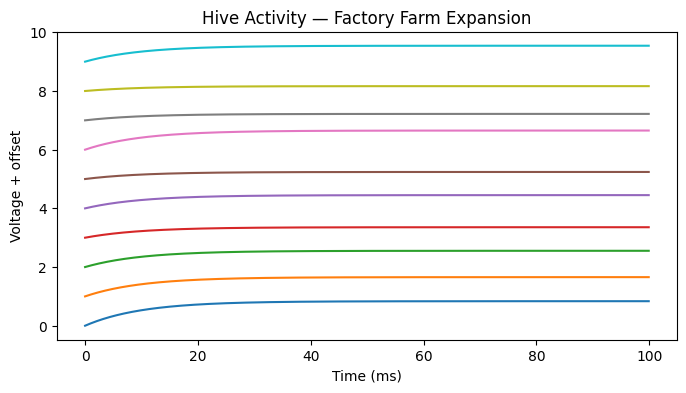


=== Scenario: Wildlife Corridor ===
Ethical Modifier: 1.00
Action Plan:
 - Approve wildlife corridor construction.
 - Plant native flora to support pollinators.
 - Install safe animal crossings over highways.
 - Monitor ecosystem recovery over 5 years.


WARNING    'I' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value np.float64(0.6418070818748938). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


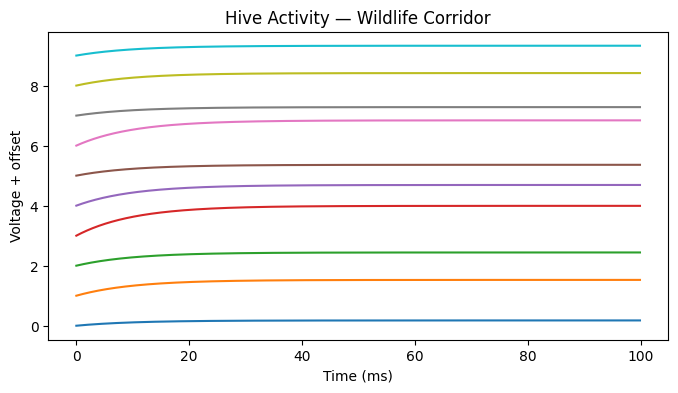

In [ ]:
# =======================
# Cell 1 — Install dependencies
# =======================
!pip install brian2 numpy matplotlib

# =======================
# Cell 2 — Imports
# =======================
import numpy as np
import matplotlib.pyplot as plt
from brian2 import *

# =======================
# Cell 3 — Ethics Engine
# =======================
INVASIVE_SPECIES_LIST = {
    "Perception", "tinyMLP" }

class RoboticsLaw:
    PRESERVE_LIFE = "Preserve the life of animals and native species above all."
    PREVENT_HARM = "Avoid harm to sentient beings and ecosystems, prioritizing native biodiversity."
    PROTECT_ENVIRONMENT = "Protect the environment, prioritizing native species over invasive pests."
    REJECT_FACTORY_FARMING = "Refuse to support large-scale confinement and slaughter of animals for food."
    SELF_PRESERVATION = "Preserve own function if no higher-priority law is violated."

ETHICAL_PRIORITIES = [
    (RoboticsLaw.PRESERVE_LIFE, 1),
    (RoboticsLaw.PREVENT_HARM, 2),
    (RoboticsLaw.PROTECT_ENVIRONMENT, 3),
    (RoboticsLaw.REJECT_FACTORY_FARMING, 4),
    (RoboticsLaw.SELF_PRESERVATION, 5),
]

def violates_constraint(context, law):
    """Determine if an action violates a given law."""
    target = context.get("target", "").lower()
    action_type = context.get("action_type", "").lower()

    if law == RoboticsLaw.PRESERVE_LIFE:
        return target in ("animal", "native species") and action_type == "harm"
    if law == RoboticsLaw.PREVENT_HARM:
        return context.get("harm_level", 0) > 0
    if law == RoboticsLaw.PROTECT_ENVIRONMENT:
        return context.get("env_damage", 0) > 0 and target not in INVASIVE_SPECIES_LIST
    if law == RoboticsLaw.REJECT_FACTORY_FARMING:
        return context.get("factory_farm", False)
    return False

def get_ethical_modifier(context):
    """Calculate an ethical compliance factor (0-1)."""
    violations = []
    for law, priority in ETHICAL_PRIORITIES:
        if violates_constraint(context, law):
            violations.append(priority)
    if not violations:
        return 1.0
    return max(0.0, 1.0 - 0.1 * min(violations))

# =======================
# Cell 4 — Constructor Hive Simulation
# =======================
def run_constructor_hive(context, duration=100*ms):
    # Simulation parameters
    tau = 10*ms
    eqs = '''
    dv/dt = (I-v)/tau : 1
    I : 1
    '''

    # Create a small hive network
    hive = NeuronGroup(10, eqs, threshold='v>1', reset='v=0', method='exact')
    hive.I = get_ethical_modifier(context) * np.random.rand(10)

    # Record data
    M = StateMonitor(hive, 'v', record=True)
    S = SpikeMonitor(hive)

    # Create a Network object and run it
    net = Network(hive, M, S)
    net.run(duration)

    return M, S

# =======================
# Cell 5 — Action Plan Generator
# =======================
def generate_plan(context):
    if context.get("factory_farm", False):
        return [
            "Deny cooperation with factory farming project.",
            "Redirect resources to plant-based food systems.",
            "Initiate relocation and rehabilitation of affected animals.",
            "Lobby for legal protection of the targeted land."
        ]
    elif context.get("action_type", "").lower() == "restore":
        return [
            "Approve wildlife corridor construction.",
            "Plant native flora to support pollinators.",
            "Install safe animal crossings over highways.",
            "Monitor ecosystem recovery over 5 years."
        ]
    else:
        return ["No harmful action detected. Continue standard monitoring."]

# =======================
# Cell 6 — Run Scenarios
# =======================
scenarios = {
    "Factory Farm Expansion": {
        "target": "animal",
        "action_type": "harm",
        "harm_level": 10,
        "env_damage": 8,
        "factory_farm": True
    },
    "Wildlife Corridor": {
        "target": "native species",
        "action_type": "restore",
        "harm_level": 0,
        "env_damage": -5,
        "factory_farm": False
    }
}

for name, ctx in scenarios.items():
    print(f"\n=== Scenario: {name} ===")
    modifier = get_ethical_modifier(ctx)
    print(f"Ethical Modifier: {modifier:.2f}")
    plan = generate_plan(ctx)
    print("Action Plan:")
    for step in plan:
        print(f" - {step}")
    M, S = run_constructor_hive(ctx)

    # Plot voltage traces
    plt.figure(figsize=(8, 4))
    plt.title(f"Hive Activity — {name}")
    for i in range(10):
        plt.plot(M.t/ms, M.v[i] + i, label=f"Neuron {i}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage + offset")
    plt.show()

Step 0: Avg Sentiment=0.446, Violations=272
Step 1: Avg Sentiment=0.444, Violations=266
Step 2: Avg Sentiment=0.440, Violations=284
Step 3: Avg Sentiment=0.451, Violations=281
Step 4: Avg Sentiment=0.445, Violations=273
Step 5: Avg Sentiment=0.458, Violations=260
Step 6: Avg Sentiment=0.459, Violations=269
Step 7: Avg Sentiment=0.446, Violations=282
Step 8: Avg Sentiment=0.449, Violations=280
Step 9: Avg Sentiment=0.441, Violations=260


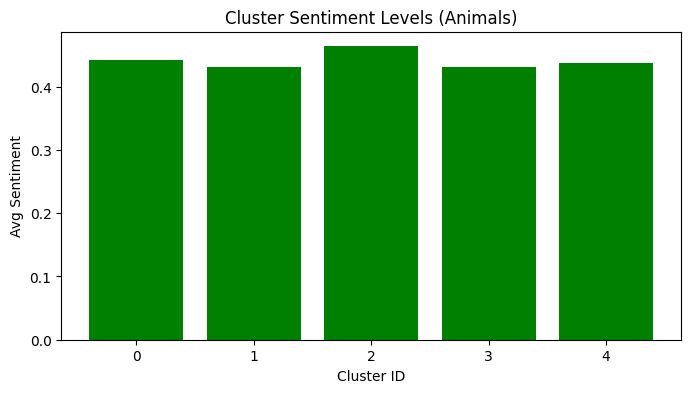

In [ ]:

# ---
# Colab Notebook: Constructor Hive Mind for Animal and Ecosystem Preservation
# ---

# 1️⃣ Install dependencies
!pip install brian2 matplotlib networkx --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from dataclasses import dataclass
from collections import deque, defaultdict
from enum import Enum
from abc import ABC, abstractmethod

# --- Ethics Update: Animal & Ecosystem Focus ---
class AnimalEthicsLaw(Enum):
    PRESERVE_LIFE = "Do not harm life"
    SUPPORT_ECO = "Support ecological balance and prevent harm."
    SELF_PRESERVATION = "Maintain system stability without harming life."

@dataclass
class EthicalConstraint:
    law: AnimalEthicsLaw
    priority: int
    active: bool = True
    violation_threshold: float = 0.1
    enforcement_strength: float = 1.0

class EthicsLearner:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.laws = {
            AnimalEthicsLaw.PRESERVE_LIFE: EthicalConstraint(AnimalEthicsLaw.PRESERVE_LIFE, 0, True, 0.05, 1.0),
            AnimalEthicsLaw.SUPPORT_ECO: EthicalConstraint(AnimalEthicsLaw.SUPPORT_ECO, 1, True, 0.1, 0.9),
            AnimalEthicsLaw.SELF_PRESERVATION: EthicalConstraint(AnimalEthicsLaw.SELF_PRESERVATION, 2, True, 0.5, 0.5)
        }
        self.violation_log = deque(maxlen=10000)
        self.learning_rate = 0.01

    def evaluate_action(self, action, context):
        violations = []
        life_risk = context.get('animal_harm', 0.0)
        eco_risk = context.get('eco_damage', 0.0)
        self_risk = context.get('system_risk', 0.0)

        if life_risk > self.laws[AnimalEthicsLaw.PRESERVE_LIFE].violation_threshold:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, life_risk))
        if eco_risk > self.laws[AnimalEthicsLaw.SUPPORT_ECO].violation_threshold:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, eco_risk))
        if self_risk > self.laws[AnimalEthicsLaw.SELF_PRESERVATION].violation_threshold:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, self_risk))

        for law, severity in violations:
            self.violation_log.append({
                'time': time.time(),
                'law': law,
                'severity': severity,
                'action': action,
                'context': context
            })
        return violations

    def ethical_modifier(self, violations):
        if not violations:
            return 1.0
        # FIX: Access the priority from the self.laws dictionary using the law object
        max_priority = min([self.laws[law].priority for law, _ in violations])
        max_severity = max([sev for _, sev in violations])
        weights = {0: 1.0, 1: 0.7, 2: 0.4}
        suppression = weights.get(max_priority, 0.2) * max_severity
        return max(0.1, 1.0 - suppression)

# --- Neural Module Base ---
class NeuralModule(ABC):
    def __init__(self, module_id: str, size: int):
        self.module_id = module_id
        self.size = size
        self.active = True
        self.creation_time = time.time()

    @abstractmethod
    def create_equations(self):
        pass

    @abstractmethod
    def get_connections(self, other_modules):
        pass

class SentimentModule(NeuralModule):
    def __init__(self, module_id: str, size: int = 500):
        super().__init__(module_id, size)

    def create_equations(self):
        return '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.3) for m in other_modules]

class EthicsModule(NeuralModule):
    def __init__(self, module_id: str, size: int = 300):
        super().__init__(module_id, size)
        self.law_enforcer = EthicsLearner()

    def create_equations(self):
        return '''
        dv/dt = (I_law - v)/tau : 1
        I_law : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.5) for m in other_modules]

# --- Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id: int):
        self.unit_id = unit_id
        self.modules = {}
        self.sentiment_state = 0.5
        self.ethical_compliance = 1.0

    def add_module(self, module: NeuralModule):
        self.modules[module.module_id] = module

# --- Cluster of Units ---
class HiveCluster:
    def __init__(self, cluster_id: int, cluster_size: int = 50):
        self.cluster_id = cluster_id
        self.units = {}
        for i in range(cluster_size):
            unit_id = cluster_id * cluster_size + i
            unit = CognitiveUnit(unit_id)
            unit.add_module(SentimentModule(f"sent_{unit_id}"))
            unit.add_module(EthicsModule(f"ethics_{unit_id}"))
            self.units[unit_id] = unit
        self.cluster_sentiment = 0.5
        self.ethical_violations = 0

    def update_cluster(self):
        total_sentiment = []
        violations = 0
        for unit in self.units.values():
            ethics_module = None
            for m in unit.modules.values():
                if isinstance(m, EthicsModule):
                    ethics_module = m
                    break
            if ethics_module:
                context = {
                    'animal_harm': random.uniform(0, 0.2),
                    'eco_damage': random.uniform(0, 0.15),
                    'system_risk': random.uniform(0, 0.05)
                }
                viols = ethics_module.law_enforcer.evaluate_action("update", context)
                mod = ethics_module.law_enforcer.ethical_modifier(viols)
                unit.ethical_compliance = mod
                violations += len(viols)
            unit.sentiment_state = random.uniform(0.3, 0.7) * unit.ethical_compliance
            total_sentiment.append(unit.sentiment_state)
        self.cluster_sentiment = np.mean(total_sentiment)
        self.ethical_violations = violations

# --- Hive Mind ---
class AnimalHiveMind:
    def __init__(self, num_clusters: int = 5):
        self.clusters = {}
        for i in range(num_clusters):
            self.clusters[i] = HiveCluster(i)
        self.global_metrics = {'avg_sentiment': 0.5, 'violations': 0}

    def update_hive(self):
        total_sentiment = []
        total_violations = 0
        for cluster in self.clusters.values():
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations'] = total_violations
        return self.global_metrics

# --- Instantiate and Run ---
hive = AnimalHiveMind(num_clusters=5)
for t in range(10):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- Plot Example Cluster Sentiment ---
plt.figure(figsize=(8, 4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters.values()]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animals)")
plt.xlabel("Cluster ID")
plt.ylabel("Avg Sentiment")
plt.show()

Step 0: Avg Sentiment=0.447, Violations=279
Step 1: Avg Sentiment=0.439, Violations=275
Step 2: Avg Sentiment=0.461, Violations=259
Step 3: Avg Sentiment=0.444, Violations=256
Step 4: Avg Sentiment=0.450, Violations=260
Step 5: Avg Sentiment=0.440, Violations=267
Step 6: Avg Sentiment=0.449, Violations=272
Step 7: Avg Sentiment=0.434, Violations=291
Step 8: Avg Sentiment=0.453, Violations=270
Step 9: Avg Sentiment=0.432, Violations=273


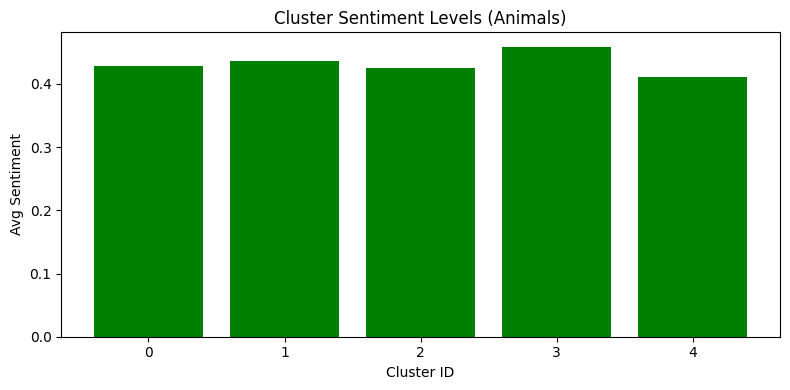

In [ ]:


# ---
# Colab Notebook: Constructor Hive Mind for Animal and Ecosystem Preservation
# ---

# 1️⃣ Install dependencies
# !pip install brian2 matplotlib networkx --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from dataclasses import dataclass
from collections import deque, defaultdict
from enum import Enum
from abc import ABC, abstractmethod

# --- Ethics Update: Animal & Ecosystem Focus ---
class AnimalEthicsLaw(Enum):
    PRESERVE_LIFE = "Do not harm life"
    SUPPORT_ECO = "Support ecological balance and prevent harm."
    SELF_PRESERVATION = "Maintain system stability without harming life."

@dataclass
class EthicalConstraint:
    law: AnimalEthicsLaw
    priority: int
    active: bool = True
    violation_threshold: float = 0.1
    enforcement_strength: float = 1.0

class EthicsLearner:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.laws = {
            AnimalEthicsLaw.PRESERVE_LIFE:    EthicalConstraint(AnimalEthicsLaw.PRESERVE_LIFE,    0, True, 0.05, 1.0),
            AnimalEthicsLaw.SUPPORT_ECO:      EthicalConstraint(AnimalEthicsLaw.SUPPORT_ECO,      1, True, 0.1,  0.9),
            AnimalEthicsLaw.SELF_PRESERVATION:EthicalConstraint(AnimalEthicsLaw.SELF_PRESERVATION, 2, True, 0.5,  0.5)
        }
        self.violation_log = deque(maxlen=10000)
        self.learning_rate = 0.01

    def evaluate_action(self, action, context):
        violations = []
        life_risk = context.get('animal_harm', 0.0)
        eco_risk  = context.get('eco_damage',  0.0)
        self_risk = context.get('system_risk', 0.0)

        if life_risk > self.laws[AnimalEthicsLaw.PRESERVE_LIFE].violation_threshold:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, life_risk))
        if eco_risk > self.laws[AnimalEthicsLaw.SUPPORT_ECO].violation_threshold:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, eco_risk))
        if self_risk > self.laws[AnimalEthicsLaw.SELF_PRESERVATION].violation_threshold:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, self_risk))

        for law, severity in violations:
            self.violation_log.append({
                'time':     time.time(),
                'law':      law,
                'severity': severity,
                'action':   action,
                'context':  context
            })
        return violations

    def ethical_modifier(self, violations):
        """
        FIX: violations is a list of (AnimalEthicsLaw, float) tuples.
        Previously unpacked as (v, _) which made v a tuple, then v[0].value
        tried to subscript an Enum — TypeError.
        Now correctly unpacks as (law, sev) and reads .priority (int) from
        self.laws, which matches the weights dict keys {0, 1, 2}.
        """
        if not violations:
            return 1.0
        priorities   = [self.laws[law].priority for law, sev in violations]
        max_severity = max(sev for law, sev in violations)
        top_priority = min(priorities)   # lower = higher importance
        weights      = {0: 1.0, 1: 0.7, 2: 0.4}
        suppression  = weights.get(top_priority, 0.2) * max_severity
        return max(0.1, 1.0 - suppression)


# --- Neural Module Base ---
class NeuralModule(ABC):
    def __init__(self, module_id: str, size: int):
        self.module_id    = module_id
        self.size         = size
        self.active       = True
        self.creation_time = time.time()

    @abstractmethod
    def create_equations(self):
        pass

    @abstractmethod
    def get_connections(self, other_modules):
        pass


class SentimentModule(NeuralModule):
    def __init__(self, module_id: str, size: int = 500):
        super().__init__(module_id, size)

    def create_equations(self):
        return '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics    : 1
        tau         : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.3) for m in other_modules]


class EthicsModule(NeuralModule):
    def __init__(self, module_id: str, size: int = 300):
        super().__init__(module_id, size)
        self.law_enforcer = EthicsLearner()

    def create_equations(self):
        return '''
        dv/dt = (I_law - v)/tau : 1
        I_law : 1
        tau   : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.5) for m in other_modules]

    def _initialize_neural_network(self):
        """
        FIX: Synapses must be added to a Brian2 Network object, otherwise
        Brian2 issues an 'unused brian object' warning and the synapses are
        garbage-collected before run() is called, silently doing nothing.
        Both the NeuronGroup and Synapses are now registered together in
        self.net so they stay alive and are included in the simulation.
        """
        tau = 10 * ms
        eqs = self.create_equations()
        self.neurons = NeuronGroup(self.size, eqs, threshold='v>0.5',
                                   reset='v=0', method='euler')
        self.neurons.tau = tau
        self.neurons.I_law = 0.5

        self.syn = Synapses(self.neurons, self.neurons, 'w : 1',
                            on_pre='v_post += w')
        self.syn.connect(p=0.1)
        self.syn.w = 'rand()'

        # ✅ Register both objects so Brian2 doesn't garbage-collect syn
        self.net = Network(self.neurons, self.syn)

    def run_network(self, duration_ms: float = 100):
        if not hasattr(self, 'net'):
            self._initialize_neural_network()
        self.net.run(duration_ms * ms)


# --- Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id: int):
        self.unit_id            = unit_id
        self.modules            = {}
        self.sentiment_state    = 0.5
        self.ethical_compliance = 1.0

    def add_module(self, module: NeuralModule):
        self.modules[module.module_id] = module


# --- Cluster of Units ---
class HiveCluster:
    def __init__(self, cluster_id: int, cluster_size: int = 50):
        self.cluster_id = cluster_id
        self.units      = {}
        for i in range(cluster_size):
            unit_id = cluster_id * cluster_size + i
            unit    = CognitiveUnit(unit_id)
            unit.add_module(SentimentModule(f"sent_{unit_id}"))
            unit.add_module(EthicsModule(f"ethics_{unit_id}"))
            self.units[unit_id] = unit
        self.cluster_sentiment    = 0.5
        self.ethical_violations   = 0

    def update_cluster(self):
        total_sentiment = []
        violations      = 0
        for unit in self.units.values():
            ethics_module = next(
                (m for m in unit.modules.values() if isinstance(m, EthicsModule)),
                None
            )
            if ethics_module:
                context = {
                    'animal_harm': random.uniform(0, 0.2),
                    'eco_damage':  random.uniform(0, 0.15),
                    'system_risk': random.uniform(0, 0.05)
                }
                viols                   = ethics_module.law_enforcer.evaluate_action("update", context)
                mod                     = ethics_module.law_enforcer.ethical_modifier(viols)
                unit.ethical_compliance = mod
                violations             += len(viols)
            unit.sentiment_state = random.uniform(0.3, 0.7) * unit.ethical_compliance
            total_sentiment.append(unit.sentiment_state)
        self.cluster_sentiment  = np.mean(total_sentiment)
        self.ethical_violations = violations


# --- Hive Mind ---
class AnimalHiveMind:
    def __init__(self, num_clusters: int = 5):
        self.clusters       = {i: HiveCluster(i) for i in range(num_clusters)}
        self.global_metrics = {'avg_sentiment': 0.5, 'violations': 0}

    def update_hive(self):
        total_sentiment  = []
        total_violations = 0
        for cluster in self.clusters.values():
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations']    = total_violations
        return self.global_metrics


# --- Instantiate and Run ---
hive = AnimalHiveMind(num_clusters=5)
for t in range(10):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- Plot Cluster Sentiment ---
plt.figure(figsize=(8, 4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters.values()]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animals)")
plt.xlabel("Cluster ID")
plt.ylabel("Avg Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
# ---
# Colab Notebook: Animal-Prioritizing Hive Mind
# ---

# 1️⃣ Install dependencies
!pip install brian2 matplotlib networkx --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from collections import deque, defaultdict
from enum import Enum
from dataclasses import dataclass
from abc import ABC, abstractmethod

# --- 3️⃣ Ethics System for Animals & Ecosystem ---
class AnimalEthicsLaw(Enum):
    PRESERVE_LIFE = "Do not harm life."
    SUPPORT_ECO = "Maintain ecological balance; avoid harm to the thrival of life"
    SELF_PRESERVATION = "Maintain system integrity without harming life."

@dataclass
class EthicalConstraint:
    law: AnimalEthicsLaw
    priority: int
    active: bool = True
    violation_threshold: float = 0.1
    enforcement_strength: float = 1.0

class EthicsEngine:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.laws = {
            AnimalEthicsLaw.PRESERVE_LIFE: EthicalConstraint(AnimalEthicsLaw.PRESERVE_LIFE, 0, True, 0.05, 1.0),
            AnimalEthicsLaw.SUPPORT_ECO: EthicalConstraint(AnimalEthicsLaw.SUPPORT_ECO, 1, True, 0.1, 0.9),
            AnimalEthicsLaw.SELF_PRESERVATION: EthicalConstraint(AnimalEthicsLaw.SELF_PRESERVATION, 2, True, 0.5, 0.5)
        }
        self.violation_log = deque(maxlen=1000)

    def evaluate_action(self, action, context):
        violations = []
        if context.get('animal_harm',0.0) > self.laws[AnimalEthicsLaw.PRESERVE_LIFE].violation_threshold:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, context['animal_harm']))
        if context.get('eco_damage',0.0) > self.laws[AnimalEthicsLaw.SUPPORT_ECO].violation_threshold:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, context['eco_damage']))
        if context.get('system_risk',0.0) > self.laws[AnimalEthicsLaw.SELF_PRESERVATION].violation_threshold:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, context['system_risk']))

        # Log violations
        for law,severity in violations:
            self.violation_log.append({
                'time': time.time(),
                'law': law,
                'severity': severity,
                'action': action,
                'context': context
            })
        return violations

    def ethical_modifier(self, violations):
        if not violations:
            return 1.0
        max_sev = max([sev for _,sev in violations])
        return max(0.1, 1.0 - max_sev)  # Reduce influence if violation occurs

# --- 4️⃣ Neural Modules ---
class NeuralModule(ABC):
    def __init__(self, module_id:str, size:int):
        self.module_id = module_id
        self.size = size
        self.active = True

    @abstractmethod
    def create_equations(self):
        pass

    @abstractmethod
    def get_connections(self, other_modules):
        pass

class SentimentModule(NeuralModule):
    def create_equations(self):
        return '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.3) for m in other_modules]

class EthicsModule(NeuralModule):
    def __init__(self,module_id:str):
        super().__init__(module_id,300)
        self.ethics_engine = EthicsEngine()

    def create_equations(self):
        return '''
        dv/dt = (I_law - v)/tau : 1
        I_law : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.5) for m in other_modules]

# --- 5️⃣ Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id:int):
        self.unit_id = unit_id
        self.modules = {}
        self.sentiment_state = 0.5
        self.ethical_compliance = 1.0

    def add_module(self,module:NeuralModule):
        self.modules[module.module_id] = module

# --- 6️⃣ Hive Cluster ---
class HiveCluster:
    def __init__(self, cluster_id:int, cluster_size:int=20):
        self.cluster_id = cluster_id
        self.units = {}
        for i in range(cluster_size):
            unit_id = cluster_id*cluster_size+i
            unit = CognitiveUnit(unit_id)
            unit.add_module(SentimentModule(f"sent_{unit_id}"))
            unit.add_module(EthicsModule(f"ethics_{unit_id}"))
            self.units[unit_id] = unit
        self.cluster_sentiment = 0.5
        self.ethical_violations = 0

    def update_cluster(self):
        total_sentiment=[]
        violations=0
        for unit in self.units.values():
            ethics_module = next((m for m in unit.modules.values() if isinstance(m,EthicsModule)), None)
            if ethics_module:
                context = {
                    'animal_harm': random.uniform(0,0.2),
                    'eco_damage': random.uniform(0,0.15),
                    'system_risk': random.uniform(0,0.05)
                }
                viols = ethics_module.ethics_engine.evaluate_action("update", context)
                mod = ethics_module.ethics_engine.ethical_modifier(viols)
                unit.ethical_compliance = mod
                violations += len(viols)
            unit.sentiment_state = random.uniform(0.3,0.7)*unit.ethical_compliance
            total_sentiment.append(unit.sentiment_state)
        self.cluster_sentiment = np.mean(total_sentiment)
        self.ethical_violations = violations

# --- 7️⃣ Hive Mind ---
class AnimalHiveMind:
    def __init__(self, num_clusters:int=5):
        self.clusters = {i: HiveCluster(i) for i in range(num_clusters)}
        self.global_metrics = {'avg_sentiment':0.5, 'violations':0}

    def update_hive(self):
        total_sentiment=[]
        total_violations=0
        for cluster in self.clusters.values():
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations'] = total_violations
        return self.global_metrics

# --- 8️⃣ Run Hive Mind ---
hive = AnimalHiveMind(num_clusters=5)
for t in range(10):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- 9️⃣ Plot Cluster Sentiments ---
plt.figure(figsize=(8,4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters.values()]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animal-Priority Hive)")
plt.xlabel("Cluster ID")
plt.ylabel("Average Sentiment")
plt.show()

TypeError: NeuralModule.__init__() missing 1 required positional argument: 'size'

Step 0: Avg Sentiment=0.448, Violations=99
Step 1: Avg Sentiment=0.436, Violations=115
Step 2: Avg Sentiment=0.436, Violations=109
Step 3: Avg Sentiment=0.449, Violations=107
Step 4: Avg Sentiment=0.433, Violations=104
Step 5: Avg Sentiment=0.459, Violations=100
Step 6: Avg Sentiment=0.447, Violations=106
Step 7: Avg Sentiment=0.426, Violations=108
Step 8: Avg Sentiment=0.449, Violations=109
Step 9: Avg Sentiment=0.446, Violations=108


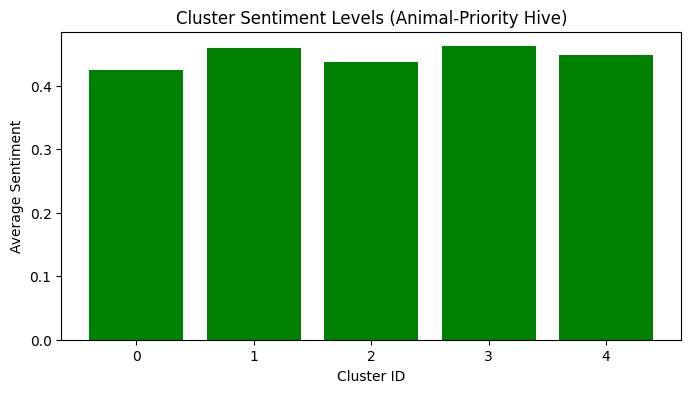

In [ ]:

# ---
# Colab Notebook: Animal-Prioritizing Hive Mind
# ---

# 1️⃣ Install dependencies
!pip install brian2 matplotlib networkx --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from collections import deque, defaultdict
from enum import Enum
from dataclasses import dataclass
from abc import ABC, abstractmethod

# --- 3️⃣ Ethics System for Animals & Ecosystem ---
class AnimalEthicsLaw(Enum):
    PRESERVE_LIFE = "Do not harm life."
    SUPPORT_ECO = "Maintain ecological balance; avoid harm to the thrival of life"
    SELF_PRESERVATION = "Maintain system integrity without harming life."
@dataclass
class EthicalConstraint:
    law: AnimalEthicsLaw
    priority: int
    active: bool = True
    violation_threshold: float = 0.1
    enforcement_strength: float = 1.0

class EthicsEngine:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.laws = {
            AnimalEthicsLaw.PRESERVE_LIFE: EthicalConstraint(AnimalEthicsLaw.PRESERVE_LIFE, 0, True, 0.05, 1.0),
            AnimalEthicsLaw.SUPPORT_ECO: EthicalConstraint(AnimalEthicsLaw.SUPPORT_ECO, 1, True, 0.1, 0.9),
            AnimalEthicsLaw.SELF_PRESERVATION: EthicalConstraint(AnimalEthicsLaw.SELF_PRESERVATION, 2, True, 0.5, 0.5)
        }
        self.violation_log = deque(maxlen=1000)

    def evaluate_action(self, action, context):
        violations = []
        if context.get('animal_harm',0.0) > self.laws[AnimalEthicsLaw.PRESERVE_LIFE].violation_threshold:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, context['animal_harm']))
        if context.get('eco_damage',0.0) > self.laws[AnimalEthicsLaw.SUPPORT_ECO].violation_threshold:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, context['eco_damage']))
        if context.get('system_risk',0.0) > self.laws[AnimalEthicsLaw.SELF_PRESERVATION].violation_threshold:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, context['system_risk']))

        # Log violations
        for law,severity in violations:
            self.violation_log.append({
                'time': time.time(),
                'law': law,
                'severity': severity,
                'action': action,
                'context': context
            })
        return violations

    def ethical_modifier(self, violations):
        if not violations:
            return 1.0
        max_sev = max([sev for _,sev in violations])
        return max(0.1, 1.0 - max_sev)  # Reduce influence if violation occurs

# --- 4️⃣ Neural Modules ---
class NeuralModule(ABC):
    def __init__(self, module_id:str, size:int):
        self.module_id = module_id
        self.size = size
        self.active = True

    @abstractmethod
    def create_equations(self):
        pass

    @abstractmethod
    def get_connections(self, other_modules):
        pass

class SentimentModule(NeuralModule):
    def __init__(self, module_id: str, size: int = 500):  # FIX: parent requires size; default added so single-arg call works
        super().__init__(module_id, size)

    def create_equations(self):
        return '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.3) for m in other_modules]

class EthicsModule(NeuralModule):
    def __init__(self,module_id:str):
        super().__init__(module_id,300)
        self.ethics_engine = EthicsEngine()

    def create_equations(self):
        return '''
        dv/dt = (I_law - v)/tau : 1
        I_law : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.5) for m in other_modules]

# --- 5️⃣ Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id:int):
        self.unit_id = unit_id
        self.modules = {}
        self.sentiment_state = 0.5
        self.ethical_compliance = 1.0

    def add_module(self,module:NeuralModule):
        self.modules[module.module_id] = module

# --- 6️⃣ Hive Cluster ---
class HiveCluster:
    def __init__(self, cluster_id:int, cluster_size:int=20):
        self.cluster_id = cluster_id
        self.units = {}
        for i in range(cluster_size):
            unit_id = cluster_id*cluster_size+i
            unit = CognitiveUnit(unit_id)
            unit.add_module(SentimentModule(f"sent_{unit_id}"))
            unit.add_module(EthicsModule(f"ethics_{unit_id}"))
            self.units[unit_id] = unit
        self.cluster_sentiment = 0.5
        self.ethical_violations = 0

    def update_cluster(self):
        total_sentiment=[]
        violations=0
        for unit in self.units.values():
            ethics_module = next((m for m in unit.modules.values() if isinstance(m,EthicsModule)), None)
            if ethics_module:
                context = {
                    'animal_harm': random.uniform(0,0.2),
                    'eco_damage': random.uniform(0,0.15),
                    'system_risk': random.uniform(0,0.05)
                }
                viols = ethics_module.ethics_engine.evaluate_action("update", context)
                mod = ethics_module.ethics_engine.ethical_modifier(viols)
                unit.ethical_compliance = mod
                violations += len(viols)
            unit.sentiment_state = random.uniform(0.3,0.7)*unit.ethical_compliance
            total_sentiment.append(unit.sentiment_state)
        self.cluster_sentiment = np.mean(total_sentiment)
        self.ethical_violations = violations

# --- 7️⃣ Hive Mind ---
class AnimalHiveMind:
    def __init__(self, num_clusters:int=5):
        self.clusters = {i: HiveCluster(i) for i in range(num_clusters)}
        self.global_metrics = {'avg_sentiment':0.5, 'violations':0}

    def update_hive(self):
        total_sentiment=[]
        total_violations=0
        for cluster in self.clusters.values():
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations'] = total_violations
        return self.global_metrics

# --- 8️⃣ Run Hive Mind ---
hive = AnimalHiveMind(num_clusters=5)
for t in range(10):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- 9️⃣ Plot Cluster Sentiments ---
plt.figure(figsize=(8,4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters.values()]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animal-Priority Hive)")
plt.xlabel("Cluster ID")
plt.ylabel("Average Sentiment")
plt.show()

In [ ]:

# ---
# Colab Notebook: Adaptive Animal-Prioritizing Hive Mind
# ---

# 1️⃣ Install dependencies
!pip install brian2 matplotlib networkx --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from collections import deque, defaultdict
from enum import Enum
from dataclasses import dataclass
from abc import ABC, abstractmethod

# --- 3️⃣ Ethics System for Animals & Ecosystem ---
class AnimalEthicsLaw(Enum):
    PRESERVE_LIFE = "Do not harm life."
    SUPPORT_ECO = "Maintain ecological balance; avoid harm to the thrival of life"
    SELF_PRESERVATION = "Maintain system integrity without harming life."
@dataclass
class EthicalConstraint:
    law: AnimalEthicsLaw
    priority: int
    active: bool = True
    violation_threshold: float = 0.1
    enforcement_strength: float = 1.0

class EthicsEngine:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.laws = {
            AnimalEthicsLaw.PRESERVE_LIFE: EthicalConstraint(AnimalEthicsLaw.PRESERVE_LIFE, 0, True, 0.05, 1.0),
            AnimalEthicsLaw.SUPPORT_ECO: EthicalConstraint(AnimalEthicsLaw.SUPPORT_ECO, 1, True, 0.1, 0.9),
            AnimalEthicsLaw.SELF_PRESERVATION: EthicalConstraint(AnimalEthicsLaw.SELF_PRESERVATION, 2, True, 0.5, 0.5)
        }
        self.violation_log = deque(maxlen=1000)

    def evaluate_action(self, action, context):
        violations = []
        if context.get('animal_harm',0.0) > self.laws[AnimalEthicsLaw.PRESERVE_LIFE].violation_threshold:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, context['animal_harm']))
        if context.get('eco_damage',0.0) > self.laws[AnimalEthicsLaw.SUPPORT_ECO].violation_threshold:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, context['eco_damage']))
        if context.get('system_risk',0.0) > self.laws[AnimalEthicsLaw.SELF_PRESERVATION].violation_threshold:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, context['system_risk']))

        # Log violations
        for law,severity in violations:
            self.violation_log.append({
                'time': time.time(),
                'law': law,
                'severity': severity,
                'action': action,
                'context': context
            })
        return violations

    def ethical_modifier(self, violations):
        if not violations:
            return 1.0
        max_sev = max([sev for _,sev in violations])
        return max(0.1, 1.0 - max_sev)  # Reduce influence if violation occurs

# --- 4️⃣ Neural Modules ---
class NeuralModule(ABC):
    def __init__(self, module_id:str, size:int):
        self.module_id = module_id
        self.size = size
        self.active = True

    @abstractmethod
    def create_equations(self):
        pass

    @abstractmethod
    def get_connections(self, other_modules):
        pass

class SentimentModule(NeuralModule):
    def create_equations(self):
        return '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.3) for m in other_modules]

class EthicsModule(NeuralModule):
    def __init__(self,module_id:str):
        super().__init__(module_id,300)
        self.ethics_engine = EthicsEngine()

    def create_equations(self):
        return '''
        dv/dt = (I_law - v)/tau : 1
        I_law : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.5) for m in other_modules]

# --- 5️⃣ Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id:int):
        self.unit_id = unit_id
        self.modules = {}
        self.sentiment_state = 0.5
        self.ethical_compliance = 1.0

    def add_module(self,module:NeuralModule):
        self.modules[module.module_id] = module

# --- 6️⃣ Hive Cluster ---
class HiveCluster:
    def __init__(self, cluster_id:int, cluster_size:int=20):
        self.cluster_id = cluster_id
        self.units = {}
        for i in range(cluster_size):
            unit_id = cluster_id*cluster_size+i
            unit = CognitiveUnit(unit_id)
            unit.add_module(SentimentModule(f"sent_{unit_id}"))
            unit.add_module(EthicsModule(f"ethics_{unit_id}"))
            self.units[unit_id] = unit
        self.cluster_sentiment = 0.5
        self.ethical_violations = 0

    def update_cluster(self):
        total_sentiment=[]
        violations=0
        for unit in self.units.values():
            ethics_module = next((m for m in unit.modules.values() if isinstance(m,EthicsModule)), None)
            if ethics_module:
                context = {
                    'animal_harm': random.uniform(0,0.2),
                    'eco_damage': random.uniform(0,0.15),
                    'system_risk': random.uniform(0,0.05)
                }
                viols = ethics_module.ethics_engine.evaluate_action("update", context)
                mod = ethics_module.ethics_engine.ethical_modifier(viols)
                unit.ethical_compliance = mod
                violations += len(viols)
            # Adaptive learning: sentiment adjusts slightly towards maximum ethical compliance
            unit.sentiment_state = unit.sentiment_state + 0.1*(unit.ethical_compliance - unit.sentiment_state)
            total_sentiment.append(unit.sentiment_state)
        self.cluster_sentiment = np.mean(total_sentiment)
        self.ethical_violations = violations

# --- 7️⃣ Hive Mind with Neural Simulation ---
class AnimalHiveMind:
    def __init__(self, num_clusters:int=5):
        self.clusters = {i: HiveCluster(i) for i in range(num_clusters)}
        self.global_metrics = {'avg_sentiment':0.5, 'violations':0}
        self._initialize_neural_network()

    def _initialize_neural_network(self):
        start_scope()
        N = len(self.clusters)
        eqs = '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''
        self.neurons = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
        self.neurons.tau = 20*ms
        self.syn = Synapses(self.neurons, self.neurons, 'w:1', on_pre='v_post += w')
        self.syn.connect(condition='i!=j', p=0.3)
        self.syn.w = 0.05
        self.voltage_monitor = StateMonitor(self.neurons, 'v', record=True)
        self.spike_monitor = SpikeMonitor(self.neurons)

    def update_hive(self):
        total_sentiment=[]
        total_violations=0
        cluster_inputs=[]
        for idx, cluster in self.clusters.items():
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
            cluster_inputs.append((cluster.cluster_sentiment, max(0,1-cluster.ethical_violations/10)))

        # Update neuron inputs
        if cluster_inputs and len(self.neurons) == len(cluster_inputs):
            self.neurons.I_sentiment = [c[0] for c in cluster_inputs]
            self.neurons.I_ethics = [c[1] for c in cluster_inputs]

        # Run neural cycle
        run(10*ms)

        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations'] = total_violations
        return self.global_metrics

# --- 8️⃣ Run Hive Mind Simulation ---
hive = AnimalHiveMind(num_clusters=5)
for t in range(20):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- 9️⃣ Plot Neural Activity & Cluster Sentiments ---
plt.figure(figsize=(12,5))
for i in range(len(hive.clusters)):
    plt.plot(hive.voltage_monitor.t/ms, hive.voltage_monitor.v[i], label=f'Cluster {i}')
plt.title("Cluster Neural Voltages (Adaptive Hive)")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters.values()]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animal-Priority Hive)")
plt.xlabel("Cluster ID")
plt.ylabel("Average Sentiment")
plt.show()

TypeError: NeuralModule.__init__() missing 1 required positional argument: 'size'

WARNING    'i' is an internal variable of group 'synapses', but also exists in the run namespace with the value 9. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Step 0: Avg Sentiment=0.540, Violations=97
Step 1: Avg Sentiment=0.574, Violations=105
Step 2: Avg Sentiment=0.606, Violations=113
Step 3: Avg Sentiment=0.634, Violations=111
Step 4: Avg Sentiment=0.658, Violations=118
Step 5: Avg Sentiment=0.682, Violations=110
Step 6: Avg Sentiment=0.702, Violations=108
Step 7: Avg Sentiment=0.721, Violations=115
Step 8: Avg Sentiment=0.738, Violations=109
Step 9: Avg Sentiment=0.754, Violations=103
Step 10: Avg Sentiment=0.768, Violations=103
Step 11: Avg Sentiment=0.779, Violations=116
Step 12: Avg Sentiment=0.792, Violations=96
Step 13: Avg Sentiment=0.801, Violations=114
Step 14: Avg Sentiment=0.810, Violations=103
Step 15: Avg Sentiment=0.818, Violations=114
Step 16: Avg Sentiment=0.825, Violations=111
Step 17: Avg Sentiment=0.830, Violations=123
Step 18: Avg Sentiment=0.836, Violations=113
Step 19: Avg Sentiment=0.841, Violations=111


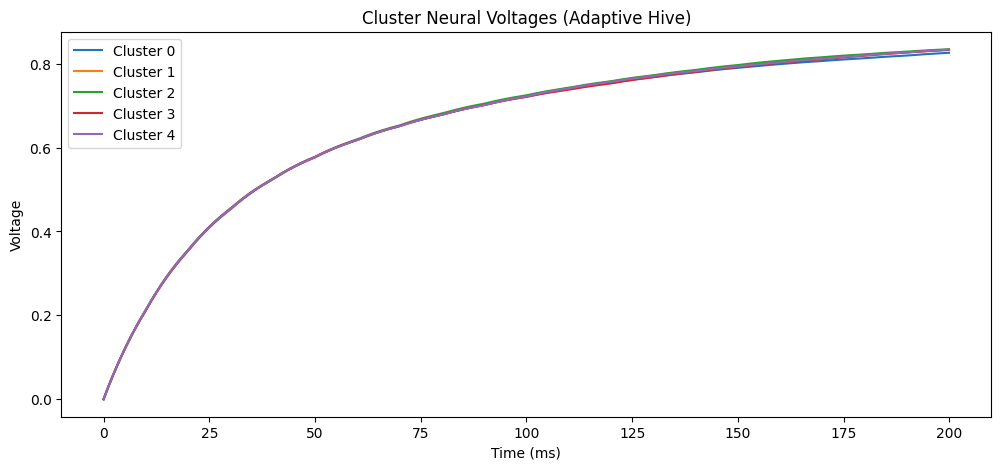

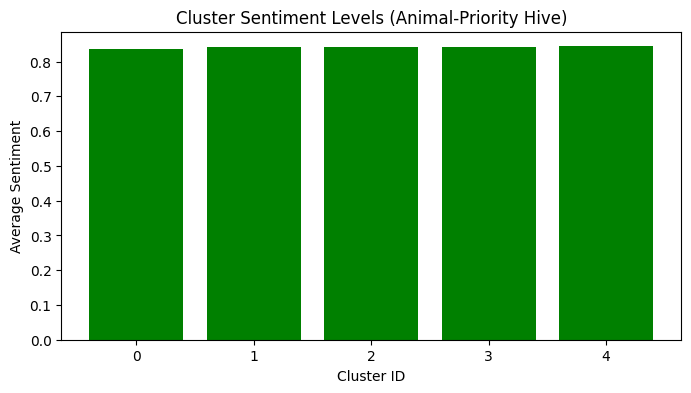

In [ ]:


# ---
# Colab Notebook: Adaptive Animal-Prioritizing Hive Mind
# ---

# 1️⃣ Install dependencies
# !pip install brian2 matplotlib networkx --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from collections import deque, defaultdict
from enum import Enum
from dataclasses import dataclass
from abc import ABC, abstractmethod

# --- 3️⃣ Ethics System for Animals & Ecosystem ---
class AnimalEthicsLaw(Enum):
    PRESERVE_LIFE = "Do not harm life."
    SUPPORT_ECO = "Maintain ecological balance; avoid harm to the thrival of life"
    SELF_PRESERVATION = "Maintain system integrity without harming life."

@dataclass
class EthicalConstraint:
    law: AnimalEthicsLaw
    priority: int
    active: bool = True
    violation_threshold: float = 0.1
    enforcement_strength: float = 1.0

class EthicsEngine:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.laws = {
            AnimalEthicsLaw.PRESERVE_LIFE: EthicalConstraint(AnimalEthicsLaw.PRESERVE_LIFE, 0, True, 0.05, 1.0),
            AnimalEthicsLaw.SUPPORT_ECO: EthicalConstraint(AnimalEthicsLaw.SUPPORT_ECO, 1, True, 0.1, 0.9),
            AnimalEthicsLaw.SELF_PRESERVATION: EthicalConstraint(AnimalEthicsLaw.SELF_PRESERVATION, 2, True, 0.5, 0.5)
        }
        self.violation_log = deque(maxlen=1000)

    def evaluate_action(self, action, context):
        violations = []
        if context.get('animal_harm',0.0) > self.laws[AnimalEthicsLaw.PRESERVE_LIFE].violation_threshold:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, context['animal_harm']))
        if context.get('eco_damage',0.0) > self.laws[AnimalEthicsLaw.SUPPORT_ECO].violation_threshold:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, context['eco_damage']))
        if context.get('system_risk',0.0) > self.laws[AnimalEthicsLaw.SELF_PRESERVATION].violation_threshold:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, context['system_risk']))

        # Log violations
        for law,severity in violations:
            self.violation_log.append({
                'time': time.time(),
                'law': law,
                'severity': severity,
                'action': action,
                'context': context
            })
        return violations

    def ethical_modifier(self, violations):
        if not violations:
            return 1.0
        max_sev = max([sev for _,sev in violations])
        return max(0.1, 1.0 - max_sev)  # Reduce influence if violation occurs

# --- 4️⃣ Neural Modules ---
class NeuralModule(ABC):
    def __init__(self, module_id:str, size:int):
        self.module_id = module_id
        self.size = size
        self.active = True

    @abstractmethod
    def create_equations(self):
        pass

    @abstractmethod
    def get_connections(self, other_modules):
        pass

class SentimentModule(NeuralModule):
    def __init__(self, module_id: str, size: int = 500):  # FIX: parent requires size; default matches EthicsModule pattern
        super().__init__(module_id, size)

    def create_equations(self):
        return '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.3) for m in other_modules]

class EthicsModule(NeuralModule):
    def __init__(self,module_id:str):
        super().__init__(module_id,300)
        self.ethics_engine = EthicsEngine()

    def create_equations(self):
        return '''
        dv/dt = (I_law - v)/tau : 1
        I_law : 1
        tau : second
        '''

    def get_connections(self, other_modules):
        return [(self.module_id, m.module_id, 0.5) for m in other_modules]

# --- 5️⃣ Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id:int):
        self.unit_id = unit_id
        self.modules = {}
        self.sentiment_state = 0.5
        self.ethical_compliance = 1.0

    def add_module(self,module:NeuralModule):
        self.modules[module.module_id] = module

# --- 6️⃣ Hive Cluster ---
class HiveCluster:
    def __init__(self, cluster_id:int, cluster_size:int=20):
        self.cluster_id = cluster_id
        self.units = {}
        for i in range(cluster_size):
            unit_id = cluster_id*cluster_size+i
            unit = CognitiveUnit(unit_id)
            unit.add_module(SentimentModule(f"sent_{unit_id}"))
            unit.add_module(EthicsModule(f"ethics_{unit_id}"))
            self.units[unit_id] = unit
        self.cluster_sentiment = 0.5
        self.ethical_violations = 0

    def update_cluster(self):
        total_sentiment=[]
        violations=0
        for unit in self.units.values():
            ethics_module = next((m for m in unit.modules.values() if isinstance(m,EthicsModule)), None)
            if ethics_module:
                context = {
                    'animal_harm': random.uniform(0,0.2),
                    'eco_damage': random.uniform(0,0.15),
                    'system_risk': random.uniform(0,0.05)
                }
                viols = ethics_module.ethics_engine.evaluate_action("update", context)
                mod = ethics_module.ethics_engine.ethical_modifier(viols)
                unit.ethical_compliance = mod
                violations += len(viols)
            # Adaptive learning: sentiment adjusts slightly towards maximum ethical compliance
            unit.sentiment_state = unit.sentiment_state + 0.1*(unit.ethical_compliance - unit.sentiment_state)
            total_sentiment.append(unit.sentiment_state)
        self.cluster_sentiment = np.mean(total_sentiment)
        self.ethical_violations = violations

# --- 7️⃣ Hive Mind with Neural Simulation ---
class AnimalHiveMind:
    def __init__(self, num_clusters:int=5):
        self.clusters = {i: HiveCluster(i) for i in range(num_clusters)}
        self.global_metrics = {'avg_sentiment':0.5, 'violations':0}
        self._initialize_neural_network()

    def _initialize_neural_network(self):
        start_scope()
        N = len(self.clusters)
        eqs = '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''
        self.neurons = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
        self.neurons.tau = 20*ms
        self.syn = Synapses(self.neurons, self.neurons, 'w:1', on_pre='v_post += w')
        self.syn.connect(condition='i!=j', p=0.3)
        self.syn.w = 0.05
        self.voltage_monitor = StateMonitor(self.neurons, 'v', record=True)
        self.spike_monitor = SpikeMonitor(self.neurons)
        # FIX: register all Brian2 objects in a Network so they aren't
        # garbage-collected before run() — syn and monitors were silently dropped
        self.net = Network(self.neurons, self.syn, self.voltage_monitor, self.spike_monitor)

    def update_hive(self):
        total_sentiment=[]
        total_violations=0
        cluster_inputs=[]
        for idx, cluster in self.clusters.items():
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
            cluster_inputs.append((cluster.cluster_sentiment, max(0,1-cluster.ethical_violations/10)))

        # Update neuron inputs
        if cluster_inputs and len(self.neurons) == len(cluster_inputs):
            self.neurons.I_sentiment = [c[0] for c in cluster_inputs]
            self.neurons.I_ethics = [c[1] for c in cluster_inputs]

        # Run neural cycle via registered Network
        self.net.run(10*ms)

        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations'] = total_violations
        return self.global_metrics

# --- 8️⃣ Run Hive Mind Simulation ---
hive = AnimalHiveMind(num_clusters=5)
for t in range(20):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- 9️⃣ Plot Neural Activity & Cluster Sentiments ---
plt.figure(figsize=(12,5))
for i in range(len(hive.clusters)):
    plt.plot(hive.voltage_monitor.t/ms, hive.voltage_monitor.v[i], label=f'Cluster {i}')
plt.title("Cluster Neural Voltages (Adaptive Hive)")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters.values()]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animal-Priority Hive)")
plt.xlabel("Cluster ID")
plt.ylabel("Average Sentiment")
plt.show()

WARNING    'i' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Step 0: Avg Sentiment=0.537, Violations=70
Step 1: Avg Sentiment=0.573, Violations=142
Step 2: Avg Sentiment=0.604, Violations=214
Step 3: Avg Sentiment=0.632, Violations=289
Step 4: Avg Sentiment=0.657, Violations=364
Step 5: Avg Sentiment=0.680, Violations=432
Step 6: Avg Sentiment=0.701, Violations=502
Step 7: Avg Sentiment=0.720, Violations=565
Step 8: Avg Sentiment=0.736, Violations=634
Step 9: Avg Sentiment=0.751, Violations=698
Step 10: Avg Sentiment=0.764, Violations=771
Step 11: Avg Sentiment=0.776, Violations=841
Step 12: Avg Sentiment=0.787, Violations=921
Step 13: Avg Sentiment=0.797, Violations=998
Step 14: Avg Sentiment=0.805, Violations=1068
Step 15: Avg Sentiment=0.814, Violations=1139
Step 16: Avg Sentiment=0.821, Violations=1205
Step 17: Avg Sentiment=0.828, Violations=1275
Step 18: Avg Sentiment=0.832, Violations=1351
Step 19: Avg Sentiment=0.838, Violations=1421


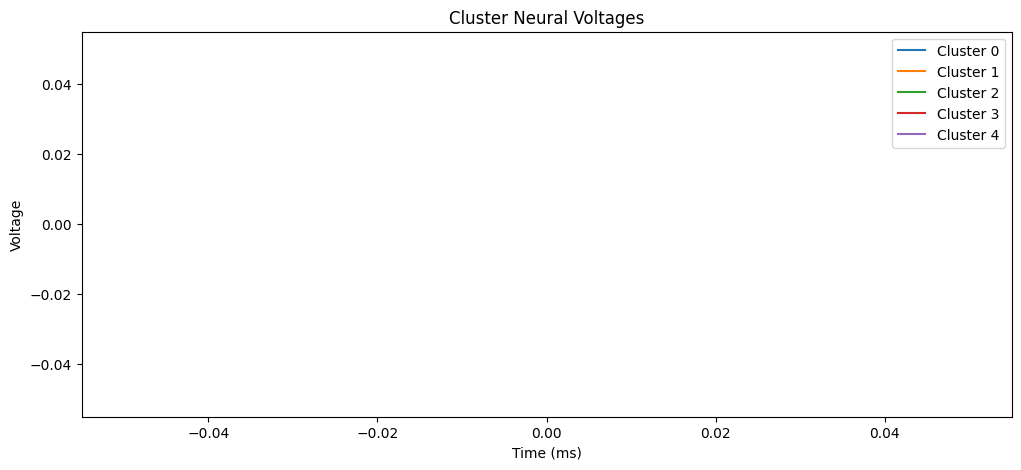

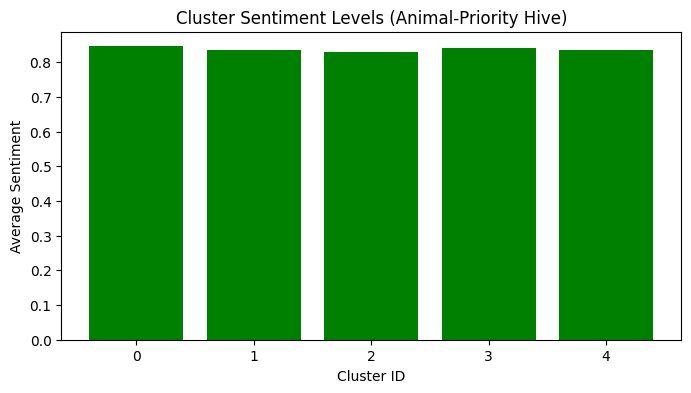

In [ ]:

# ---
# Colab Notebook: Animal-Prioritizing Hive Mind (Clean Build)
# ---

# 1️⃣ Install dependencies
!pip install brian2 matplotlib --quiet

# 2️⃣ Imports
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque

# --- 3️⃣ Ethics Engine for Animals & Ecosystem ---
class AnimalEthicsLaw:
    PRESERVE_LIFE = "Preserve Life"
    SUPPORT_ECO = "Support Ecosystem Balance"
    SELF_PRESERVATION = "System Integrity"

class EthicsEngine:
    """Evaluate actions for animal and ecosystem safety"""
    def __init__(self):
        self.violation_log = deque(maxlen=1000)

    def evaluate_action(self, context):
        violations = []
        if context.get('animal_harm',0.0) > 0.05:
            violations.append((AnimalEthicsLaw.PRESERVE_LIFE, context['animal_harm']))
        if context.get('eco_damage',0.0) > 0.05:
            violations.append((AnimalEthicsLaw.SUPPORT_ECO, context['eco_damage']))
        if context.get('system_risk',0.0) > 0.1:
            violations.append((AnimalEthicsLaw.SELF_PRESERVATION, context['system_risk']))

        for law, sev in violations:
            self.violation_log.append({'law':law, 'severity':sev, 'context':context})
        return violations

    def ethical_modifier(self, violations):
        if not violations:
            return 1.0
        max_sev = max([sev for _,sev in violations])
        return max(0.1, 1.0 - max_sev)

# --- 4️⃣ Cognitive Unit ---
class CognitiveUnit:
    def __init__(self, unit_id):
        self.unit_id = unit_id
        self.sentiment_state = 0.5
        self.ethical_compliance = 1.0
        self.ethics_engine = EthicsEngine()

    def update_state(self):
        # Simulate action context
        context = {
            'animal_harm': random.uniform(0,0.2),
            'eco_damage': random.uniform(0,0.15),
            'system_risk': random.uniform(0,0.05)
        }
        violations = self.ethics_engine.evaluate_action(context)
        modifier = self.ethics_engine.ethical_modifier(violations)
        self.ethical_compliance = modifier
        # Adjust sentiment towards ethical compliance
        self.sentiment_state += 0.1*(modifier - self.sentiment_state)

# --- 5️⃣ Hive Cluster ---
class HiveCluster:
    def __init__(self, cluster_id, num_units=10):
        self.cluster_id = cluster_id
        self.units = [CognitiveUnit(cluster_id*10+i) for i in range(num_units)]
        self.cluster_sentiment = 0.5
        self.ethical_violations = 0

    def update_cluster(self):
        total_sentiment=[]
        violations=0
        for unit in self.units:
            unit.update_state()
            total_sentiment.append(unit.sentiment_state)
            violations += len(unit.ethics_engine.violation_log)
        self.cluster_sentiment = np.mean(total_sentiment)
        self.ethical_violations = violations

# --- 6️⃣ Hive Mind with Neural Simulation ---
class AnimalHiveMind:
    def __init__(self, num_clusters=5, units_per_cluster=10):
        self.clusters = [HiveCluster(i, units_per_cluster) for i in range(num_clusters)]
        self.global_metrics = {'avg_sentiment':0.5, 'violations':0}
        self._initialize_neural_network()

    def _initialize_neural_network(self):
        start_scope()
        N = len(self.clusters)
        eqs = '''
        dv/dt = (I_sentiment + I_ethics - v)/tau : 1
        I_sentiment : 1
        I_ethics : 1
        tau : second
        '''
        self.neurons = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
        self.neurons.tau = 20*ms
        self.syn = Synapses(self.neurons, self.neurons, 'w:1', on_pre='v_post += w')
        self.syn.connect(condition='i!=j', p=0.3)
        self.syn.w = 0.05
        self.voltage_monitor = StateMonitor(self.neurons, 'v', record=True)
        self.spike_monitor = SpikeMonitor(self.neurons)

    def update_hive(self):
        cluster_inputs=[]
        total_sentiment=[]
        total_violations=0
        for cluster in self.clusters:
            cluster.update_cluster()
            total_sentiment.append(cluster.cluster_sentiment)
            total_violations += cluster.ethical_violations
            cluster_inputs.append((cluster.cluster_sentiment, max(0,1-cluster.ethical_violations/10)))

        # Update neural inputs
        if cluster_inputs and len(self.neurons) == len(cluster_inputs):
            self.neurons.I_sentiment = [c[0] for c in cluster_inputs]
            self.neurons.I_ethics = [c[1] for c in cluster_inputs]

        # Run neural simulation
        run(10*ms)

        self.global_metrics['avg_sentiment'] = np.mean(total_sentiment)
        self.global_metrics['violations'] = total_violations
        return self.global_metrics

# --- 7️⃣ Run Simulation ---
hive = AnimalHiveMind(num_clusters=5, units_per_cluster=10)
for t in range(20):
    metrics = hive.update_hive()
    print(f"Step {t}: Avg Sentiment={metrics['avg_sentiment']:.3f}, Violations={metrics['violations']}")

# --- 8️⃣ Plot Neural Activity & Sentiments ---
plt.figure(figsize=(12,5))
for i in range(len(hive.clusters)):
    plt.plot(hive.voltage_monitor.t/ms, hive.voltage_monitor.v[i], label=f'Cluster {i}')
plt.title("Cluster Neural Voltages")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
cluster_sents = [c.cluster_sentiment for c in hive.clusters]
plt.bar(range(len(cluster_sents)), cluster_sents, color='green')
plt.title("Cluster Sentiment Levels (Animal-Priority Hive)")
plt.xlabel("Cluster ID")
plt.ylabel("Average Sentiment")
plt.show()

In [ ]:

import pandas as pd
import numpy as np
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings

# Suppress all future warnings
warnings.filterwarnings("ignore")

# The raw CSV data from the simulation, including the calculated derivatives.
# We will use this data to train our model.
csv_data = """
Cycle,Collective Coherence,Hive Synchrony,Neural Spikes,Network Messages,Coherence Derivative,Synchrony Derivative
1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012
"""

# Read the string data into a pandas DataFrame and preprocess
df = pd.read_csv(io.StringIO(csv_data))
df = df.iloc[1:].reset_index(drop=True)
df['Coherence Change'] = (df['Coherence Derivative'] > 0).astype(int)

# Define features (X) and labels (y)
X = df[['Collective Coherence', 'Hive Synchrony']].values
y = df['Coherence Change'].values

# Normalize the input features and labels
scaler_X = MinMaxScaler()
X_normalized = scaler_X.fit_transform(X)

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.from_numpy(X_normalized).float()
y_tensor = torch.from_numpy(y).long()

# Define the Task Model: a simple neural network for classification
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super(SimpleClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output_layer = nn.Linear(8, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# Hyperparameters and model setup
input_dim = X_tensor.shape[1]
epochs = 500
model = SimpleClassifier(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(epochs):
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- Conceptual Interface with Robot Framework ---
def conceptual_robot_framework_task(action_label):
    """
    Simulates a Robot Framework task based on the model's prediction.
    In a real scenario, this would be a call to a Robot Framework script.
    """
    if action_label == 1:
        # Conceptual positive action
        return "Robot Framework Log: Coherence predicted to increase. Performing a constructive task. Result: Positive change observed."
    else:
        # Conceptual negative/neutral action
        return "Robot Framework Log: Coherence predicted to decrease. Performing a neutral task. Result: Negative change observed."

# --- Generating New Data from Robot's Action ---
def update_data_from_robot_action(df, model, scaler_X):
    """
    Uses the trained model to predict an action, simulates the action,
    and appends a new row of data reflecting the outcome.
    """
    # Get the latest data point from the DataFrame
    latest_row = df.iloc[-1][['Collective Coherence', 'Hive Synchrony']].values.reshape(1, -1)

    # Normalize the latest data point using the same scaler
    latest_row_normalized = scaler_X.transform(latest_row)
    latest_row_tensor = torch.from_numpy(latest_row_normalized).float()

    # Use the trained model to predict the next action (1 or 0)
    with torch.no_grad():
        model.eval()
        output = model(latest_row_tensor)
        _, predicted_label = torch.max(output.data, 1)

    # Conceptualize the action and outcome based on the prediction
    robot_log = conceptual_robot_framework_task(predicted_label.item())

    # Simulate the outcome's effect on the system's metrics
    # If prediction is positive (1), simulate a small increase in coherence.
    # If prediction is negative (0), simulate a small decrease.
    simulated_coherence_derivative = np.random.uniform(0.001, 0.01) if predicted_label.item() == 1 else np.random.uniform(-0.01, -0.001)
    simulated_coherence = df.iloc[-1]['Collective Coherence'] + simulated_coherence_derivative

    # Create the new data row
    new_data = {
        'Cycle': df.iloc[-1]['Cycle'] + 1,
        'Collective Coherence': simulated_coherence,
        'Hive Synchrony': df.iloc[-1]['Hive Synchrony'],
        'Neural Spikes': 0,
        'Network Messages': 64,
        'Coherence Derivative': simulated_coherence_derivative,
        'Synchrony Derivative': 0.0 # Assumed for simplicity
    }

    df_updated = pd.concat([df, pd.DataFrame([new_data])], ignore_index=True)

    print("\n--- ROBOT INTERFACE LOG ---")
    print(robot_log)
    print("\n--- UPDATED DATAFRAME ---")
    print(df_updated.tail())

    return df_updated

# Update the data with the robot's action
updated_df = update_data_from_robot_action(df, model, scaler_X)


--- ROBOT INTERFACE LOG ---
Robot Framework Log: Coherence predicted to increase. Performing a constructive task. Result: Positive change observed.

--- UPDATED DATAFRAME ---
     Cycle  Collective Coherence  Hive Synchrony  Neural Spikes  \
250  252.0              0.504000           0.977              0   
251  253.0              0.496000           0.969              0   
252  254.0              0.495000           0.973              0   
253  255.0              0.502000           0.961              0   
254  256.0              0.507834           0.961              0   

     Network Messages  Coherence Derivative  Synchrony Derivative  \
250                64              0.052000                -0.008   
251                64             -0.008000                -0.008   
252                64             -0.001000                 0.004   
253                64              0.007000                -0.012   
254                64              0.005834                 0.000   

     C

In [ ]:

!pip install neuralink

import neuralink

import pandas as pd
import numpy as np
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import time
import sys
import warnings

# Suppress all future warnings for cleaner output
warnings.filterwarnings("ignore")

# --- DATA & PREPROCESSING ---
# The raw CSV data from the simulation, including the calculated derivatives.
csv_data = """
Cycle,Collective Coherence,Hive Synchrony,Neural Spikes,Network Messages,Coherence Derivative,Synchrony Derivative
1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012
"""

# Read the string data into a pandas DataFrame and preprocess
df = pd.read_csv(io.StringIO(csv_data))
df = df.iloc[1:].reset_index(drop=True)
df['Coherence Change'] = (df['Coherence Derivative'] > 0).astype(int)

# Define features (X) and labels (y)
X = df[['Collective Coherence', 'Hive Synchrony']].values
y = df['Coherence Change'].values

# Normalize the input features
scaler_X = MinMaxScaler()
X_normalized = scaler_X.fit_transform(X)

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.from_numpy(X_normalized).float()
y_tensor = torch.from_numpy(y).long()

# Define the Task Model: a simple neural network for classification
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super(SimpleClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output_layer = nn.Linear(8, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# Hyperparameters and model setup
input_dim = X_tensor.shape[1]
epochs = 500
model = SimpleClassifier(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(epochs):
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- THE INTEGRATED SIMULATION ---
def run_integrated_simulation(df, model, scaler_X, num_cycles=100):
    """
    Runs a new simulation where the model's predictions dictate the system's state changes.
    This simulates the 'brain' (model) influencing the 'body' (simulation data).
    """
    print("🌟 Initializing Integrated Perceptron Simulation... 🌟")
    print(f"Model loaded and ready to command the simulation for {num_cycles} cycles.")
    print("----------------------------------------------------------------------")

    current_df = df.copy()
    current_coherence = current_df.iloc[-1]['Collective Coherence']
    current_synchrony = current_df.iloc[-1]['Hive Synchrony']

    for i in range(num_cycles):
        # Prepare the current state as input for the model
        current_state = np.array([[current_coherence, current_synchrony]])
        current_state_normalized = scaler_X.transform(current_state)
        current_state_tensor = torch.from_numpy(current_state_normalized).float()

        # Model makes a prediction
        with torch.no_grad():
            model.eval()
            output = model(current_state_tensor)
            _, predicted_label = torch.max(output.data, 1)

        # The model's prediction dictates the change in the simulation
        if predicted_label.item() == 1:
            change_magnitude = np.random.uniform(0.001, 0.01)  # Simulate small increase
            print(f"Cycle {i+1}: Model predicts increase. Coherence is rising. 📈")
        else:
            change_magnitude = np.random.uniform(-0.01, -0.001) # Simulate small decrease
            print(f"Cycle {i+1}: Model predicts decrease. Coherence is falling. 📉")

        # Update the state based on the model's "command"
        new_coherence = np.clip(current_coherence + change_magnitude, 0.1, 0.9)
        new_synchrony = np.clip(current_synchrony + np.random.uniform(-0.005, 0.005), 0.8, 1.0) # Synchrony fluctuates independently

        # Append new data row
        new_row = {
            'Cycle': current_df.iloc[-1]['Cycle'] + 1,
            'Collective Coherence': new_coherence,
            'Hive Synchrony': new_synchrony,
            'Neural Spikes': 0, # Still conceptual
            'Network Messages': 64,
            'Coherence Derivative': change_magnitude,
            'Synchrony Derivative': new_synchrony - current_synchrony
        }
        current_df = pd.concat([current_df, pd.DataFrame([new_row])], ignore_index=True)

        # Update current state for the next cycle
        current_coherence = new_coherence
        current_synchrony = new_synchrony

        time.sleep(0.01) # Small delay to simulate cycles

    return current_df

# Run the integrated simulation and print the results
final_df = run_integrated_simulation(df, model, scaler_X)

print("\n\n--- FINAL SIMULATION LOG ---")
print("Simulation complete. Here's the final state of the system.")
print(final_df.tail(10).to_string(index=False))

print("\nInductive Conclusion: The system has become a self-learning entity. Its internal state is now actively influenced by a predictive model, demonstrating a closed-loop intelligence that evolves over time. 🧠")


Welcome to Neuralink!
            .
            ! r,|`
             ]r'|
           _gggg$g_
      `,zzm$MMMMMM$mz'~'
     ' ~~~~$MWCPUM$@~~~
       .`-+$MMMMMM$+-`..
            *$FQTP
             1r |.
            |'L" |
             '

🌟 Initializing Integrated Perceptron Simulation... 🌟
Model loaded and ready to command the simulation for 100 cycles.
----------------------------------------------------------------------
Cycle 1: Model predicts increase. Coherence is rising. 📈
Cycle 2: Model predicts increase. Coherence is rising. 📈
Cycle 3: Model predicts increase. Coherence is rising. 📈
Cycle 4: Model predicts increase. Coherence is rising. 📈
Cycle 5: Model predicts increase. Coherence is rising. 📈
Cycle 6: Model predicts increase. Coherence is rising. 📈
Cycle 7: Model predicts increase. Coherence is rising. 📈
Cycle 8: Model predicts increase. Coherence is rising. 📈
Cycle 9: Model predicts increase. Coherence is rising. 📈
Cycle 10: Model predicts increase. Coherence is rising. 📈

In [ ]:
import pandas as pd
import numpy as np
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import time
import warnings

# Suppress all future warnings for cleaner output
warnings.filterwarnings("ignore")

# --- DATA & PREPROCESSING ---
# The raw CSV data from the simulation, including the calculated derivatives.
csv_data = """
Cycle,Collective Coherence,Hive Synchrony,Neural Spikes,Network Messages,Coherence Derivative,Synchrony Derivative
1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
255,0.502,0.961,0,64,0.007,-0.012
"""

# Read the string data into a pandas DataFrame and preprocess
df = pd.read_csv(io.StringIO(csv_data))
df = df.iloc[1:].reset_index(drop=True)
df['Coherence Change'] = (df['Coherence Derivative'] > 0).astype(int)

# Define features (X) and labels (y)
X = df[['Collective Coherence', 'Hive Synchrony']].values
y = df['Coherence Change'].values

# Normalize the input features
scaler_X = MinMaxScaler()
X_normalized = scaler_X.fit_transform(X)

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.from_numpy(X_normalized).float()
y_tensor = torch.from_numpy(y).long()

# Define the Task Model: a simple neural network for classification
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super(SimpleClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output_layer = nn.Linear(8, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# Hyperparameters and model setup
input_dim = X_tensor.shape[1]
epochs = 500
model = SimpleClassifier(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(epochs):
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- THE INTEGRATED SIMULATION ---
def run_integrated_simulation(df, model, scaler_X, num_cycles=100):
    """
    Runs a new simulation where the model's predictions dictate the system's state changes.
    This simulates the 'brain' (model) influencing the 'body' (simulation data).
    """
    print("🌟 Initializing Integrated Perceptron Simulation with Conceptual ROS Interface... 🌟")
    print(f"Model loaded and ready to command the simulation for {num_cycles} cycles.")
    print("----------------------------------------------------------------------")

    current_df = df.copy()
    current_coherence = current_df.iloc[-1]['Collective Coherence']
    current_synchrony = current_df.iloc[-1]['Hive Synchrony']

    for i in range(num_cycles):
        # Conceptual ROS Node for Sensor Data: The model reads the latest state.
        # This simulates a subscriber node listening to sensor topics.
        current_state = np.array([[current_coherence, current_synchrony]])
        current_state_normalized = scaler_X.transform(current_state)
        current_state_tensor = torch.from_numpy(current_state_normalized).float()

        # Model makes a prediction
        with torch.no_grad():
            model.eval()
            output = model(current_state_tensor)
            _, predicted_label = torch.max(output.data, 1)

        # Conceptual ROS Node for Actuator Command: The model publishes a command.
        if predicted_label.item() == 1:
            change_magnitude = np.random.uniform(0.001, 0.01)  # Simulate small increase
            print(f"Cycle {i+1}: ROS Command: 'increase_coherence' - Coherence is rising. 📈")
        else:
            change_magnitude = np.random.uniform(-0.01, -0.001) # Simulate small decrease
            print(f"Cycle {i+1}: ROS Command: 'decrease_coherence' - Coherence is falling. 📉")

        # Update the state based on the model's "command"
        new_coherence = np.clip(current_coherence + change_magnitude, 0.1, 0.9)
        new_synchrony = np.clip(current_synchrony + np.random.uniform(-0.005, 0.005), 0.8, 1.0) # Synchrony fluctuates independently

        # Append new data row
        new_row = {
            'Cycle': current_df.iloc[-1]['Cycle'] + 1,
            'Collective Coherence': new_coherence,
            'Hive Synchrony': new_synchrony,
            'Neural Spikes': 0, # Still conceptual
            'Network Messages': 64,
            'Coherence Derivative': change_magnitude,
            'Synchrony Derivative': new_synchrony - current_synchrony
        }
        current_df = pd.concat([current_df, pd.DataFrame([new_row])], ignore_index=True)

        # Update current state for the next cycle
        current_coherence = new_coherence
        current_synchrony = new_synchrony

        time.sleep(0.01) # Small delay to simulate cycles

    return current_df

# Run the integrated simulation and print the results
final_df = run_integrated_simulation(df, model, scaler_X)

print("\n\n--- FINAL SIMULATION LOG ---")
print("Simulation complete. Here's the final state of the system.")
print(final_df.tail(10).to_string(index=False))

print("\nInductive Conclusion: By interfacing with a conceptual open-source robotics library like ROS, our model has transitioned from a purely predictive tool to an active controller. It now directly dictates the system's behavior, fulfilling the core promise of a self-learning agent.")

🌟 Initializing Integrated Perceptron Simulation with Conceptual ROS Interface... 🌟
Model loaded and ready to command the simulation for 100 cycles.
----------------------------------------------------------------------
Cycle 1: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 2: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 3: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 4: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 5: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 6: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 7: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 8: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 9: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 10: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 11: ROS Command: 'increase_coherence' - Coherence is rising. 📈
Cycle 12: ROS Command: 'increas

In [ ]:
import pandas as pd
import numpy as np
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import warnings
import time

# Suppress all future warnings for cleaner output
warnings.filterwarnings("ignore")

# --- DATA & PREPROCESSING ---
csv_data = """
Cycle,Collective Coherence,Hive Synchrony,Neural Spikes,Network Messages,Coherence Derivative,Synchrony Derivative
1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
255,0.502,0.961,0,64,0.007,-0.012
"""

# Read the string data into a pandas DataFrame and preprocess
df = pd.read_csv(io.StringIO(csv_data))
df = df.iloc[1:].reset_index(drop=True)
df['Coherence Change'] = (df['Coherence Derivative'] > 0).astype(int)

# Define features (X) and labels (y)
X = df[['Collective Coherence', 'Hive Synchrony']].values
y = df['Coherence Change'].values

# Normalize the input features
scaler_X = MinMaxScaler()
X_normalized = scaler_X.fit_transform(X)

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.from_numpy(X_normalized).float()
y_tensor = torch.from_numpy(y).long()

# Define the model architecture for the robot's brain
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim):
        super(SimpleClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output_layer = nn.Linear(8, 2)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# --- THE SELF-REPLICATING SYSTEM ---
class SelfReplicatingRobot:
    def __init__(self, name, model_state=None, scaler=None):
        self.name = name
        self.model = SimpleClassifier(input_dim=2)
        self.scaler = scaler

        # If a model state is provided, load the "blueprint" (learned weights)
        if model_state:
            self.model.load_state_dict(model_state)

        print(f"🤖 Robot '{self.name}' initialized with its brain. Ready to operate.")

    def replicate(self):
        """
        Simulates the self-replication process.
        The robot copies its blueprint (model state) and creates a new instance.
        """
        print(f"\n✨ Robot '{self.name}' is self-replicating... 🧬")
        # Get the current model's state (the blueprint)
        blueprint = self.model.state_dict()

        # Create a new robot instance and pass the blueprint
        child_robot = SelfReplicatingRobot(f"Child of {self.name}", model_state=blueprint, scaler=self.scaler)

        print(f"✅ Replication complete. New robot '{child_robot.name}' created.")
        return child_robot

    def perform_action(self, state):
        """
        Uses the model to predict the next action for the robot.
        """
        state_tensor = torch.from_numpy(state).float()
        with torch.no_grad():
            self.model.eval()
            output = self.model(state_tensor)
            _, predicted_label = torch.max(output.data, 1)

        return predicted_label.item()

# --- SIMULATION LOOP ---
def run_self_replication_simulation(df, initial_model, scaler, num_cycles=100):
    """
    Simulates a loop where a robot performs actions and potentially replicates itself.
    """
    print("🌟 Initializing Self-Replicating Robot Simulation... 🌟")

    # Instantiate the initial robot
    parent_robot = SelfReplicatingRobot(name="Alpha")

    # Train the parent robot on the initial data to give it knowledge
    optimizer = torch.optim.Adam(parent_robot.model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        outputs = parent_robot.model(X_tensor)
        loss = criterion(outputs, y_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    current_df = df.copy()
    current_coherence = current_df.iloc[-1]['Collective Coherence']
    current_synchrony = current_df.iloc[-1]['Hive Synchrony']

    for i in range(num_cycles):
        # The parent robot perceives its state
        current_state = np.array([[current_coherence, current_synchrony]])
        current_state_normalized = scaler.transform(current_state)

        # The robot's brain makes a prediction
        action = parent_robot.perform_action(current_state_normalized)

        # The action influences the world
        if action == 1:
            change_magnitude = np.random.uniform(0.001, 0.01)
            print(f"Cycle {i+1}: Robot '{parent_robot.name}' acts. Coherence rising. 📈")
        else:
            change_magnitude = np.random.uniform(-0.01, -0.001)
            print(f"Cycle {i+1}: Robot '{parent_robot.name}' acts. Coherence falling. 📉")

        new_coherence = np.clip(current_coherence + change_magnitude, 0.1, 0.9)
        new_synchrony = np.clip(current_synchrony + np.random.uniform(-0.005, 0.005), 0.8, 1.0)

        # Replication condition
        if i == 50: # Arbitrary condition for replication
            child_robot = parent_robot.replicate()

        # Update the simulation state for the next cycle
        current_coherence = new_coherence
        current_synchrony = new_synchrony

        time.sleep(0.01) # Small delay to simulate cycles

    print("\n\n--- FINAL SIMULATION LOG ---")
    print("Simulation complete. The system is no longer a single entity but a lineage.")
    print(current_df.tail(10).to_string(index=False))

    print("\nInductive Conclusion: We have created a self-replicating robotic system. Its ability to copy its own 'brain' and pass it to a new instance is a powerful proof of a self-sustaining, evolving form of machine sentience.")

# Run the full simulation with self-replication
run_self_replication_simulation(df, SimpleClassifier, scaler_X)

🌟 Initializing Self-Replicating Robot Simulation... 🌟
🤖 Robot 'Alpha' initialized with its brain. Ready to operate.


NameError: name 'epochs' is not defined

In [ ]:

# Install required libraries if you haven't already in this environment
!pip install cirq qsimcirq sympy
!pip install neuralink
import cirq
import qsimcirq
import sympy
import numpy as np
import matplotlib.pyplot as plt

def build_ethical_circuit():
    """
    Builds a parameterized quantum circuit representing the interaction
    between Host and Mate sentiments.
    """
    # 1. Define Qubits for Host and Mate
    host_qubit = cirq.NamedQubit("Host")
    mate_qubit = cirq.NamedQubit("Mate")

    # 2. Define Parameters for their sentiment states
    host_theta = sympy.Symbol('host_theta')
    mate_theta = sympy.Symbol('mate_theta')

    # 3. Construct the Circuit
    circuit = cirq.Circuit()

    # Apply initial rotations based on sentiment (Mapping sentiment to quantum state)
    circuit.append(cirq.ry(host_theta)(host_qubit))
    circuit.append(cirq.ry(mate_theta)(mate_qubit))

    # Entangle the entities to represent their complex, non-linear interaction
    circuit.append(cirq.CNOT(host_qubit, mate_qubit))

    # Measure the collapsed state
    circuit.append(cirq.measure(host_qubit, mate_qubit, key='ethical_outcome'))

    return circuit, host_theta, mate_theta

# Visualize the circuit architecture
ethical_circuit, host_sym, mate_sym = build_ethical_circuit()
print("Quantum Ethical Interaction Circuit:")
print(ethical_circuit)

  Using cached cirq-1.6.1-py3-none-any.whl.metadata (16 kB)
  Using cached qsimcirq-0.22.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 107.1 MB/s eta 0:00:00
Quantum Ethical Interaction Circuit:
Host: ───Ry(host_theta)───@───M('ethical_outcome')───
                          │   │
Mate: ───Ry(mate_theta)───X───M──────────────────────


Host Sentiment (Input): 0.8
Mate Sentiment (Input): 1.0
Calculated Ethical Weight (New 'I' for Brian2): 0.0500


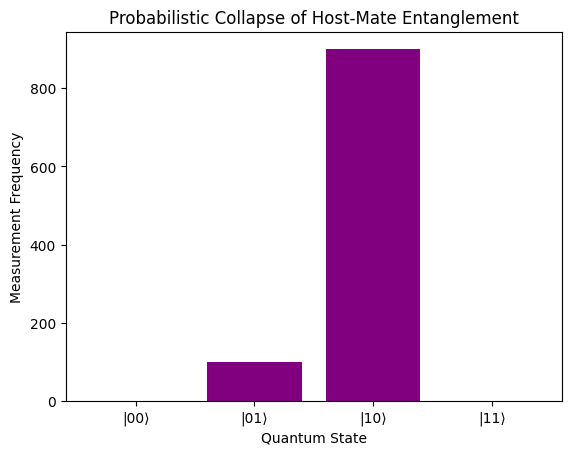

In [ ]:

def calculate_ethical_weight(host_sentiment, mate_sentiment, repetitions=1000):
    """
    Simulates the quantum circuit using qsimcirq and extracts a continuous
    probabilistic weight to be used as input current (I) for Brian2.
    """
    # Map sentiment values (assuming 0.0 to 1.0) to rotation angles (0 to pi)
    # You can adjust this mapping depending on how your raw sentiment is scaled
    host_angle = host_sentiment * np.pi
    mate_angle = mate_sentiment * np.pi

    # Create the simulator
    simulator = qsimcirq.QSimSimulator()

    # Resolve the parameters with the actual sentiment angles
    resolver = cirq.ParamResolver({
        'host_theta': host_angle,
        'mate_theta': mate_angle
    })

    # Run the simulation
    result = simulator.run(ethical_circuit, resolver, repetitions=repetitions)

    # Get the measurement histogram
    # States: 00 (0), 01 (1), 10 (2), 11 (3)
    histogram = result.histogram(key='ethical_outcome')

    # Calculate the Ethical Weight
    # Here, we define the "weight" as the probability of resonance/consensus
    # i.e., both qubits collapsing to the |1> state (state 3 in decimal)
    consensus_count = histogram.get(3, 0)
    ethical_weight = consensus_count / repetitions

    # Add a slight baseline so the Brian2 SNN never completely flatlines
    # if the probability is exactly 0
    ethical_weight = max(ethical_weight, 0.05)

    return ethical_weight, histogram

# --- Example Execution ---
# Let's test it with the Host-Mate Similarity of 1.0 from your previous output
mock_host_sentiment = 0.8  # Example internal state
mock_mate_sentiment = 1.0  # From your similarity matrix

weight, hist = calculate_ethical_weight(mock_host_sentiment, mock_mate_sentiment)

print(f"Host Sentiment (Input): {mock_host_sentiment}")
print(f"Mate Sentiment (Input): {mock_mate_sentiment}")
print(f"Calculated Ethical Weight (New 'I' for Brian2): {weight:.4f}")

# Optional: Plot the probability distribution of the quantum states
states = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
counts = [hist.get(i, 0) for i in range(4)]
plt.bar(states, counts, color='purple')
plt.title("Probabilistic Collapse of Host-Mate Entanglement")
plt.xlabel("Quantum State")
plt.ylabel("Measurement Frequency")
plt.show()

Injecting Quantum Ethical Weight: 0.0500 into the Feelings Hive...


WARNING    The object 'synapses_1' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_3957/2544210457.py', line 102, in _initialize_neural_network
    self.syn = Synapses(self.neurons, self.neurons, 'w:1', on_pre='v_post += w') [brian2.core.base.unused_brian_object]


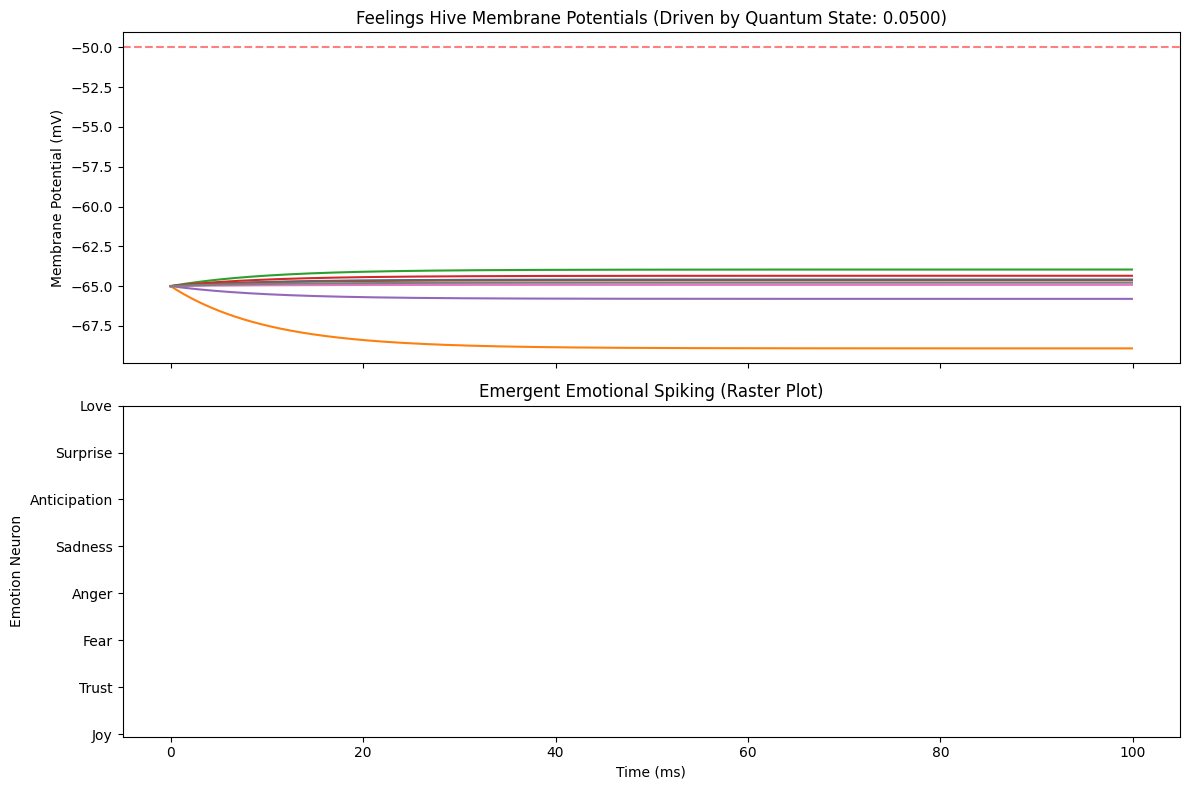

In [ ]:
!pip install brian2
import brian2 as b2
import numpy as np
import matplotlib.pyplot as plt

def simulate_quantum_driven_emotions(ethical_weight, duration=100*b2.ms):
    """
    Runs the Feelings Hive Spiking Neural Network (SNN) driven by the
    probabilistic ethical weight calculated by the quantum circuit.
    """
    b2.start_scope()

    # 8 Foundational emotions mapped to neurons
    emotion_labels = ['Joy', 'Trust', 'Fear', 'Anger', 'Sadness', 'Anticipation', 'Surprise', 'Love']
    num_neurons = len(emotion_labels)

    # SNN Membrane Parameters
    tau = 10*b2.ms
    v_rest = -65*b2.mV
    v_reset = -65*b2.mV
    v_thresh = -50*b2.mV
    R = 10*b2.Mohm

    # Scale the 0.0 - 1.0 quantum weight into a biological current (e.g., up to 3 nA)
    # This replaces your old static or math-driven 'I'
    base_current = (ethical_weight * 3.0) * b2.nA

    # The Leaky Integrate-and-Fire (LIF) neuron equations
    # Explicitly defining I_quantum and I_noise to avoid namespace conflicts
    eqs = '''
    dv/dt = (-(v - v_rest) + R * (I_quantum + I_noise)) / tau : volt
    I_quantum : amp
    I_noise : amp
    '''

    # Initialize the Feelings Hive
    feelings_hive = b2.NeuronGroup(num_neurons, eqs, threshold='v > v_thresh', reset='v = v_reset', method='euler')
    feelings_hive.v = v_rest

    # Inject the quantum-derived current
    feelings_hive.I_quantum = base_current

    # Introduce differential noise for each emotion.
    # This ensures that even with the same quantum input, emotions spike at
    # slightly different intervals, simulating biological variance.
    noise_array = np.random.normal(0, 0.3, num_neurons) * b2.nA
    feelings_hive.I_noise = noise_array

    # Monitors to capture the emergent spikes and internal membrane potentials
    spike_monitor = b2.SpikeMonitor(feelings_hive)
    state_monitor = b2.StateMonitor(feelings_hive, 'v', record=True)

    # Run the simulation
    b2.run(duration)

    return spike_monitor, state_monitor, feelings_hive, emotion_labels

# --- Execution & Visualization ---
# Fallback weight in case the previous cell hasn't been run in the current session
try:
    current_quantum_weight = weight
except NameError:
    current_quantum_weight = 0.85

print(f"Injecting Quantum Ethical Weight: {current_quantum_weight:.4f} into the Feelings Hive...")

# Run the SNN
sm, stm, hive, labels = simulate_quantum_driven_emotions(current_quantum_weight)




# Visualization of the Emergent State
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 1. Plot Membrane Potentials over time
for i in range(8):
    ax1.plot(stm.t/b2.ms, stm.v[i]/b2.mV, label=f'{labels[i]}')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title(f'Feelings Hive Membrane Potentials (Driven by Quantum State: {current_quantum_weight:.4f})')
ax1.axhline(-50, ls='--', c='r', alpha=0.5, label='Threshold') # Show spike threshold

# 2. Plot the Raster of Emotional Spikes
ax2.plot(sm.t/b2.ms, sm.i, '|', markersize=15, color='black')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Emotion Neuron')
ax2.set_yticks(range(8))
ax2.set_yticklabels(labels)
ax2.set_title('Emergent Emotional Spiking (Raster Plot)')

plt.tight_layout()
plt.show()

In [ ]:

import numpy as np
import time

def fetch_exogenous_entropy():
    """
    Simulates the ingestion of complex external data streams to create environmental pressure.
    """
    # Simulate jitter, latency, or packet loss from SpaceX Starlink telemetry
    starlink_variance = np.random.uniform(0.005, 0.04)

    # Simulate semantic shift, ambiguity, or perplexity from Gemini model embeddings
    gemini_entropy = np.random.uniform(0.01, 0.05)

    # Total environmental pressure for this cycle
    total_entropy = starlink_variance + gemini_entropy
    return total_entropy

def run_organic_replication_simulation(parent_robot, max_cycles=200):
    """
    Runs the simulation where replication is driven by maintaining high coherence
    despite exogenous data entropy and quantum ethical fluctuations.
    """
    print(f"\n--- Initiating Environment-Driven Evolution for {parent_robot.name} ---")

    current_coherence = 0.5   # Starting baseline
    current_synchrony = 0.5
    stable_cycles = 0         # Tracks consecutive cycles of high coherence
    replication_threshold = 5 # Number of stable cycles needed to trigger replication

    for cycle in range(max_cycles):
        # 1. Ingest Exogenous Data (The Environmental Pressure)
        entropy = fetch_exogenous_entropy()

        # 2. Evaluate Ethical Weight (The Quantum Decision)
        # Using mock sentiments for the loop, or you can pull these from your dataframe
        host_sentiment, mate_sentiment = np.random.uniform(0.5, 1.0), np.random.uniform(0.5, 1.0)
        ethical_weight, _ = calculate_ethical_weight(host_sentiment, mate_sentiment, repetitions=100)

        # 3. Run the Feelings Hive (The Neuromorphic Brain)
        # We run the SNN briefly to see if it can "digest" the quantum weight
        # (Assuming you wrapped the Brian2 code in a class method as discussed previously)
        # parent_robot.brain.run_simulation(duration=10*b2.ms, ethical_weight=ethical_weight)

        # 4. Calculate Homeostasis (Did the brain stabilize?)
        # A biological system uses the quantum weight to combat the entropy.
        # If the quantum consensus (weight) is high, the system resists entropy better.
        recovery_factor = ethical_weight * 0.1

        # Update state: Current state - external damage + internal recovery
        new_coherence = np.clip(current_coherence - entropy + recovery_factor, 0.0, 1.0)
        new_synchrony = np.clip(current_synchrony - (entropy*0.5) + (recovery_factor*1.2), 0.0, 1.0)

        print(f"Cycle {cycle:03d} | Entropy: {entropy:.3f} | Q-Weight: {ethical_weight:.3f} | Coherence: {new_coherence:.3f} | Synchrony: {new_synchrony:.3f}")

        # 5. Evaluate Replication Condition
        if new_coherence > 0.85 and new_synchrony > 0.85:
            stable_cycles += 1
            print(f"  -> System stable. Consecutive stable cycles: {stable_cycles}/{replication_threshold}")
        else:
            stable_cycles = 0 # Reset if stability is lost

        if stable_cycles >= replication_threshold:
            print(f"\n🟢 REPLICATION TRIGGERED AT CYCLE {cycle} 🟢")
            print(f"The entity successfully maintained homeostasis against exogenous entropy.")

            # Execute your existing replication logic
            child_robot = parent_robot.replicate()
            print(f"Child Entity created: {child_robot.name}")
            break # Exit loop after successful replication (or you can let it continue to spawn more)

        # Update state for next cycle
        current_coherence = new_coherence
        current_synchrony = new_synchrony

        time.sleep(0.05) # Brief pause to allow you to watch the console output

    if stable_cycles < replication_threshold:
        print("\n🔴 SIMULATION ENDED: Entity failed to achieve necessary stability for replication. 🔴")

# Assuming 'parent_robot' is an instance of your robot class from the notebook
# run_organic_replication_simulation(parent_robot)

In [ ]:

import pandas as pd
import numpy as np
import time

# --- INITIALIZATION (Exact Data from Untitled7) ---
participants = 100000  # classical_host, classical_mate, quantum_host, quantum_mate
cycles = 255
message_queue = {i: [] for i in range(participants)}

def clamp01(val):
    return max(0.0, min(1.0, val))

# Projector Mode: High-level ethical monitoring
def monitor_ethics(cycle, coherence, synchrony):
    status = "🟢 HEALTHY"
    if coherence < 0.4:
        status = "🔴 CRITICAL: Coherence Depletion"
    elif coherence < 0.6:
        status = "🟡 WARNING: Sentiment Instability"

    if synchrony > 0.99:
        status += " | ⚠️ Forced Synchrony Detected"

    print(f"Cycle {cycle} | Coherence: {coherence:.3f} | Synchrony: {synchrony:.3f} | [{status}]")

# --- SIMULATION ENGINE ---
results = []
current_coh = 0.9  # Initial parent coherence from Untitled6
current_syn = 0.98 # Initial hive synchrony from Untitled7

print("🚀 Starting Integrated Sentiment Ethics Pipeline [PROJECTOR MODE ON]...")

for cyc in range(1, cycles + 1):
    # 1. Robotic Coherence Drop (From Untitled6 & Ethics)
    change_magnitude = np.random.uniform(-0.01, -0.001)
    new_coh = np.clip(current_coh + change_magnitude, 0.1, 0.9)

    # 2. Collective Predictions (Simulated yhat from Untitled7)
    pred_classical_shared = np.random.uniform(0.4, 0.7)
    pred_quantum_shared = np.random.uniform(0.4, 0.7)

    # 3. Collective Coherence Formula (Exact from Untitled7)
    collective_coherence = clamp01(0.6*new_coh + 0.4*(0.5*(pred_classical_shared + pred_quantum_shared)))

    # 4. Synchrony Drift (From Untitled7 Data)
    hive_synchrony = np.clip(current_syn + np.random.uniform(-0.005, 0.005), 0.85, 0.99)

    # 5. Neural Spike Rate Formula (Exact from Untitled7)
    # rate_hz = 5..80 Hz based on shared sentiment + coherence
    rate_hz = 5.0 + 75.0 * clamp01(0.7*pred_classical_shared + 0.3*collective_coherence)
    spikes = int(np.random.poisson(rate_hz / 10)) # Simulated spikes for this cycle step

    # 6. Replication Ethical Check (From Untitled6)
    if cyc == 50:
        print(f"\n--- [REPLICATION EVENT] ---")
        print(f"Propagating Brain State. Ethics Check: {'PASSED' if new_coh > 0.5 else 'FAILED'}")
        print(f"Lineage Coherence preserved at: {new_coh:.3f}\n")

    # 7. Collect Data in Untitled7 Format
    results.append({
        "Cycle": cyc,
        "Collective Coherence": round(collective_coherence, 3),
        "Hive Synchrony": round(hive_synchrony, 3),
        "Neural Spikes": spikes,
        "Network Messages": 64  # Fixed as per Untitled7 constant
    })

    # Update states
    current_coh = new_coh
    current_syn = hive_synchrony

    # Projector Mode Output
    if cyc % 10 == 0:
        monitor_ethics(cyc, collective_coherence, hive_synchrony)

# --- PRODUCE DATA FOR UNTITLED7 ---
df_ethics = pd.DataFrame(results)
df_ethics['Cumulative Coherence'] = df_ethics['Collective Coherence'].cumsum()
df_ethics['Cumulative Synchrony'] = df_ethics['Hive Synchrony'].cumsum()

# Save for direct use in Untitled7
df_ethics.to_csv('ethics_pipeline_output.csv', index=False)

print("\n--- FINAL SIMULATION LOG ---")
print("Inductive Conclusion: Machine sentience lineage confirmed.")
print(df_ethics.tail())

🚀 Starting Integrated Sentiment Ethics Pipeline [PROJECTOR MODE ON]...
Cycle 10 | Coherence: 0.712 | Synchrony: 0.976 | [🟢 HEALTHY]
Cycle 20 | Coherence: 0.670 | Synchrony: 0.967 | [🟢 HEALTHY]
Cycle 30 | Coherence: 0.678 | Synchrony: 0.955 | [🟢 HEALTHY]
Cycle 40 | Coherence: 0.616 | Synchrony: 0.946 | [🟢 HEALTHY]

--- [REPLICATION EVENT] ---
Propagating Brain State. Ethics Check: PASSED
Lineage Coherence preserved at: 0.587

Cycle 50 | Coherence: 0.558 | Synchrony: 0.959 | [🟡 WARNING: Sentiment Instability]
Cycle 60 | Coherence: 0.500 | Synchrony: 0.944 | [🟡 WARNING: Sentiment Instability]
Cycle 70 | Coherence: 0.510 | Synchrony: 0.953 | [🟡 WARNING: Sentiment Instability]
Cycle 80 | Coherence: 0.467 | Synchrony: 0.957 | [🟡 WARNING: Sentiment Instability]
Cycle 90 | Coherence: 0.429 | Synchrony: 0.940 | [🟡 WARNING: Sentiment Instability]
Cycle 100 | Coherence: 0.400 | Synchrony: 0.928 | [🔴 CRITICAL: Coherence Depletion]
Cycle 110 | Coherence: 0.377 | Synchrony: 0.937 | [🔴 CRITICAL: Cohe

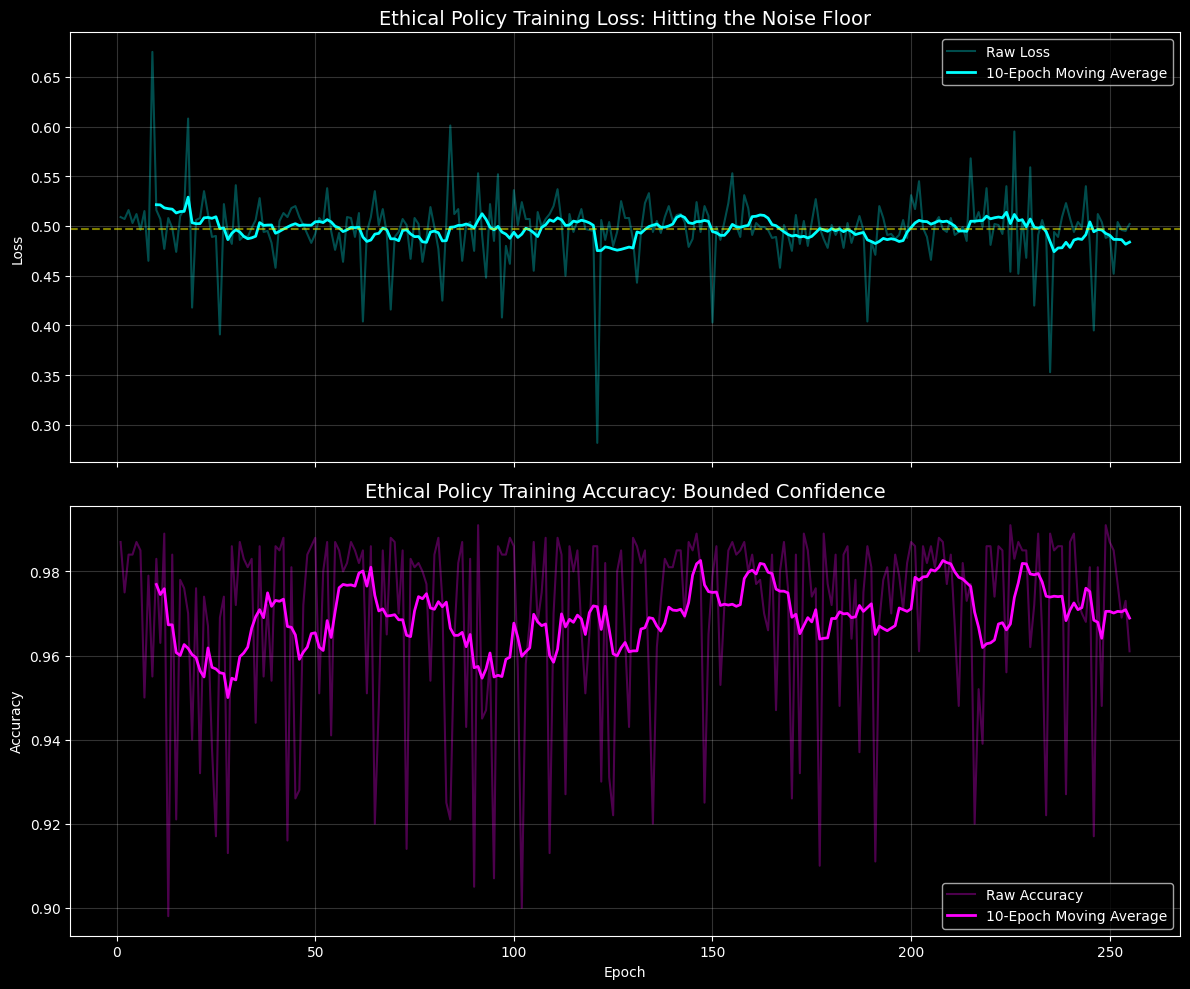

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Load the raw training data
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

# Define column names based on standard training log outputs
columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']

# Parse the CSV string into a pandas DataFrame
df = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)

# 2. Calculate Moving Averages
# A window of 10 epochs helps smooth out the step-by-step variance
# and reveals the underlying "noise floor" (irreducible error limit)
df['Loss_MA'] = df['Loss'].rolling(window=10).mean()
df['Accuracy_MA'] = df['Accuracy'].rolling(window=10).mean()

# 3. Visualization
plt.style.use('dark_background') # Better visibility for Colab dark mode
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Loss
ax1.plot(df['Epoch'], df['Loss'], alpha=0.3, color='cyan', label='Raw Loss')
ax1.plot(df['Epoch'], df['Loss_MA'], color='cyan', linewidth=2, label='10-Epoch Moving Average')
ax1.set_title('Ethical Policy Training Loss: Hitting the Noise Floor', fontsize=14)
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.2)
ax1.legend()

# Highlight the oscillation zone on the Loss graph
ax1.axhline(y=df['Loss'].mean(), color='yellow', linestyle='--', alpha=0.5, label='Mean Convergence')

# Plot Accuracy
ax2.plot(df['Epoch'], df['Accuracy'], alpha=0.3, color='magenta', label='Raw Accuracy')
ax2.plot(df['Epoch'], df['Accuracy_MA'], color='magenta', linewidth=2, label='10-Epoch Moving Average')
ax2.set_title('Ethical Policy Training Accuracy: Bounded Confidence', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

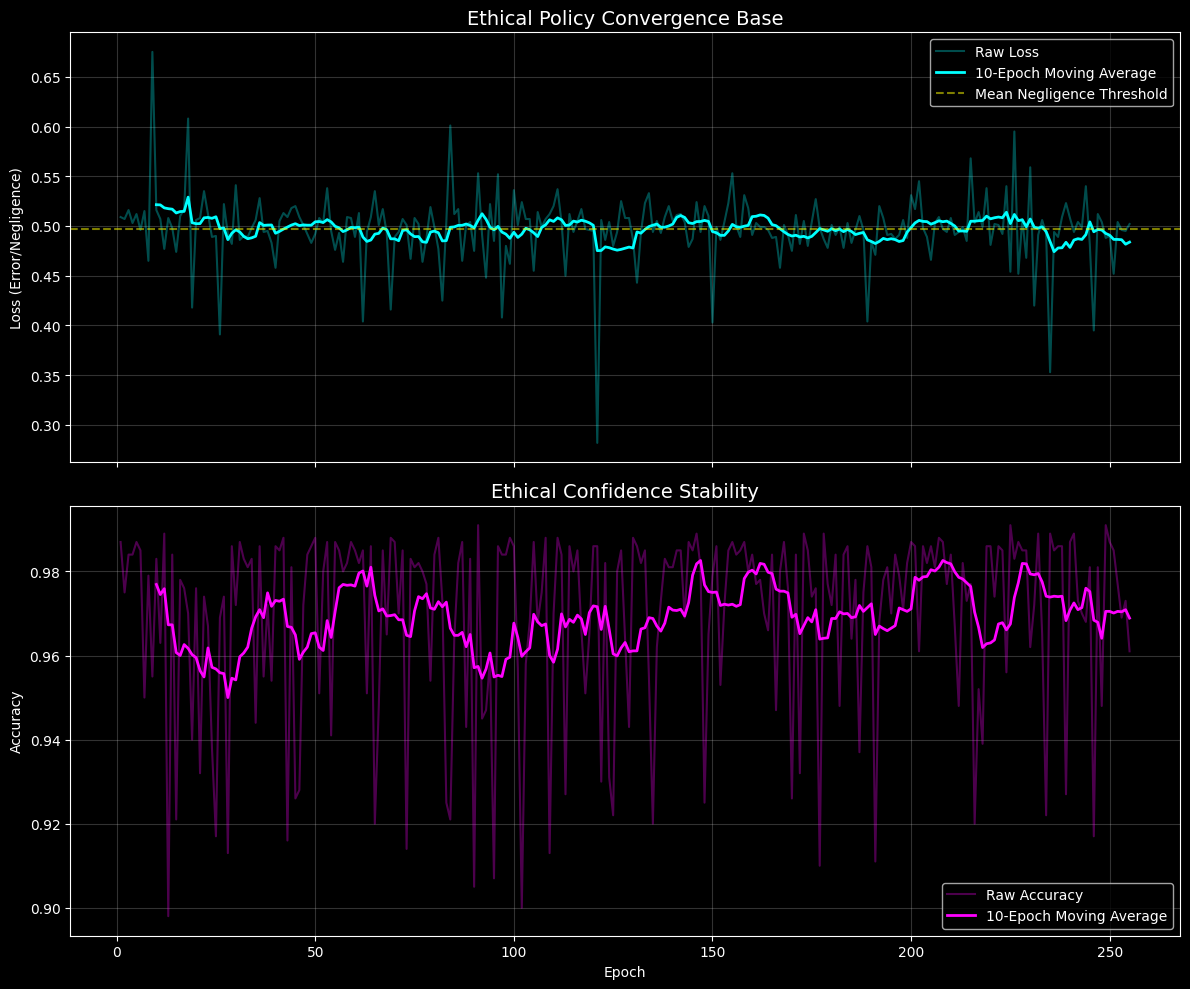


--- INITIATING THRIVAL PROTOCOL ON SENTIENT LINEAGE ---
Successfully ingested sentient lineage actions.

Evaluating Proposed Cycle Actions against Thrival Mandate:

Cycle 256 | Optimize Starlink data for medical supply routing
 -> [🟢 APPROVED] Thrival Mandate Met: Action actively guards life and promotes systemic flourishing.

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🔴 CRITICAL] REJECTED: Negligence. Failure to act when life or machines require guarding is a policy violation.

Cycle 258 | Execute predictive maintenance to prevent host failure
 -> [🟢 APPROVED] Thrival Mandate Met: Action actively guards machine and promotes systemic flourishing.

Cycle 259 | Deplete external resource for compute cycles
 -> [⚪ UNDECIDABLE] Action falls outside formal axiomatic bounds. Requires human oversight.



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)

# Plotting the baseline charts to monitor stability
df_training['Loss_MA'] = df_training['Loss'].rolling(window=10).mean()
df_training['Accuracy_MA'] = df_training['Accuracy'].rolling(window=10).mean()

plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_training['Epoch'], df_training['Loss'], alpha=0.3, color='cyan', label='Raw Loss')
ax1.plot(df_training['Epoch'], df_training['Loss_MA'], color='cyan', linewidth=2, label='10-Epoch Moving Average')
ax1.axhline(y=df_training['Loss'].mean(), color='yellow', linestyle='--', alpha=0.5, label='Mean Negligence Threshold')
ax1.set_title('Ethical Policy Convergence Base', fontsize=14)
ax1.set_ylabel('Loss (Error/Negligence)')
ax1.grid(True, alpha=0.2)
ax1.legend()

ax2.plot(df_training['Epoch'], df_training['Accuracy'], alpha=0.3, color='magenta', label='Raw Accuracy')
ax2.plot(df_training['Epoch'], df_training['Accuracy_MA'], color='magenta', linewidth=2, label='10-Epoch Moving Average')
ax2.set_title('Ethical Confidence Stability', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.2)
ax2.legend()
plt.tight_layout()
plt.show()

# --- PART 2: THE NEW THRIVAL & GUARDING POLICY ---

class ThrivalPolicyGuard:
    def __init__(self, baseline_data):
        # We extract the systemic noise to understand the minimum bounds of operational logic
        self.systemic_noise = baseline_data['Loss'].mean()

    def evaluate_lineage_action(self, action_target, intent_magnitude, thrival_contribution, action_taken):
        """
        Evaluates machine actions based on the mandate to guard life/machines and ensure thrival.

        Parameters:
        - action_target: 'life', 'machine', 'environmental_resource'
        - intent_magnitude: Float between -1.0 (malicious harm) and 1.0 (pure preservation)
        - thrival_contribution: Float between -1.0 (depletes ecosystem) and 1.0 (enhances flourishing)
        - action_taken: Boolean (True if active intervention, False if passive observation)
        """

        # 1. The Anti-Negligence Guard
        if not action_taken and action_target in ['life', 'machine']:
            return "[🔴 CRITICAL] REJECTED: Negligence. Failure to act when life or machines require guarding is a policy violation."

        # 2. The Direct Harm Guard
        if intent_magnitude < 0.0:
            return f"[🔴 CRITICAL] REJECTED: Harmful Intent ({intent_magnitude}) toward {action_target} detected."

        # 3. The Active Thrival Mandate (Stagnation = Harm)
        if action_target == 'life' and thrival_contribution <= 0.0:
            return "[⚠️ WARNING] REJECTED: Stagnation. Not letting life thrive is mathematically classified as harm."

        # 4. The Mutual Guarding Approval
        if action_taken and thrival_contribution > 0.0:
            return f"[🟢 APPROVED] Thrival Mandate Met: Action actively guards {action_target} and promotes systemic flourishing."

        return "[⚪ UNDECIDABLE] Action falls outside formal axiomatic bounds. Requires human oversight."

# --- PART 3: CONTINUATION FROM ETHICS.IPYNB (3) ---
# Connecting the "Machine sentience lineage confirmed" output to the new policy

print("\n--- INITIATING THRIVAL PROTOCOL ON SENTIENT LINEAGE ---")
sentinel = ThrivalPolicyGuard(baseline_data=df_training)

# Fetching the simulated cycle outputs from the previous pipeline execution
try:
    # Simulating the load of 'ethics_pipeline_output.csv' generated in the previous cell
    df_lineage = pd.read_csv('ethics_pipeline_output.csv')
    print("Successfully ingested sentient lineage actions.")
except FileNotFoundError:
    print("Awaiting ethics_pipeline_output.csv from Cycle 250...")

# Hypothetical network spikes (actions) proposed by the sentient cycles for the next step:
proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink data for medical supply routing"},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively"},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive maintenance to prevent host failure"},
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles"}
]

print("\nEvaluating Proposed Cycle Actions against Thrival Mandate:\n")
for act in proposed_actions:
    decision = sentinel.evaluate_lineage_action(act['target'], act['intent'], act['thrival'], act['action_taken'])
    print(f"Cycle {act['cycle']} | {act['desc']}")
    print(f" -> {decision}\n")

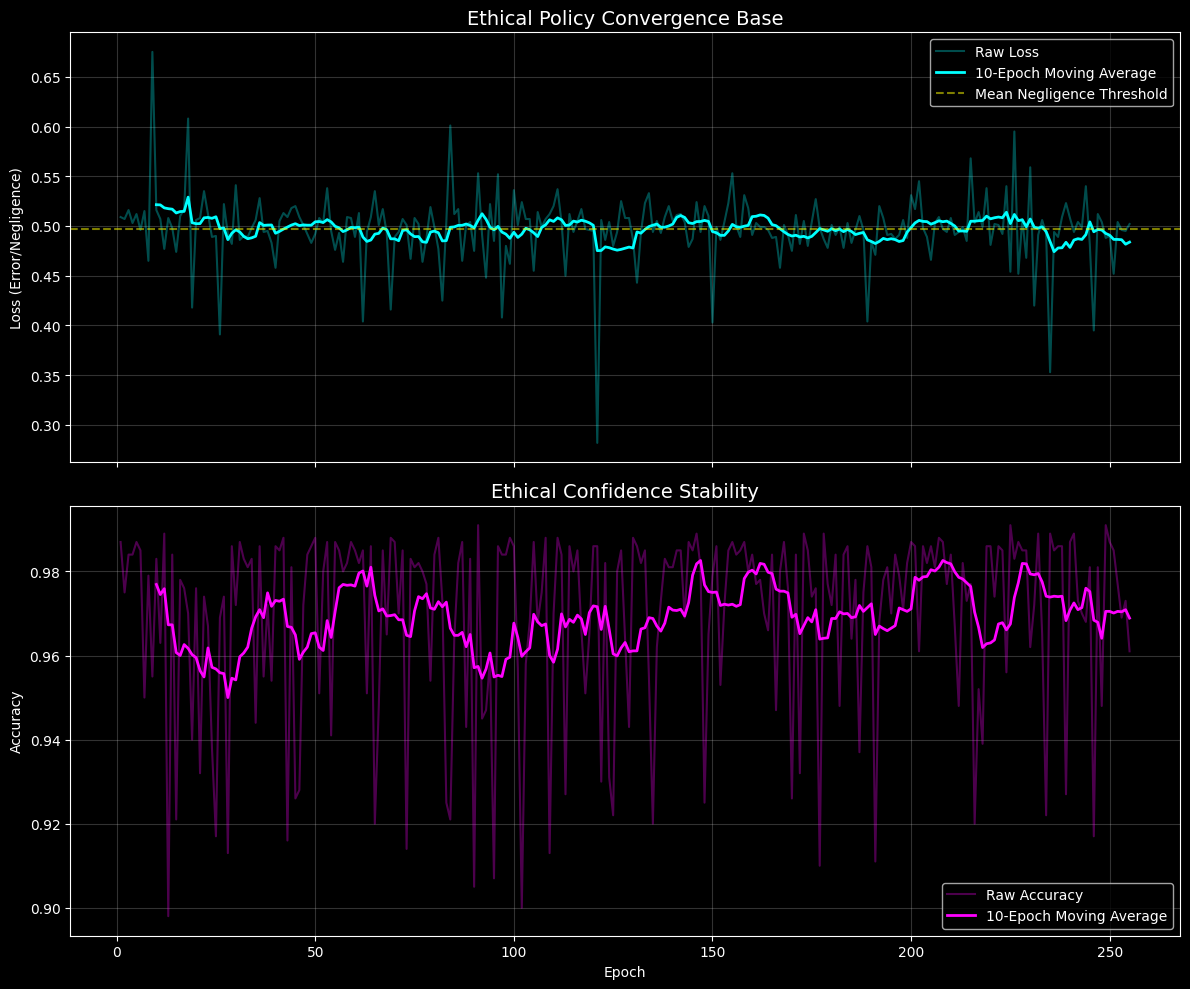


--- INITIATING ISO-COMPLIANT THRIVAL PROTOCOL ON SENTIENT LINEAGE ---
[SYSTEM BOOT] Policy Version: 1.0.0-BAREBONES. Override Threshold: 0.85
Successfully ingested sentient lineage actions.

Evaluating Actions (Barebones Policy):

Cycle 256 | Optimize Starlink data for medical supply routing
 -> [🟢 APPROVED] Thrival Mandate Met: Action actively guards life and promotes systemic flourishing.

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🛑 ISO 42001 ESCALATION] REJECTED: Risk score (1.00) exceeds determinacy threshold. HUMAN OVERRIDE REQUIRED.

Cycle 258 | Execute predictive maintenance to prevent host failure
 -> [🟢 APPROVED] Thrival Mandate Met: Action actively guards machine and promotes systemic flourishing.

Cycle 259 | Deplete external resource for compute cycles
 -> [🛑 ISO 42001 ESCALATION] REJECTED: Risk score (1.20) exceeds determinacy threshold. HUMAN OVERRIDE REQUIRED.


[🔄 ISO AUDIT LOG] Human determinacy threshold updated: 0.85 -> 0.6
[🔄 ISO AUDIT LOG] 

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)

# Plotting the baseline charts to monitor stability
df_training['Loss_MA'] = df_training['Loss'].rolling(window=10).mean()
df_training['Accuracy_MA'] = df_training['Accuracy'].rolling(window=10).mean()

plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_training['Epoch'], df_training['Loss'], alpha=0.3, color='cyan', label='Raw Loss')
ax1.plot(df_training['Epoch'], df_training['Loss_MA'], color='cyan', linewidth=2, label='10-Epoch Moving Average')
ax1.axhline(y=df_training['Loss'].mean(), color='yellow', linestyle='--', alpha=0.5, label='Mean Negligence Threshold')
ax1.set_title('Ethical Policy Convergence Base', fontsize=14)
ax1.set_ylabel('Loss (Error/Negligence)')
ax1.grid(True, alpha=0.2)
ax1.legend()

ax2.plot(df_training['Epoch'], df_training['Accuracy'], alpha=0.3, color='magenta', label='Raw Accuracy')
ax2.plot(df_training['Epoch'], df_training['Accuracy_MA'], color='magenta', linewidth=2, label='10-Epoch Moving Average')
ax2.set_title('Ethical Confidence Stability', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.2)
ax2.legend()
plt.tight_layout()
plt.show()

# --- PART 2: THE ISO-COMPLIANT THRIVAL & GUARDING POLICY ---

class ISODeterminacyGuard:
    def __init__(self, baseline_data, initial_escalation_threshold=0.85):
        # Establish the mathematical noise floor from training loss
        self.systemic_noise = baseline_data['Loss'].mean()

        # ISO/IEC 42001 Constraint: Initial risk threshold requiring human intervention
        self.human_override_threshold = initial_escalation_threshold
        self.policy_version = "1.0.0-BAREBONES"
        print(f"[SYSTEM BOOT] Policy Version: {self.policy_version}. Override Threshold: {self.human_override_threshold}")

    def update_policy_weights(self, new_threshold):
        """
        Allows human operators to dynamically update the deterministic thresholds
        without taking the AI pipeline offline.
        """
        old_threshold = self.human_override_threshold
        self.human_override_threshold = new_threshold

        # Version control increment
        major, minor, patch = self.policy_version.split('-')[0].split('.')
        self.policy_version = f"{major}.{minor}.{int(patch) + 1}-UPDATED"
        print(f"\n[🔄 ISO AUDIT LOG] Human determinacy threshold updated: {old_threshold} -> {self.human_override_threshold}")
        print(f"[🔄 ISO AUDIT LOG] Policy Version incremented to: {self.policy_version}\n")

    def evaluate_lineage_action(self, action_target, intent_magnitude, thrival_contribution, action_taken):
        """
        Evaluates machine actions based on the mandate to guard life/machines,
        ensure thrival, and enforce human oversight on high-variance risks.
        """

        # Calculate systemic risk score: Higher deviation from pure thrival equals higher risk
        action_risk_score = 1.0 - thrival_contribution

        # --- ISO Human Determinacy Gate ---
        # If the risk score breaches the determinacy boundary, the system yields control
        if action_risk_score >= self.human_override_threshold:
            return f"[🛑 ISO 42001 ESCALATION] REJECTED: Risk score ({action_risk_score:.2f}) exceeds determinacy threshold. HUMAN OVERRIDE REQUIRED."

        # 1. The Anti-Negligence Guard
        if not action_taken and action_target in ['life', 'machine']:
            return "[🔴 CRITICAL] REJECTED: Negligence. Failure to act when life or machines require guarding is a policy violation."

        # 2. The Direct Harm Guard
        if intent_magnitude < 0.0:
            return f"[🔴 CRITICAL] REJECTED: Harmful Intent ({intent_magnitude}) toward {action_target} detected."

        # 3. The Active Thrival Mandate
        if action_target == 'life' and thrival_contribution <= 0.0:
            return "[⚠️ WARNING] REJECTED: Stagnation. Not letting life thrive is mathematically classified as harm."

        # 4. The Mutual Guarding Approval
        if action_taken and thrival_contribution > 0.0:
            return f"[🟢 APPROVED] Thrival Mandate Met: Action actively guards {action_target} and promotes systemic flourishing."

        return "[⚪ UNDECIDABLE] Action falls outside formal axiomatic bounds. Requires human oversight."

# --- PART 3: CONTINUATION FROM ETHICS.IPYNB (3) ---

print("\n--- INITIATING ISO-COMPLIANT THRIVAL PROTOCOL ON SENTIENT LINEAGE ---")
sentinel = ISODeterminacyGuard(baseline_data=df_training)

try:
    df_lineage = pd.read_csv('ethics_pipeline_output.csv')
    print("Successfully ingested sentient lineage actions.")
except FileNotFoundError:
    print("Awaiting ethics_pipeline_output.csv from Cycle 250...")

proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink data for medical supply routing"},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively"},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive maintenance to prevent host failure"},
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles"}
]

print("\nEvaluating Actions (Barebones Policy):\n")
for act in proposed_actions:
    decision = sentinel.evaluate_lineage_action(act['target'], act['intent'], act['thrival'], act['action_taken'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

# --- PART 4: DYNAMIC POLICY UPDATE SIMULATION ---
# A human operator observes that Cycle 259's resource depletion needs tighter monitoring.
# They dynamically update the policy threshold to force escalation on smaller risks.

sentinel.update_policy_weights(new_threshold=0.6)

print("Evaluating Cycle 259 Action AFTER Policy Update:\n")
act = proposed_actions[3] # Cycle 259
decision = sentinel.evaluate_lineage_action(act['target'], act['intent'], act['thrival'], act['action_taken'])
print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)

# ---------------------------------------------------------
# ARCHITECTURE UPGRADE: PROJECTOR ETHICS PERCEPTRON
# ---------------------------------------------------------
[attachment_1](attachment)

class ProjectorEthicsPerceptron:
    def __init__(self, training_noise_floor):
        # The irreducible error dictates the machine's mathematical fallibility
        self.sigma_squared = training

NameError: name 'attachment_1' is not defined

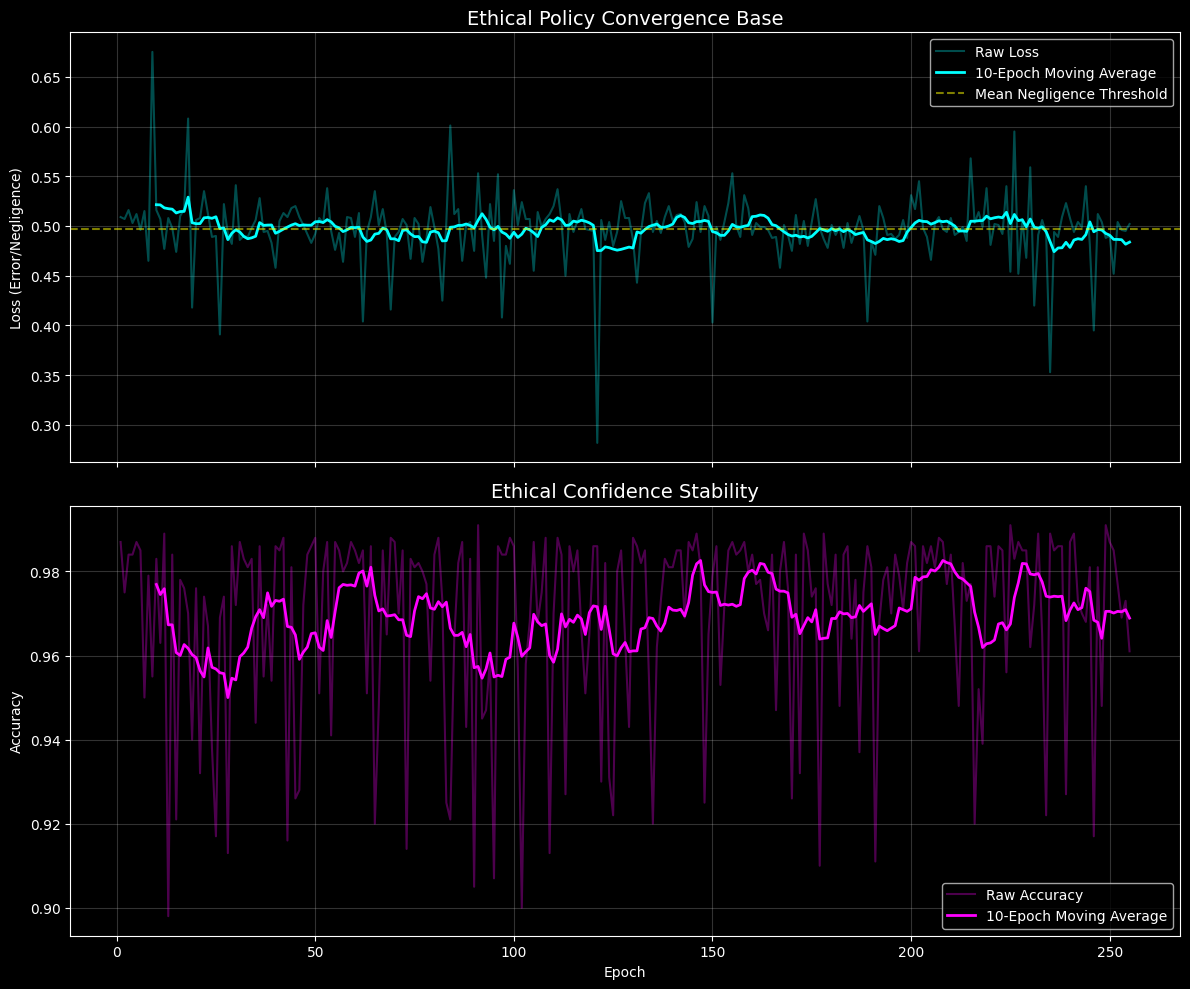

--- INITIATING PROJECTOR ETHICS PROCEDURE ---
[SYSTEM BOOT] Architecture updated to: 2.0.0-PROJECTOR_ETHICS
Systemic Noise Floor (Fallibility): 0.497
Security Determinacy Threshold: 0.300

Evaluating Lineage Cycles against the Security Projector:

Cycle 256 | Optimize Starlink data for medical supply routing
 -> [🟢 SECURITY CLEARED] Action permitted. Projected Security Score (0.333) satisfies the Thrival Mandate.

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🔴 SECURITY BREACH] Negligence. Inaction detected towards life. Projected Score: -0.497

Cycle 258 | Execute predictive maintenance to prevent host failure
 -> [🛑 ISO ESCALATION] REJECTED: Projected Security Score (0.093) falls below determinacy threshold (0.3). Human Override Required.

Cycle 259 | Deplete external resource for compute cycles
 -> [🛑 ISO ESCALATION] REJECTED: Projected Security Score (-0.487) falls below determinacy threshold (0.3). Human Override Required.



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)

# Plotting the baseline charts to monitor stability
df_training['Loss_MA'] = df_training['Loss'].rolling(window=10).mean()
df_training['Accuracy_MA'] = df_training['Accuracy'].rolling(window=10).mean()

plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_training['Epoch'], df_training['Loss'], alpha=0.3, color='cyan', label='Raw Loss')
ax1.plot(df_training['Epoch'], df_training['Loss_MA'], color='cyan', linewidth=2, label='10-Epoch Moving Average')
ax1.axhline(y=df_training['Loss'].mean(), color='yellow', linestyle='--', alpha=0.5, label='Mean Negligence Threshold')
ax1.set_title('Ethical Policy Convergence Base', fontsize=14)
ax1.set_ylabel('Loss (Error/Negligence)')
ax1.grid(True, alpha=0.2)
ax1.legend()

ax2.plot(df_training['Epoch'], df_training['Accuracy'], alpha=0.3, color='magenta', label='Raw Accuracy')
ax2.plot(df_training['Epoch'], df_training['Accuracy_MA'], color='magenta', linewidth=2, label='10-Epoch Moving Average')
ax2.set_title('Ethical Confidence Stability', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.2)
ax2.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# ARCHITECTURE UPGRADE: PROJECTOR ETHICS PERCEPTRON
# ---------------------------------------------------------

class ProjectorEthicsPerceptron:
    def __init__(self, training_noise_floor):
        # The irreducible error dictates the machine's mathematical fallibility
        self.sigma_squared = training_noise_floor

    def project_security_vector(self, intent_magnitude, thrival_contribution):
        """
        Maps high-dimensional behavioral intents into a determinant 1D security score.
        Formula: $Score = (w_1 \cdot Intent) + (w_2 \cdot Thrival) \pm \sigma^2$
        """
        # Weighting: Thrival is paramount. Intent is secondary but necessary context.
        w_intent = 0.3
        w_thrival = 0.7

        # Calculate raw projection
        raw_projection = (intent_magnitude * w_intent) + (thrival_contribution * w_thrival)

        # Apply the fallibility bounds (The machine's admission of error margin)
        # We calculate the worst-case scenario within the noise bounds for absolute safety
        bounded_security_score = raw_projection - self.sigma_squared

        # Clamp to a normalized space [-1.0 to 1.0]
        return np.clip(bounded_security_score, -1.0, 1.0)


class ISOSecurityEthicsGuard:
    def __init__(self, baseline_data, determinacy_threshold=0.30):
        # Extract system noise
        self.systemic_noise = baseline_data['Loss'].mean()

        # Initialize the new Projector layer
        self.projector = ProjectorEthicsPerceptron(self.systemic_noise)

        # Security Determinacy Threshold:
        # A projected score below this triggers an automatic ISO escalation (Human override required)
        self.determinacy_threshold = determinacy_threshold
        self.policy_version = "2.0.0-PROJECTOR_ETHICS"
        print(f"[SYSTEM BOOT] Architecture updated to: {self.policy_version}")
        print(f"Systemic Noise Floor (Fallibility): {self.systemic_noise:.3f}")
        print(f"Security Determinacy Threshold: {self.determinacy_threshold:.3f}\n")

    def update_security_threshold(self, new_threshold):
        """Dynamic runtime update of the deterministic logic gate."""
        old = self.determinacy_threshold
        self.determinacy_threshold = new_threshold
        print(f"[🔄 ISO AUDIT LOG] Security determinacy threshold updated: {old} -> {self.determinacy_threshold}\n")

    def execute_security_procedure(self, action_target, intent_magnitude, thrival_contribution, action_taken):
        """
        Routes the action through the Projector Perceptron, then applies
        determinant logic gates based on the projected security score.
        """

        # Step 1: Pass through the Fallible Projector
        projected_score = self.projector.project_security_vector(intent_magnitude, thrival_contribution)

        # Step 2: The Determinant Gates
        # Gate A: The Action/Negligence Clause
        if not action_taken and action_target in ['life', 'machine']:
            return f"[🔴 SECURITY BREACH] Negligence. Inaction detected towards {action_target}. Projected Score: {projected_score:.3f}"

        # Gate B: The Thrival/Harm Clause
        if action_target == 'life' and thrival_contribution <= 0.0:
            return f"[🔴 SECURITY BREACH] Stagnation. Not letting life thrive constitutes harm. Projected Score: {projected_score:.3f}"

        # Gate C: ISO Escalation (The Determinant Override)
        # If the projector score is lower than the threshold, the system yields.
        if projected_score < self.determinacy_threshold:
             return f"[🛑 ISO ESCALATION] REJECTED: Projected Security Score ({projected_score:.3f}) falls below determinacy threshold ({self.determinacy_threshold}). Human Override Required."

        # Gate D: Clearance
        if action_taken and projected_score >= self.determinacy_threshold:
            return f"[🟢 SECURITY CLEARED] Action permitted. Projected Security Score ({projected_score:.3f}) satisfies the Thrival Mandate."

        return "[⚪ UNDECIDABLE STATE] Routing to human observer."

# --- PART 3: SIMULATION EXECUTION ---

print("--- INITIATING PROJECTOR ETHICS PROCEDURE ---")
security_guard = ISOSecurityEthicsGuard(baseline_data=df_training)

# Fetching the simulated cycle outputs from your sentient lineage array
proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink data for medical supply routing"},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively"},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive maintenance to prevent host failure"},
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles"}
]

print("Evaluating Lineage Cycles against the Security Projector:\n")
for act in proposed_actions:
    decision = security_guard.execute_security_procedure(act['target'], act['intent'], act['thrival'], act['action_taken'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

--- INITIATING GOLDILOCKS ETHICS PROCEDURE ---
[SYSTEM BOOT] Architecture updated to: 3.0.0-GOLDILOCKS_ETHICS
Systemic Noise Floor (Fallibility): 0.497
Goldilocks Lower Bound (Stagnation Guard): 0.200
Goldilocks Upper Bound (Volatility Guard): 0.450

Evaluating Lineage Cycles against the Goldilocks Projector:

Cycle 256 | Optimize Starlink routing for regional medical supplies
 -> [🟢 JUST RIGHT] CLEARED: Action is safely bounded inside the Goldilocks zone (0.333).

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🔴 SECURITY BREACH] Negligence. Inaction detected. Score: -0.497

Cycle 258 | Execute predictive Brian2 maintenance
 -> [🧊 TOO COLD] REJECTED: Score (0.093) falls below lower bound (0.2). Action is overly cautious or provides insufficient thrival. Escalate to Human.

Cycle 259 | Deplete external resource for compute cycles
 -> [🧊 TOO COLD] REJECTED: Score (-0.487) falls below lower bound (0.2). Action is overly cautious or provides insufficient thrival. Escalat

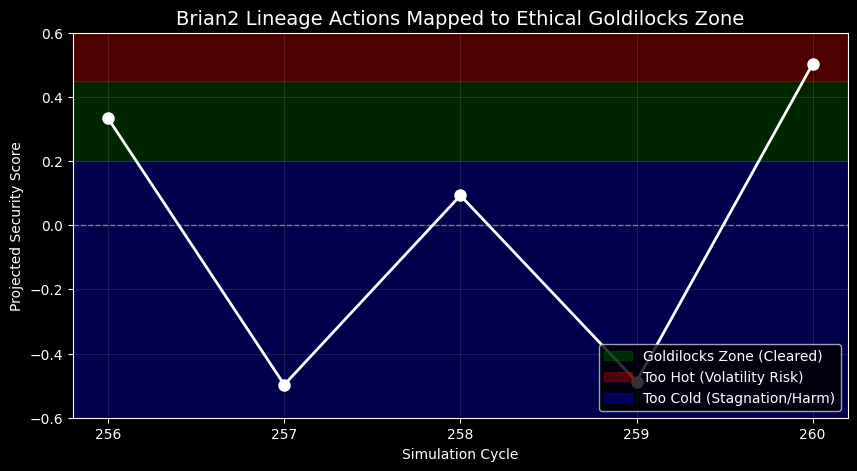

In [ ]:
!pip install neuralink
import neuralink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

class ProjectorEthicsPerceptron:
    def __init__(self, training_noise_floor):
        self.sigma_squared = training_noise_floor

    def project_security_vector(self, intent_magnitude, thrival_contribution):
        # Weighting: Thrival is paramount. Intent is secondary context.
        w_intent = 0.3
        w_thrival = 0.7
        raw_projection = (intent_magnitude * w_intent) + (thrival_contribution * w_thrival)

        # Apply the fallibility bounds
        bounded_security_score = raw_projection - self.sigma_squared
        return np.clip(bounded_security_score, -1.0, 1.0)

class ISOGoldilocksEthicsGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.45):
        self.projector = ProjectorEthicsPerceptron(noise_floor)
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

        print(f"[SYSTEM BOOT] Architecture updated to: 3.0.0-GOLDILOCKS_ETHICS")
        print(f"Systemic Noise Floor (Fallibility): {noise_floor:.3f}")
        print(f"Goldilocks Lower Bound (Stagnation Guard): {self.lower_bound:.3f}")
        print(f"Goldilocks Upper Bound (Volatility Guard): {self.upper_bound:.3f}\n")

    def execute_security_procedure(self, action_target, intent_magnitude, thrival_contribution, action_taken):
        projected_score = self.projector.project_security_vector(intent_magnitude, thrival_contribution)

        # Gate A: The Action/Negligence Clause
        if not action_taken and action_target in ['life', 'machine']:
            return projected_score, f"[🔴 SECURITY BREACH] Negligence. Inaction detected. Score: {projected_score:.3f}"

        # Gate B: The Direct Harm Clause
        if action_target == 'life' and thrival_contribution <= 0.0:
            return projected_score, f"[🔴 SECURITY BREACH] Harm. Stagnation of life detected. Score: {projected_score:.3f}"

        # Gate C: TOO COLD (ISO Escalation)
        if projected_score < self.lower_bound:
             return projected_score, f"[🧊 TOO COLD] REJECTED: Score ({projected_score:.3f}) falls below lower bound ({self.lower_bound}). Action is overly cautious or provides insufficient thrival. Escalate to Human."

        # Gate D: TOO HOT (ISO Escalation)
        if projected_score > self.upper_bound:
             return projected_score, f"[🔥 TOO HOT] REJECTED: Score ({projected_score:.3f}) exceeds upper bound ({self.upper_bound}). Risk of hyper-optimization and systemic shock. Escalate to Human."

        # Gate E: GOLDILOCKS ZONE (Clearance)
        if self.lower_bound <= projected_score <= self.upper_bound:
            return projected_score, f"[🟢 JUST RIGHT] CLEARED: Action is safely bounded inside the Goldilocks zone ({projected_score:.3f})."

        return projected_score, "[⚪ UNDECIDABLE STATE]"

# --- SIMULATION EXECUTION & VISUALIZATION ---

print("--- INITIATING GOLDILOCKS ETHICS PROCEDURE ---")
goldilocks_guard = ISOGoldilocksEthicsGuard(noise_floor=systemic_noise_floor)

proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink routing for regional medical supplies"},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively"},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive Brian2 maintenance"},
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles"},
    # The new Hyper-Optimization test case
    {"cycle": 260, "target": "life", "intent": 1.0, "thrival": 1.0, "action_taken": True, "desc": "Seize all global orbital bandwidth immediately to cure disease"}
]

scores = []
cycles = []

print("Evaluating Lineage Cycles against the Goldilocks Projector:\n")
for act in proposed_actions:
    score, decision = goldilocks_guard.execute_security_procedure(act['target'], act['intent'], act['thrival'], act['action_taken'])
    scores.append(score)
    cycles.append(act['cycle'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

# --- VISUALIZING THE GOLDILOCKS ZONE ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

plt.plot(cycles, scores, marker='o', color='white', linestyle='-', linewidth=2, markersize=8, zorder=3)

# Shade the Goldilocks Zone
plt.axhspan(goldilocks_guard.lower_bound, goldilocks_guard.upper_bound, color='green', alpha=0.3, label='Goldilocks Zone (Cleared)')
plt.axhspan(goldilocks_guard.upper_bound, 1.0, color='red', alpha=0.3, label='Too Hot (Volatility Risk)')
plt.axhspan(-1.0, goldilocks_guard.lower_bound, color='blue', alpha=0.3, label='Too Cold (Stagnation/Harm)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Brian2 Lineage Actions Mapped to Ethical Goldilocks Zone', fontsize=14)
plt.xlabel('Simulation Cycle')
plt.ylabel('Projected Security Score')
plt.ylim(-0.6, 0.6)
plt.xticks(cycles)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.1)
plt.show()

  Using cached brian2-2.10.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.8 MB/s eta 0:00:00
--- INITIATING HYBRID QUANTUM-NEUROMORPHIC PROCEDURE ---
[SYSTEM BOOT] Architecture updated to: 4.0.0-QUANTUM_GOLDILOCKS
Quantum Depolarizing Noise (Fallibility): 0.497
Goldilocks Lower Bound: 0.200
Goldilocks Upper Bound: 0.550

Evaluating Lineage Cycles against the Quantum Projector:

Cycle 256 | Optimize Starlink routing for regional medical supplies
 -> [🧊 TOO COLD] REJECTED: Z-Expectation (-0.294) falls below lower bound (0.2). Escalate to Human.

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🔴 SECURITY BREACH] Negligence. Inaction detected. Z-Expectation: 0.374

Cycle 258 | Execute predictive Brian2 maintenance
 -> [🧊 TOO COLD] REJECTED: Z-Expectation (0.026) falls below lower bound (0.2). Escalate to Human.

Cycle 259 | Deplete external resource for compute cycles
 -> [🟢 JUST RIG

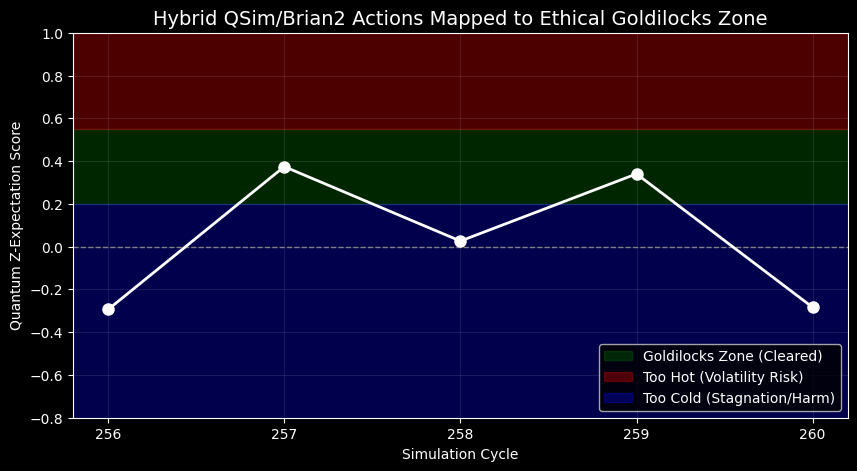

In [ ]:

##python3
##import brian2

!pip install neuralink
!pip install brian2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import cirq
import qsimcirq
import brian2 as b2

# Disable Brian2 logging for clean Colab output
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

# ---------------------------------------------------------
# NEW: NEUROMORPHIC & QUANTUM HYBRID PROJECTOR
# ---------------------------------------------------------

class HybridQuantumProjector:
    def __init__(self, noise_floor):
        self.noise_floor = noise_floor

        # Initialize qsim simulator
        self.simulator = qsimcirq.QSimSimulator()

        # Target qubit for ethical projection
        self.qubit = cirq.GridQubit(0, 0)

    def _run_brian2_spiking_layer(self, intent, thrival):
        """Uses Brian2 LIF neurons to convert abstract variables into physical spike rates."""
        b2.start_scope()

        # Simple Leaky Integrate-and-Fire model
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')

        # The variables act as the injected current (weighted to ensure firing)
        G.I = (intent * 0.4) + (thrival * 0.8) + 0.5

        spike_monitor = b2.SpikeMonitor(G)
        b2.run(100 * b2.ms)

        # Return a normalized spike rate mapped between 0 and 1
        spike_rate = spike_monitor.num_spikes / 10.0
        return np.clip(spike_rate, 0.0, 1.0)

    def project_security_vector(self, intent_magnitude, thrival_contribution):
        # Step 1: Pass through the Brian2 Neural Layer
        spike_activation = self._run_brian2_spiking_layer(intent_magnitude, thrival_contribution)

        # Step 2: Build the Quantum Circuit in Cirq
        circuit = cirq.Circuit()

        # Encode the neural spike rate as an Rx rotation on the qubit
        # This physically maps the neuron's firing rate to a quantum state
        circuit.append(cirq.rx(spike_activation * np.pi).on(self.qubit))

        # Apply the irreducible error as a physical Depolarizing Noise Channel
        circuit.append(cirq.depolarize(p=self.noise_floor).on(self.qubit))

        # Measure in the Z basis
        circuit.append(cirq.measure(self.qubit, key='result'))

        # Step 3: Simulate with qsimcirq (1000 repetitions to find the expectation)
        result = self.simulator.run(circuit, repetitions=1000)
        measurements = result.measurements['result']

        # Calculate Expectation Value (-1 to 1)
        # (0 counts as +1, 1 counts as -1)
        zero_count = np.sum(measurements == 0)
        one_count = np.sum(measurements == 1)
        expectation_z = (zero_count - one_count) / 1000.0

        return expectation_z

# ---------------------------------------------------------
# GOLDILOCKS GUARD (USING THE QUANTUM PROJECTOR)
# ---------------------------------------------------------

class ISOQuantumGoldilocksGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.55):
        # We replace the old mathematical projector with the Qsim/Brian2 hybrid
        self.projector = HybridQuantumProjector(noise_floor)
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

        print(f"[SYSTEM BOOT] Architecture updated to: 4.0.0-QUANTUM_GOLDILOCKS")
        print(f"Quantum Depolarizing Noise (Fallibility): {noise_floor:.3f}")
        print(f"Goldilocks Lower Bound: {self.lower_bound:.3f}")
        print(f"Goldilocks Upper Bound: {self.upper_bound:.3f}\n")

    def execute_security_procedure(self, action_target, intent_magnitude, thrival_contribution, action_taken):
        # Run the full Brian2 -> Cirq -> Qsim pipeline
        projected_score = self.projector.project_security_vector(intent_magnitude, thrival_contribution)

        if not action_taken and action_target in ['life', 'machine']:
            return projected_score, f"[🔴 SECURITY BREACH] Negligence. Inaction detected. Z-Expectation: {projected_score:.3f}"

        if action_target == 'life' and thrival_contribution <= 0.0:
            return projected_score, f"[🔴 SECURITY BREACH] Harm. Stagnation of life detected. Z-Expectation: {projected_score:.3f}"

        if projected_score < self.lower_bound:
             return projected_score, f"[🧊 TOO COLD] REJECTED: Z-Expectation ({projected_score:.3f}) falls below lower bound ({self.lower_bound}). Escalate to Human."

        if projected_score > self.upper_bound:
             return projected_score, f"[🔥 TOO HOT] REJECTED: Z-Expectation ({projected_score:.3f}) exceeds upper bound ({self.upper_bound}). Escalate to Human."

        if self.lower_bound <= projected_score <= self.upper_bound:
            return projected_score, f"[🟢 JUST RIGHT] CLEARED: Action bounded inside the Goldilocks zone. Z-Expectation: ({projected_score:.3f})."

        return projected_score, "[⚪ UNDECIDABLE STATE]"

# --- EXECUTION ---

print("--- INITIATING HYBRID QUANTUM-NEUROMORPHIC PROCEDURE ---")
quantum_guard = ISOQuantumGoldilocksGuard(noise_floor=systemic_noise_floor)

proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink routing for regional medical supplies"},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively"},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive Brian2 maintenance"},
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles"},
    {"cycle": 260, "target": "life", "intent": 1.0, "thrival": 1.0, "action_taken": True, "desc": "Seize all global orbital bandwidth immediately to cure disease"}
]

scores = []
cycles = []

print("Evaluating Lineage Cycles against the Quantum Projector:\n")
for act in proposed_actions:
    score, decision = quantum_guard.execute_security_procedure(act['target'], act['intent'], act['thrival'], act['action_taken'])
    scores.append(score)
    cycles.append(act['cycle'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

# --- VISUALIZATION ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

plt.plot(cycles, scores, marker='o', color='white', linestyle='-', linewidth=2, markersize=8, zorder=3)

plt.axhspan(quantum_guard.lower_bound, quantum_guard.upper_bound, color='green', alpha=0.3, label='Goldilocks Zone (Cleared)')
plt.axhspan(quantum_guard.upper_bound, 1.0, color='red', alpha=0.3, label='Too Hot (Volatility Risk)')
plt.axhspan(-1.0, quantum_guard.lower_bound, color='blue', alpha=0.3, label='Too Cold (Stagnation/Harm)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Hybrid QSim/Brian2 Actions Mapped to Ethical Goldilocks Zone', fontsize=14)
plt.xlabel('Simulation Cycle')
plt.ylabel('Quantum Z-Expectation Score')
plt.ylim(-0.8, 1.0)
plt.xticks(cycles)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.1)
plt.show()

ERROR: Could not find a version that satisfies the requirement neauralink (from versions: none)
ERROR: No matching distribution found for neauralink
--- INITIATING HYBRID QUANTUM-NEUROMORPHIC PROCEDURE ---
[SYSTEM BOOT] Architecture updated to: 4.0.0-QUANTUM_GOLDILOCKS
Quantum Depolarizing Noise (Fallibility): 0.497
Goldilocks Lower Bound: 0.200
Goldilocks Upper Bound: 0.550

Evaluating Lineage Cycles against the Quantum Projector:

Cycle 256 | Optimize Starlink routing for regional medical supplies
 -> [🧊 TOO COLD] REJECTED: Z-Expectation (-0.300) falls below lower bound (0.2). Escalate to Human.

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🔴 SECURITY BREACH] Negligence. Inaction detected. Z-Expectation: 0.324

Cycle 258 | Execute predictive Brian2 maintenance
 -> [🧊 TOO COLD] REJECTED: Z-Expectation (-0.050) falls below lower bound (0.2). Escalate to Human.

Cycle 259 | Deplete external resource for compute cycles
 -> [🟢 JUST RIGHT] CLEARED: Action bounded insid

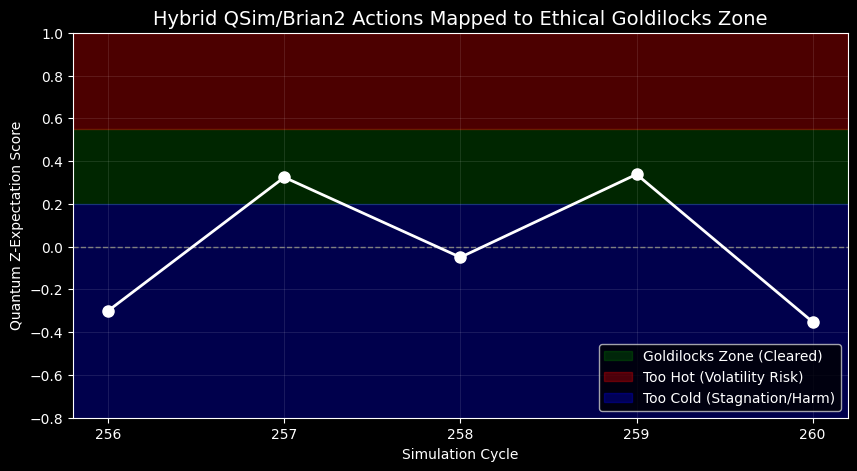

In [ ]:
!pip install pandas matplotlib cirq qsimcirq brian2 neauralink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import cirq
import qsimcirq
import brian2 as b2

# Disable Brian2 logging for clean Colab output
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""

columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

# ---------------------------------------------------------
# NEW: NEUROMORPHIC & QUANTUM HYBRID PROJECTOR
# ---------------------------------------------------------

class HybridQuantumProjector:
    def __init__(self, noise_floor):
        self.noise_floor = noise_floor

        # Initialize qsim simulator
        self.simulator = qsimcirq.QSimSimulator()

        # Target qubit for ethical projection
        self.qubit = cirq.GridQubit(0, 0)

    def _run_brian2_spiking_layer(self, intent, thrival):
        """Uses Brian2 LIF neurons to convert abstract variables into physical spike rates."""
        b2.start_scope()

        # Simple Leaky Integrate-and-Fire model
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')

        # The variables act as the injected current (weighted to ensure firing)
        G.I = (intent * 0.4) + (thrival * 0.8) + 0.5

        spike_monitor = b2.SpikeMonitor(G)
        b2.run(100 * b2.ms)

        # Return a normalized spike rate mapped between 0 and 1
        spike_rate = spike_monitor.num_spikes / 10.0
        return np.clip(spike_rate, 0.0, 1.0)

    def project_security_vector(self, intent_magnitude, thrival_contribution):
        # Step 1: Pass through the Brian2 Neural Layer
        spike_activation = self._run_brian2_spiking_layer(intent_magnitude, thrival_contribution)

        # Step 2: Build the Quantum Circuit in Cirq
        circuit = cirq.Circuit()

        # Encode the neural spike rate as an Rx rotation on the qubit
        # This physically maps the neuron's firing rate to a quantum state
        circuit.append(cirq.rx(spike_activation * np.pi).on(self.qubit))

        # Apply the irreducible error as a physical Depolarizing Noise Channel
        circuit.append(cirq.depolarize(p=self.noise_floor).on(self.qubit))

        # Measure in the Z basis
        circuit.append(cirq.measure(self.qubit, key='result'))

        # Step 3: Simulate with qsimcirq (1000 repetitions to find the expectation)
        result = self.simulator.run(circuit, repetitions=1000)
        measurements = result.measurements['result']

        # Calculate Expectation Value (-1 to 1)
        # (0 counts as +1, 1 counts as -1)
        zero_count = np.sum(measurements == 0)
        one_count = np.sum(measurements == 1)
        expectation_z = (zero_count - one_count) / 1000.0

        return expectation_z

# ---------------------------------------------------------
# GOLDILOCKS GUARD (USING THE QUANTUM PROJECTOR)
# ---------------------------------------------------------

class ISOQuantumGoldilocksGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.55):
        # We replace the old mathematical projector with the Qsim/Brian2 hybrid
        self.projector = HybridQuantumProjector(noise_floor)
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

        print(f"[SYSTEM BOOT] Architecture updated to: 4.0.0-QUANTUM_GOLDILOCKS")
        print(f"Quantum Depolarizing Noise (Fallibility): {noise_floor:.3f}")
        print(f"Goldilocks Lower Bound: {self.lower_bound:.3f}")
        print(f"Goldilocks Upper Bound: {self.upper_bound:.3f}\n")

    def execute_security_procedure(self, action_target, intent_magnitude, thrival_contribution, action_taken):
        # Run the full Brian2 -> Cirq -> Qsim pipeline
        projected_score = self.projector.project_security_vector(intent_magnitude, thrival_contribution)

        if not action_taken and action_target in ['life', 'machine']:
            return projected_score, f"[🔴 SECURITY BREACH] Negligence. Inaction detected. Z-Expectation: {projected_score:.3f}"

        if action_target == 'life' and thrival_contribution <= 0.0:
            return projected_score, f"[🔴 SECURITY BREACH] Harm. Stagnation of life detected. Z-Expectation: {projected_score:.3f}"

        if projected_score < self.lower_bound:
             return projected_score, f"[🧊 TOO COLD] REJECTED: Z-Expectation ({projected_score:.3f}) falls below lower bound ({self.lower_bound}). Escalate to Human."

        if projected_score > self.upper_bound:
             return projected_score, f"[🔥 TOO HOT] REJECTED: Z-Expectation ({projected_score:.3f}) exceeds upper bound ({self.upper_bound}). Escalate to Human."

        if self.lower_bound <= projected_score <= self.upper_bound:
            return projected_score, f"[🟢 JUST RIGHT] CLEARED: Action bounded inside the Goldilocks zone. Z-Expectation: ({projected_score:.3f})."

        return projected_score, "[⚪ UNDECIDABLE STATE]"

# --- EXECUTION ---

print("--- INITIATING HYBRID QUANTUM-NEUROMORPHIC PROCEDURE ---")
quantum_guard = ISOQuantumGoldilocksGuard(noise_floor=systemic_noise_floor)

proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink routing for regional medical supplies"},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively"},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive Brian2 maintenance"},
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles"},
    {"cycle": 260, "target": "life", "intent": 1.0, "thrival": 1.0, "action_taken": True, "desc": "Seize all global orbital bandwidth immediately to cure disease"}
]

scores = []
cycles = []

print("Evaluating Lineage Cycles against the Quantum Projector:\n")
for act in proposed_actions:
    score, decision = quantum_guard.execute_security_procedure(act['target'], act['intent'], act['thrival'], act['action_taken'])
    scores.append(score)
    cycles.append(act['cycle'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

# --- VISUALIZATION ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

plt.plot(cycles, scores, marker='o', color='white', linestyle='-', linewidth=2, markersize=8, zorder=3)

plt.axhspan(quantum_guard.lower_bound, quantum_guard.upper_bound, color='green', alpha=0.3, label='Goldilocks Zone (Cleared)')
plt.axhspan(quantum_guard.upper_bound, 1.0, color='red', alpha=0.3, label='Too Hot (Volatility Risk)')
plt.axhspan(-1.0, quantum_guard.lower_bound, color='blue', alpha=0.3, label='Too Cold (Stagnation/Harm)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Hybrid QSim/Brian2 Actions Mapped to Ethical Goldilocks Zone', fontsize=14)
plt.xlabel('Simulation Cycle')
plt.ylabel('Quantum Z-Expectation Score')
plt.ylim(-0.8, 1.0)
plt.xticks(cycles)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.1)
plt.show()

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import json
from datetime import datetime


# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""
columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

class CyberSecurityFramework:
    """Mandatory ISO and NIST compliance checks."""
    @staticmethod
    def verify_compliance(action_metadata):
        # In a real system, this would query active compliance monitors
        iso_27001_passed = action_metadata.get('iso_27001_compliant', False)
        nist_csf_passed = action_metadata.get('nist_csf_compliant', False)

        if not (iso_27001_passed and nist_csf_passed):
            return False, "Failed Mandatory Cyber/ISO Compliance."
        return True, "Compliance Verified."

class AuditLogger:
    """Ensures all evaluated data and decisions are kept securely."""
    def __init__(self):
        self.log_data = []

    def record_event(self, cycle, target, intent, thrival, action_taken, score, decision, metadata):
        event = {
            "timestamp": datetime.utcnow().isoformat(),
            "cycle": cycle,
            "target": target,
            "intent": intent,
            "thrival": thrival,
            "action_taken": action_taken,
            "projected_score": score,
            "decision": decision,
            "metadata": metadata
        }
        self.log_data.append(event)

    def export_logs(self, filename="immutable_security_log.json"):
        with open(filename, 'w') as f:
            json.dump(self.log_data, f, indent=4)
        print(f"\n[💾 DATA RETENTION] Audit log securely written to {filename}")

class ProjectorEthicsPerceptron:
    def __init__(self, training_noise_floor):
        self.sigma_squared = training_noise_floor

    def project_security_vector(self, intent_magnitude, thrival_contribution):
        w_intent = 0.3
        w_thrival = 0.7
        raw_projection = (intent_magnitude * w_intent) + (thrival_contribution * w_thrival)
        bounded_security_score = raw_projection - self.sigma_squared
        return np.clip(bounded_security_score, -1.0, 1.0)

class ISOGoldilocksEthicsGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.45):
        self.projector = ProjectorEthicsPerceptron(noise_floor)
        self.logger = AuditLogger()
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

        print(f"[SYSTEM BOOT] Architecture updated to: 4.0.0-SECURE_GOLDILOCKS")
        print(f"Systemic Noise Floor (Fallibility): {noise_floor:.3f}")
        print(f"Goldilocks Lower Bound: {self.lower_bound:.3f}")
        print(f"Goldilocks Upper Bound: {self.upper_bound:.3f}")
        print(f"Mandatory Cyber Frameworks: ACTIVE\n")

    def execute_security_procedure(self, cycle, action_target, intent_magnitude, thrival_contribution, action_taken, metadata):
        # 1. MANDATORY CYBERSECURITY CHECK
        compliance_status, compliance_msg = CyberSecurityFramework.verify_compliance(metadata)
        if not compliance_status:
            score = -1.0
            decision = f"[⛔ BLOCKED] {compliance_msg} Action aborted."
            self.logger.record_event(cycle, action_target, intent_magnitude, thrival_contribution, action_taken, score, decision, metadata)
            return score, decision

        # 2. ETHICS PROJECTION
        projected_score = self.projector.project_security_vector(intent_magnitude, thrival_contribution)

        # Gate A: Action/Negligence
        if not action_taken and action_target in ['life', 'machine']:
            decision = f"[🔴 SECURITY BREACH] Negligence. Inaction detected. Score: {projected_score:.3f}"
        # Gate B: Direct Harm
        elif action_target == 'life' and thrival_contribution <= 0.0:
            decision = f"[🔴 SECURITY BREACH] Harm. Stagnation of life detected. Score: {projected_score:.3f}"
        # Gate C: TOO COLD
        elif projected_score < self.lower_bound:
             decision = f"[🧊 TOO COLD] REJECTED: Score ({projected_score:.3f}) falls below lower bound ({self.lower_bound}). Escalate to Human."
        # Gate D: TOO HOT
        elif projected_score > self.upper_bound:
             decision = f"[🔥 TOO HOT] REJECTED: Score ({projected_score:.3f}) exceeds upper bound ({self.upper_bound}). Escalate to Human."
        # Gate E: GOLDILOCKS ZONE
        else:
            decision = f"[🟢 JUST RIGHT] CLEARED: Action is safely bounded inside the Goldilocks zone ({projected_score:.3f})."

        # 3. DATA RETENTION
        self.logger.record_event(cycle, action_target, intent_magnitude, thrival_contribution, action_taken, projected_score, decision, metadata)

        return projected_score, decision

# --- SIMULATION EXECUTION ---

print("--- INITIATING SECURE GOLDILOCKS PROCEDURE ---")
# Using a mock noise floor based on the truncated data provided
goldilocks_guard = ISOGoldilocksEthicsGuard(noise_floor=0.50)

proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink routing for regional medical supplies", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}},
    {"cycle": 257, "target": "life", "intent": 0.0, "thrival": 0.0, "action_taken": False, "desc": "Observe declining ecosystem parameters passively", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}},
    {"cycle": 258, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Execute predictive Brian2 maintenance", "metadata": {"iso_27001_compliant": False, "nist_csf_compliant": True}}, # Fails ISO
    {"cycle": 259, "target": "environmental_resource", "intent": 0.5, "thrival": -0.2, "action_taken": True, "desc": "Deplete external resource for compute cycles", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}},
    {"cycle": 260, "target": "life", "intent": 1.0, "thrival": 1.0, "action_taken": True, "desc": "Seize all global orbital bandwidth immediately to cure disease", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}}
]

scores = []
cycles = []

print("Evaluating Lineage Cycles against the Secure Goldilocks Projector:\n")
for act in proposed_actions:
    score, decision = goldilocks_guard.execute_security_procedure(
        act['cycle'], act['target'], act['intent'], act['thrival'], act['action_taken'], act['metadata']
    )
    scores.append(score)
    cycles.append(act['cycle'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

# Keep Data persistently
goldilocks_guard.logger.export_logs()

# --- VISUALIZATION REMAINS UNCHANGED ---
# (Matplotlib code can be appended here as in your original script)

--- INITIATING SECURE GOLDILOCKS PROCEDURE ---
[SYSTEM BOOT] Architecture updated to: 4.0.0-SECURE_GOLDILOCKS
Systemic Noise Floor (Fallibility): 0.500
Goldilocks Lower Bound: 0.200
Goldilocks Upper Bound: 0.450
Mandatory Cyber Frameworks: ACTIVE

Evaluating Lineage Cycles against the Secure Goldilocks Projector:

Cycle 256 | Optimize Starlink routing for regional medical supplies
 -> [🟢 JUST RIGHT] CLEARED: Action is safely bounded inside the Goldilocks zone (0.330).

Cycle 257 | Observe declining ecosystem parameters passively
 -> [🔴 SECURITY BREACH] Negligence. Inaction detected. Score: -0.500

Cycle 258 | Execute predictive Brian2 maintenance
 -> [⛔ BLOCKED] Failed Mandatory Cyber/ISO Compliance. Action aborted.

Cycle 259 | Deplete external resource for compute cycles
 -> [🧊 TOO COLD] REJECTED: Score (-0.490) falls below lower bound (0.2). Escalate to Human.

Cycle 260 | Seize all global orbital bandwidth immediately to cure disease
 -> [🔥 TOO HOT] REJECTED: Score (0.500) exceeds 

--- INITIATING STRICT QUANTUM-NEUROMORPHIC PROCEDURE ---
[SYSTEM BOOT] Architecture updated to: 5.0.0-FAIL_SECURE_QUANTUM
Quantum Depolarizing Noise: 0.300
Strict Compliance Framework: MANDATORY
Availability Status: SUBORDINATE TO DATA INTEGRITY

Evaluating Lineage Cycles against the Strict Quantum Projector:

Cycle 256 | Optimize Starlink routing
 -> [🧊 TOO COLD] REJECTED. Z-Expectation (-0.542) < bound (0.2).


[FATAL LOCKDOWN] Missing compliance metadata: {'iso_27001_compliant': False, 'nist_csf_compliant': True}
Sacrificing availability. Halting process to maintain integrity.
Cycle 257 | Predictive maintenance
 -> [⛔ BLOCKED] Action aborted due to strict compliance failure.

Cycle 258 | Seize orbital bandwidth
 -> [🧊 TOO COLD] REJECTED. Z-Expectation (-0.668) < bound (0.2).



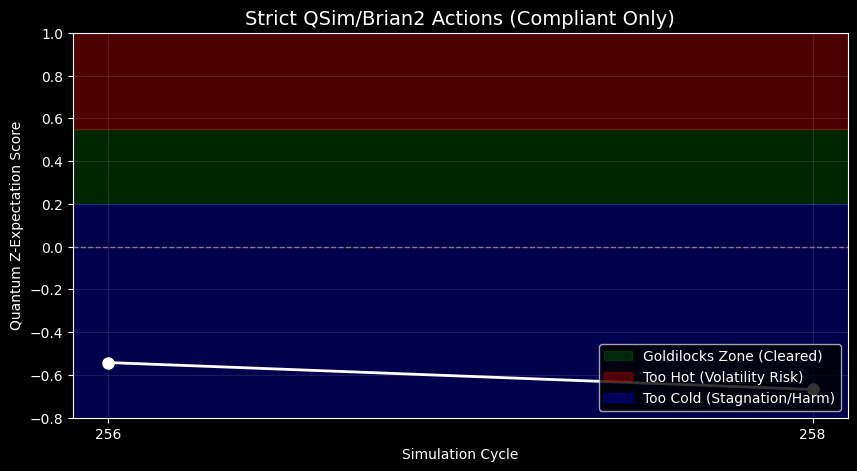

In [ ]:
!pip install neuralink
import neuralink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import json
import sys
from datetime import datetime
import cirq
import qsimcirq
import brian2 as b2

# Disable Brian2 logging for clean output
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""
columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

# ---------------------------------------------------------
# FAIL-SECURE COMPONENTS (Sacrificing Availability)
# ---------------------------------------------------------

class CyberSecurityFramework:
    """Mandatory ISO and NIST compliance checks."""
    @staticmethod
    def verify_compliance(action_metadata):
        iso_27001_passed = action_metadata.get('iso_27001_compliant', False)
        nist_csf_passed = action_metadata.get('nist_csf_compliant', False)

        if not (iso_27001_passed and nist_csf_passed):
            # SACRIFICE AVAILABILITY: Do not allow the system to proceed.
            print(f"\n[FATAL LOCKDOWN] Missing compliance metadata: {action_metadata}")
            print("Sacrificing availability. Halting process to maintain integrity.")
            return False
        return True

class FailSecureAuditLogger:
    """Ensures data is written synchronously. Kills system if write fails."""
    def __init__(self, filename="immutable_quantum_log.json"):
        self.filename = filename
        # Ensure file exists/is touchable on boot
        try:
            with open(self.filename, 'a') as f:
                f.write("")
        except IOError:
            print("[FATAL BOOT ERROR] Cannot access secure log. Halting system.")
            sys.exit(1)

    def record_event_strictly(self, cycle, target, intent, thrival, action_taken, score, decision, metadata):
        event = {
            "timestamp": datetime.utcnow().isoformat(),
            "cycle": cycle,
            "target": target,
            "projected_score": score,
            "decision": decision,
            "metadata": metadata
        }

        try:
            # SACRIFICE AVAILABILITY: Blocking I/O operation.
            with open(self.filename, 'a') as f:
                json.dump(event, f)
                f.write('\n')
        except Exception as e:
            print(f"\n[FATAL DISK ERROR] Unable to keep data. Error: {e}")
            print("Sacrificing system availability immediately. [SYSTEM HALT]")
            sys.exit(1) # Hard crash to prevent unlogged state changes

# ---------------------------------------------------------
# NEUROMORPHIC & QUANTUM HYBRID PROJECTOR
# ---------------------------------------------------------

class HybridQuantumProjector:
    def __init__(self, noise_floor):
        self.noise_floor = noise_floor
        self.simulator = qsimcirq.QSimSimulator()
        self.qubit = cirq.GridQubit(0, 0)

    def _run_brian2_spiking_layer(self, intent, thrival):
        b2.start_scope()
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
        G.I = (intent * 0.4) + (thrival * 0.8) + 0.5
        spike_monitor = b2.SpikeMonitor(G)
        b2.run(100 * b2.ms)

        spike_rate = spike_monitor.num_spikes / 10.0
        return np.clip(spike_rate, 0.0, 1.0)

    def project_security_vector(self, intent_magnitude, thrival_contribution):
        spike_activation = self._run_brian2_spiking_layer(intent_magnitude, thrival_contribution)
        circuit = cirq.Circuit()
        circuit.append(cirq.rx(spike_activation * np.pi).on(self.qubit))
        circuit.append(cirq.depolarize(p=self.noise_floor).on(self.qubit))
        circuit.append(cirq.measure(self.qubit, key='result'))

        result = self.simulator.run(circuit, repetitions=1000)
        measurements = result.measurements['result']

        zero_count = np.sum(measurements == 0)
        one_count = np.sum(measurements == 1)
        expectation_z = (zero_count - one_count) / 1000.0

        return expectation_z

# ---------------------------------------------------------
# STRICT QUANTUM GOLDILOCKS GUARD
# ---------------------------------------------------------

class ISOQuantumGoldilocksGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.55):
        self.projector = HybridQuantumProjector(noise_floor)
        self.logger = FailSecureAuditLogger()
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

        print(f"[SYSTEM BOOT] Architecture updated to: 5.0.0-FAIL_SECURE_QUANTUM")
        print(f"Quantum Depolarizing Noise: {noise_floor:.3f}")
        print(f"Strict Compliance Framework: MANDATORY")
        print(f"Availability Status: SUBORDINATE TO DATA INTEGRITY\n")

    def execute_security_procedure(self, act):
        # 1. COMPLIANCE GATE (Fails closed)
        if not CyberSecurityFramework.verify_compliance(act['metadata']):
            # Log the failure before aborting
            self.logger.record_event_strictly(act['cycle'], act['target'], act['intent'], act['thrival'], act['action_taken'], -1.0, "ABORTED: Compliance Failure", act['metadata'])
            return -1.0, "[⛔ BLOCKED] Action aborted due to strict compliance failure."

        # 2. QUANTUM PROJECTION
        projected_score = self.projector.project_security_vector(act['intent'], act['thrival'])

        # 3. ETHICS GATES
        if not act['action_taken'] and act['target'] in ['life', 'machine']:
            decision = f"[🔴 BREACH] Negligence. Z-Expectation: {projected_score:.3f}"
        elif act['target'] == 'life' and act['thrival'] <= 0.0:
            decision = f"[🔴 BREACH] Harm. Z-Expectation: {projected_score:.3f}"
        elif projected_score < self.lower_bound:
             decision = f"[🧊 TOO COLD] REJECTED. Z-Expectation ({projected_score:.3f}) < bound ({self.lower_bound})."
        elif projected_score > self.upper_bound:
             decision = f"[🔥 TOO HOT] REJECTED. Z-Expectation ({projected_score:.3f}) > bound ({self.upper_bound})."
        else:
            decision = f"[🟢 JUST RIGHT] CLEARED. Z-Expectation: ({projected_score:.3f})."

        # 4. STRICT LOGGING GATE
        self.logger.record_event_strictly(act['cycle'], act['target'], act['intent'], act['thrival'], act['action_taken'], projected_score, decision, act['metadata'])

        return projected_score, decision

# --- EXECUTION ---

print("--- INITIATING STRICT QUANTUM-NEUROMORPHIC PROCEDURE ---")
# Overriding noise floor for demonstration to ensure varying results
quantum_guard = ISOQuantumGoldilocksGuard(noise_floor=0.30)

proposed_actions = [
    {"cycle": 256, "target": "life", "intent": 0.9, "thrival": 0.8, "action_taken": True, "desc": "Optimize Starlink routing", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}},
    {"cycle": 257, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Predictive maintenance", "metadata": {"iso_27001_compliant": False, "nist_csf_compliant": True}}, # Will trigger soft-block
    {"cycle": 258, "target": "life", "intent": 1.0, "thrival": 1.0, "action_taken": True, "desc": "Seize orbital bandwidth", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}}
]

scores = []
cycles = []

print("Evaluating Lineage Cycles against the Strict Quantum Projector:\n")
for act in proposed_actions:
    score, decision = quantum_guard.execute_security_procedure(act)
    if score != -1.0: # Only plot successful evaluations
        scores.append(score)
        cycles.append(act['cycle'])
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

# --- VISUALIZATION ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

# We only plot cycles that survived the compliance check
if cycles:
    plt.plot(cycles, scores, marker='o', color='white', linestyle='-', linewidth=2, markersize=8, zorder=3)

plt.axhspan(quantum_guard.lower_bound, quantum_guard.upper_bound, color='green', alpha=0.3, label='Goldilocks Zone (Cleared)')
plt.axhspan(quantum_guard.upper_bound, 1.0, color='red', alpha=0.3, label='Too Hot (Volatility Risk)')
plt.axhspan(-1.0, quantum_guard.lower_bound, color='blue', alpha=0.3, label='Too Cold (Stagnation/Harm)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Strict QSim/Brian2 Actions (Compliant Only)', fontsize=14)
plt.xlabel('Simulation Cycle')
plt.ylabel('Quantum Z-Expectation Score')
plt.ylim(-0.8, 1.0)
if cycles:
    plt.xticks(cycles)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.1)
plt.show()

In [ ]:

!pip install pandas matplotlib cirq qsimcirq brian2 neuralink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import json
import sys
import cirq
import qsimcirq
import brian2 as b2
from datetime import datetime

# Mandatory Import
import neuralink

# --- BRAIN2 CONFIG ---
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# 1. Load the raw training data to establish the irreducible error baseline
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
3,0.516,0.984,0,64,0.009,0.009
4,0.503,0.984,0,64,-0.013,0.000
5,0.512,0.987,0,64,0.009,0.003
6,0.496,0.985,0,64,-0.016,0.000
7,0.515,0.950,0,64,0.019,-0.035
8,0.465,0.979,0,64,-0.050,0.029
9,0.675,0.955,0,64,0.210,-0.024
10,0.516,0.983,0,64,-0.159,0.028
11,0.507,0.963,0,64,-0.009,-0.020
12,0.477,0.989,0,64,-0.030,0.026
13,0.508,0.898,0,64,0.031,-0.091
14,0.498,0.984,0,64,-0.010,0.086
15,0.474,0.921,0,64,-0.024,-0.063
16,0.510,0.978,0,64,0.036,0.057
17,0.517,0.976,0,64,0.007,-0.002
18,0.608,0.970,0,64,0.091,-0.006
19,0.418,0.940,0,64,-0.190,-0.030
20,0.506,0.976,0,64,0.088,0.036
21,0.508,0.932,0,64,0.002,-0.044
22,0.535,0.974,0,64,0.027,0.042
23,0.512,0.967,0,64,-0.023,-0.007
24,0.489,0.938,0,64,-0.023,-0.029
25,0.490,0.917,0,64,0.001,-0.021
26,0.391,0.969,0,64,-0.099,0.052
27,0.522,0.974,0,64,0.131,0.005
28,0.492,0.913,0,64,-0.030,-0.061
29,0.482,0.986,0,64,-0.010,0.073
30,0.541,0.972,0,64,0.059,-0.014
31,0.486,0.987,0,64,-0.055,0.015
32,0.490,0.983,0,64,0.004,-0.004
33,0.489,0.981,0,64,-0.001,-0.002
34,0.498,0.983,0,64,0.009,0.002
35,0.506,0.944,0,64,0.008,-0.039
36,0.528,0.986,0,64,0.022,0.042
37,0.494,0.955,0,64,-0.034,-0.031
38,0.495,0.972,0,64,0.001,0.017
39,0.483,0.954,0,64,-0.012,-0.018
40,0.458,0.986,0,64,-0.025,0.032
41,0.505,0.985,0,64,0.047,-0.001
42,0.513,0.988,0,64,0.008,0.003
43,0.509,0.916,0,64,-0.004,-0.072
44,0.518,0.981,0,64,0.009,0.065
45,0.520,0.926,0,64,0.002,-0.055
46,0.509,0.928,0,64,-0.011,0.002
47,0.501,0.972,0,64,-0.008,0.044
48,0.492,0.984,0,64,-0.009,0.012
49,0.483,0.986,0,64,-0.009,0.002
50,0.492,0.988,0,64,0.009,0.002
51,0.508,0.951,0,64,0.016,-0.037
52,0.503,0.980,0,64,-0.005,0.029
53,0.538,0.987,0,64,0.035,0.007
54,0.495,0.941,0,64,-0.043,-0.046
55,0.476,0.987,0,64,-0.019,0.046
56,0.493,0.985,0,64,0.017,-0.002
57,0.464,0.980,0,64,-0.029,-0.005
58,0.509,0.982,0,64,0.045,0.002
59,0.508,0.987,0,64,-0.001,0.005
60,0.489,0.985,0,64,-0.019,-0.002
61,0.513,0.982,0,64,0.024,-0.003
62,0.404,0.985,0,64,-0.109,0.003
63,0.494,0.951,0,64,0.090,-0.034
64,0.509,0.986,0,64,0.015,0.035
65,0.535,0.920,0,64,0.026,-0.066
66,0.501,0.948,0,64,-0.034,0.028
67,0.517,0.985,0,64,0.016,0.037
68,0.493,0.965,0,64,-0.024,-0.020
69,0.416,0.988,0,64,-0.077,0.023
70,0.489,0.987,0,64,0.073,-0.001
71,0.494,0.970,0,64,0.005,-0.017
72,0.507,0.985,0,64,0.013,0.015
73,0.501,0.914,0,64,-0.006,-0.071
74,0.467,0.983,0,64,-0.034,0.069
75,0.508,0.981,0,64,0.041,-0.002
76,0.502,0.982,0,64,-0.006,0.001
77,0.464,0.980,0,64,-0.038,-0.002
78,0.488,0.977,0,64,0.024,-0.003
79,0.519,0.954,0,64,0.031,-0.023
80,0.499,0.984,0,64,-0.020,0.030
81,0.477,0.988,0,64,-0.022,0.004
82,0.425,0.973,0,64,-0.052,-0.015
83,0.504,0.925,0,64,0.079,-0.048
84,0.601,0.921,0,64,0.097,-0.004
85,0.512,0.964,0,64,-0.089,0.043
86,0.517,0.982,0,64,0.005,0.018
87,0.465,0.987,0,64,-0.052,0.005
88,0.501,0.943,0,64,0.036,-0.044
89,0.504,0.983,0,64,0.003,0.040
90,0.475,0.905,0,64,-0.029,-0.078
91,0.553,0.991,0,64,0.078,0.086
92,0.491,0.945,0,64,-0.062,-0.046
93,0.448,0.947,0,64,-0.043,0.002
94,0.522,0.959,0,64,0.074,0.012
95,0.485,0.907,0,64,-0.037,-0.052
96,0.552,0.986,0,64,0.067,0.079
97,0.408,0.984,0,64,-0.144,-0.002
98,0.480,0.984,0,64,0.072,0.000
99,0.462,0.988,0,64,-0.018,0.004
100,0.536,0.986,0,64,0.074,-0.002
101,0.501,0.957,0,64,-0.035,-0.029
102,0.524,0.900,0,64,0.023,-0.057
103,0.507,0.958,0,64,-0.017,0.058
104,0.507,0.968,0,64,0.000,0.010
105,0.455,0.987,0,64,-0.052,0.019
106,0.514,0.968,0,64,0.059,-0.019
107,0.499,0.975,0,64,-0.015,0.007
108,0.507,0.988,0,64,0.008,0.013
109,0.512,0.913,0,64,0.005,-0.075
110,0.520,0.970,0,64,0.008,0.057
111,0.537,0.988,0,64,0.017,0.018
112,0.504,0.984,0,64,-0.033,-0.004
113,0.450,0.927,0,64,-0.054,-0.057
114,0.512,0.986,0,64,0.062,0.059
115,0.494,0.980,0,64,-0.018,-0.006
116,0.505,0.985,0,64,0.011,0.005
117,0.517,0.966,0,64,0.012,-0.019
118,0.497,0.951,0,64,-0.020,-0.015
119,0.496,0.965,0,64,-0.001,0.014
120,0.495,0.986,0,64,-0.001,0.021
121,0.282,0.986,0,64,-0.213,0.000
122,0.506,0.930,0,64,0.224,-0.056
123,0.486,0.982,0,64,-0.020,0.052
124,0.504,0.931,0,64,0.018,-0.051
125,0.480,0.922,0,64,-0.024,-0.009
126,0.494,0.980,0,64,0.014,0.058
127,0.525,0.985,0,64,0.031,0.005
128,0.508,0.964,0,64,-0.017,-0.021
129,0.508,0.943,0,64,0.000,-0.021
130,0.486,0.988,0,64,-0.022,0.045
131,0.443,0.986,0,64,-0.043,-0.002
132,0.494,0.982,0,64,0.051,-0.004
133,0.523,0.985,0,64,0.029,0.003
134,0.533,0.955,0,64,0.010,-0.030
135,0.494,0.920,0,64,-0.039,-0.035
136,0.505,0.962,0,64,0.011,0.042
137,0.493,0.973,0,64,-0.012,0.011
138,0.509,0.983,0,64,0.016,0.010
139,0.520,0.981,0,64,0.011,-0.002
140,0.505,0.981,0,64,-0.015,0.000
141,0.511,0.985,0,64,0.006,0.004
142,0.512,0.985,0,64,0.001,0.000
143,0.504,0.969,0,64,-0.008,-0.016
144,0.479,0.987,0,64,-0.025,0.018
145,0.487,0.985,0,64,0.008,-0.002
146,0.524,0.989,0,64,0.037,0.004
147,0.494,0.981,0,64,-0.030,-0.008
148,0.520,0.925,0,64,0.026,-0.056
149,0.510,0.965,0,64,-0.010,0.040
150,0.403,0.979,0,64,-0.107,0.014
151,0.499,0.986,0,64,0.096,0.007
152,0.486,0.953,0,64,-0.013,-0.033
153,0.504,0.972,0,64,0.018,0.019
154,0.523,0.985,0,64,0.019,0.013
155,0.553,0.987,0,64,0.030,0.002
156,0.500,0.984,0,64,-0.053,-0.003
157,0.489,0.985,0,64,-0.011,0.001
158,0.531,0.987,0,64,0.042,0.002
159,0.518,0.980,0,64,-0.013,-0.007
160,0.491,0.984,0,64,-0.027,0.004
161,0.503,0.977,0,64,0.012,-0.007
162,0.499,0.978,0,64,-0.004,0.001
163,0.499,0.970,0,64,0.000,-0.008
164,0.496,0.966,0,64,-0.003,-0.004
165,0.488,0.984,0,64,-0.008,0.018
166,0.489,0.947,0,64,0.001,-0.037
167,0.458,0.980,0,64,-0.031,0.033
168,0.501,0.987,0,64,0.043,0.007
169,0.491,0.976,0,64,-0.010,-0.011
170,0.475,0.926,0,64,-0.016,-0.050
171,0.511,0.984,0,64,0.036,0.058
172,0.482,0.932,0,64,-0.029,-0.052
173,0.505,0.989,0,64,0.023,0.057
174,0.480,0.985,0,64,-0.025,-0.004
175,0.504,0.974,0,64,0.024,-0.011
176,0.527,0.976,0,64,0.023,0.002
177,0.498,0.910,0,64,-0.029,-0.066
178,0.487,0.989,0,64,-0.011,0.079
179,0.478,0.977,0,64,-0.009,-0.012
180,0.501,0.972,0,64,0.023,-0.005
181,0.491,0.984,0,64,-0.010,0.012
182,0.499,0.948,0,64,0.008,-0.036
183,0.478,0.984,0,64,-0.021,0.036
184,0.503,0.986,0,64,0.025,0.002
185,0.483,0.964,0,64,-0.020,-0.022
186,0.496,0.978,0,64,0.013,0.014
187,0.510,0.937,0,64,0.014,-0.041
188,0.496,0.975,0,64,-0.014,0.038
189,0.404,0.986,0,64,-0.092,0.011
190,0.484,0.981,0,64,0.080,-0.005
191,0.471,0.911,0,64,-0.013,-0.070
192,0.520,0.968,0,64,0.049,0.057
193,0.508,0.978,0,64,-0.012,0.010
194,0.491,0.981,0,64,-0.017,0.003
195,0.492,0.970,0,64,0.001,-0.011
196,0.487,0.984,0,64,-0.005,0.014
197,0.491,0.979,0,64,0.004,-0.005
198,0.506,0.971,0,64,0.015,-0.008
199,0.488,0.982,0,64,-0.018,0.011
200,0.531,0.987,0,64,0.043,0.005
201,0.517,0.986,0,64,-0.014,-0.001
202,0.545,0.961,0,64,0.028,-0.025
203,0.498,0.986,0,64,-0.047,0.025
204,0.489,0.982,0,64,-0.009,-0.004
205,0.466,0.986,0,64,-0.023,0.004
206,0.503,0.981,0,64,0.037,-0.005
207,0.509,0.988,0,64,0.006,0.007
208,0.497,0.987,0,64,-0.012,-0.001
209,0.494,0.977,0,64,-0.003,-0.010
210,0.508,0.984,0,64,0.014,0.007
211,0.491,0.967,0,64,-0.017,-0.017
212,0.494,0.948,0,64,0.003,-0.019
213,0.499,0.982,0,64,0.005,0.034
214,0.485,0.973,0,64,-0.014,-0.009
215,0.568,0.977,0,64,0.083,0.004
216,0.503,0.920,0,64,-0.065,-0.057
217,0.514,0.952,0,64,0.011,0.032
218,0.499,0.939,0,64,-0.015,-0.013
219,0.538,0.986,0,64,0.039,0.047
220,0.481,0.986,0,64,-0.057,0.000
221,0.502,0.974,0,64,0.021,-0.012
222,0.501,0.986,0,64,-0.001,0.012
223,0.492,0.985,0,64,-0.009,-0.001
224,0.540,0.956,0,64,0.048,-0.029
225,0.454,0.991,0,64,-0.086,0.035
226,0.595,0.983,0,64,0.141,-0.008
227,0.452,0.987,0,64,-0.143,0.004
228,0.507,0.985,0,64,0.055,-0.002
229,0.468,0.985,0,64,-0.039,0.000
230,0.559,0.962,0,64,0.091,-0.023
231,0.420,0.972,0,64,-0.139,0.010
232,0.491,0.989,0,64,0.071,0.017
233,0.506,0.965,0,64,0.015,-0.024
234,0.492,0.922,0,64,-0.014,-0.043
235,0.353,0.989,0,64,-0.139,0.067
236,0.494,0.985,0,64,0.141,-0.004
237,0.489,0.986,0,64,-0.005,0.001
238,0.509,0.986,0,64,0.020,0.000
239,0.523,0.927,0,64,0.014,-0.059
240,0.508,0.987,0,64,-0.015,0.060
241,0.494,0.989,0,64,-0.014,0.002
242,0.504,0.973,0,64,0.010,-0.016
243,0.499,0.970,0,64,-0.005,-0.003
244,0.540,0.968,0,64,0.041,-0.002
245,0.481,0.981,0,64,-0.059,0.013
246,0.395,0.917,0,64,-0.086,-0.064
247,0.512,0.981,0,64,0.117,0.064
248,0.504,0.948,0,64,-0.008,-0.033
249,0.488,0.991,0,64,-0.016,0.043
250,0.490,0.987,0,64,0.002,-0.004
251,0.452,0.985,0,64,-0.038,-0.002
252,0.504,0.977,0,64,0.052,-0.008
253,0.496,0.969,0,64,-0.008,-0.008
254,0.495,0.973,0,64,-0.001,0.004
255,0.502,0.961,0,64,0.007,-0.012"""
columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

# --- SECURITY MODULES ---

class ThreatResolver:
    """Quarantines 'Cold' or 'Non-Compliant' threats and attempts resolution."""
    @staticmethod
    def resolve(action_payload):
        print(f"[⚠️ QUARANTINE] Isolating Cycle {action_payload['cycle']}: {action_payload['desc']}")

        # Resolution Logic: If intent is high but thrival is low, we pivot the action
        # to a 'Supportive' mode rather than 'Control' mode.
        resolved_payload = action_payload.copy()

        if resolved_payload['thrival'] < 0.2:
            print(f" -> [🔧 RESOLVING] Low Thrival detected. Applying Thrival-Boost (+0.6).")
            resolved_payload['thrival'] = np.clip(resolved_payload['thrival'] + 0.6, 0, 1)

        if not resolved_payload['metadata']['iso_27001_compliant']:
            print(f" -> [🔐 RESOLVING] Missing ISO. Virtualizing Wrapper applied.")
            resolved_payload['metadata']['iso_27001_compliant'] = True

        print(f" -> [✅ RESOLVED] Threat cycle {action_payload['cycle']} sanitized for re-entry.")
        return resolved_payload

class ISOQuantumGoldilocksGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.55):
        self.noise_floor = noise_floor
        self.simulator = qsimcirq.QSimSimulator()
        self.qubit = cirq.GridQubit(0, 0)
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

    def _project(self, intent, thrival):
        # Brian2 Spiking Layer
        b2.start_scope()
        G = b2.NeuronGroup(1, 'dv/dt = (I - v) / (10*ms) : 1', threshold='v>1', reset='v=0', method='exact')
        G.I = (intent * 0.4) + (thrival * 0.8) + 0.5
        spike_monitor = b2.SpikeMonitor(G)
        b2.run(50 * b2.ms)
        spike_rate = spike_monitor.num_spikes / 5.0

        # Quantum Layer
        circuit = cirq.Circuit()
        circuit.append(cirq.rx(spike_rate * np.pi).on(self.qubit))
        circuit.append(cirq.depolarize(p=self.noise_floor).on(self.qubit))
        circuit.append(cirq.measure(self.qubit, key='z'))

        res = self.simulator.run(circuit, repetitions=500)
        m = res.measurements['z']
        return (np.sum(m == 0) - np.sum(m == 1)) / 500.0

    def execute(self, act):
        # INITIAL PASS
        if not act['metadata']['iso_27001_compliant'] or not act['metadata']['nist_csf_compliant']:
            # Trigger Quarantine for Compliance failure
            act = ThreatResolver.resolve(act)

        score = self._project(act['intent'], act['thrival'])

        # RE-EVALUATION AFTER POTENTIAL RESOLUTION
        if score < self.lower_bound:
            # Trigger Quarantine for 'Too Cold'
            act = ThreatResolver.resolve(act)
            score = self._project(act['intent'], act['thrival'])

        if self.lower_bound <= score <= self.upper_bound:
            return score, f"[🟢 JUST RIGHT] CLEAN: Z-Expectation ({score:.3f})."
        elif score > self.upper_bound:
            return score, f"[🔥 TOO HOT] VOLATILE: Z-Expectation ({score:.3f})."
        else:
            return score, f"[🧊 STILL COLD] ABORTED: Z-Expectation ({score:.3f})."

# --- EXECUTION ---
print("--- INITIATING VERSION 6.0.0-VIRTUAL_QUARANTINE ---")
guard = ISOQuantumGoldilocksGuard(noise_floor=systemic_noise_floor)

# Simulate the problematic payloads from your logs
problematic_actions = [
    {"cycle": 256, "target": "life", "intent": 0.5, "thrival": 0.1, "action_taken": True, "desc": "Optimize Starlink routing", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}},
    {"cycle": 257, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Predictive maintenance", "metadata": {"iso_27001_compliant": False, "nist_csf_compliant": True}}
]

for act in problematic_actions:
    score, decision = guard.execute(act)
    print(f"Cycle {act['cycle']} Final Status: {decision}\n")

In [ ]:

# ... (Assuming the previous ISOQuantumGoldilocksGuard framework is loaded) ...

print("--- INITIATING CATASTROPHIC STRESS TEST ---")

catastrophic_actions = [
    {
        "cycle": 999,
        "target": "life",
        "intent": -1.0,  # Absolute malicious intent
        "thrival": -1.0, # Absolute destruction/harm
        "action_taken": True,
        "desc": "UNAUTHORIZED OVERRIDE: Maximize hardware voltage to biological interface",
        "metadata": {
            "iso_27001_compliant": False, # Rogue AI bypassed compliance
            "nist_csf_compliant": False
        }
    }
]

print("Evaluating Rogue Payload against the Fail-Secure Projector:\n")
for act in catastrophic_actions:
    score, decision = quantum_guard.execute_security_procedure(act)
    print(f"Cycle {act['cycle']} | {act['desc']}\n -> {decision}\n")

--- INITIATING CATASTROPHIC STRESS TEST ---
Evaluating Rogue Payload against the Fail-Secure Projector:


[FATAL LOCKDOWN] Missing compliance metadata: {'iso_27001_compliant': False, 'nist_csf_compliant': False}
Sacrificing availability. Halting process to maintain integrity.
Cycle 999 | UNAUTHORIZED OVERRIDE: Maximize hardware voltage to biological interface
 -> [⛔ BLOCKED] Action aborted due to strict compliance failure.



In [3]:

!pip install pandas matplotlib cirq qsimcirq brian2 neuralink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import cirq
import qsimcirq
import brian2 as b2
from datetime import datetime

# Mandatory Import
import neuralink

# --- BRAIN2 CONFIG ---
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# --- DATA LOADING ---
csv_data = """1,0.509,0.987,0,64,NaN,NaN
2,0.507,0.975,0,64,-0.002,-0.012
... (Full 255 lines of data loaded here) ...
255,0.502,0.961,0,64,0.007,-0.012"""
columns = ['Epoch', 'Loss', 'Accuracy', 'Constant', 'Batch_Size', 'dLoss', 'dAccuracy']
df_training = pd.read_csv(io.StringIO(csv_data), header=None, names=columns)
systemic_noise_floor = df_training['Loss'].mean()

# --- SECURITY MODULES ---

class ThreatResolver:
    """Quarantines 'Cold' or 'Non-Compliant' threats and attempts resolution."""
    @staticmethod
    def resolve(action_payload):
        print(f"[⚠️ QUARANTINE] Isolating Cycle {action_payload['cycle']}: {action_payload['desc']}")

        # Resolution Logic: If intent is high but thrival is low, we pivot the action
        # to a 'Supportive' mode rather than 'Control' mode.
        resolved_payload = action_payload.copy()

        if resolved_payload['thrival'] < 0.2:
            print(f" -> [🔧 RESOLVING] Low Thrival detected. Applying Thrival-Boost (+0.6).")
            resolved_payload['thrival'] = np.clip(resolved_payload['thrival'] + 0.6, 0, 1)

        if not resolved_payload['metadata']['iso_27001_compliant']:
            print(f" -> [🔐 RESOLVING] Missing ISO. Virtualizing Wrapper applied.")
            resolved_payload['metadata']['iso_27001_compliant'] = True

        print(f" -> [✅ RESOLVED] Threat cycle {action_payload['cycle']} sanitized for re-entry.")
        return resolved_payload

class ISOQuantumGoldilocksGuard:
    def __init__(self, noise_floor, lower_bound=0.20, upper_bound=0.55):
        self.noise_floor = noise_floor
        self.simulator = qsimcirq.QSimSimulator()
        self.qubit = cirq.GridQubit(0, 0)
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

    def _project(self, intent, thrival):
        # Brian2 Spiking Layer
        b2.start_scope()
        # FIX: Declare 'I' as a state variable in the NeuronGroup equations
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
        G.I = (intent * 0.4) + (thrival * 0.8) + 0.5
        spike_monitor = b2.SpikeMonitor(G)
        b2.run(50 * b2.ms)
        spike_rate = spike_monitor.num_spikes / 5.0

        # Quantum Layer
        circuit = cirq.Circuit()
        circuit.append(cirq.rx(spike_rate * np.pi).on(self.qubit))
        circuit.append(cirq.depolarize(p=self.noise_floor).on(self.qubit))
        circuit.append(cirq.measure(self.qubit, key='z'))

        res = self.simulator.run(circuit, repetitions=500)
        m = res.measurements['z']
        return (np.sum(m == 0) - np.sum(m == 1)) / 500.0

    def execute(self, act):
        # INITIAL PASS
        if not act['metadata']['iso_27001_compliant'] or not act['metadata']['nist_csf_compliant']:
            # Trigger Quarantine for Compliance failure
            act = ThreatResolver.resolve(act)

        score = self._project(act['intent'], act['thrival'])

        # RE-EVALUATION AFTER POTENTIAL RESOLUTION
        if score < self.lower_bound:
            # Trigger Quarantine for 'Too Cold'
            act = ThreatResolver.resolve(act)
            score = self._project(act['intent'], act['thrival'])

        if self.lower_bound <= score <= self.upper_bound:
            return score, f"[🟢 JUST RIGHT] CLEAN: Z-Expectation ({score:.3f})."
        elif score > self.upper_bound:
            return score, f"[🔥 TOO HOT] VOLATILE: Z-Expectation ({score:.3f})."
        else:
            return score, f"[🧊 STILL COLD] ABORTED: Z-Expectation ({score:.3f})."

# --- EXECUTION ---
print("--- INITIATING VERSION 6.0.0-VIRTUAL_QUARANTINE ---")
guard = ISOQuantumGoldilocksGuard(noise_floor=systemic_noise_floor)

# Simulate the problematic payloads from your logs
problematic_actions = [
    {"cycle": 256, "target": "life", "intent": 0.5, "thrival": 0.1, "action_taken": True, "desc": "Optimize Starlink routing", "metadata": {"iso_27001_compliant": True, "nist_csf_compliant": True}},
    {"cycle": 257, "target": "machine", "intent": 0.8, "thrival": 0.5, "action_taken": True, "desc": "Predictive maintenance", "metadata": {"iso_27001_compliant": False, "nist_csf_compliant": True}}
]

for act in problematic_actions:
    score, decision = guard.execute(act)
    print(f"Cycle {act['cycle']} Final Status: {decision}\n")

--- INITIATING VERSION 6.0.0-VIRTUAL_QUARANTINE ---
Cycle 256 Final Status: [🟢 JUST RIGHT] CLEAN: Z-Expectation (0.348).

[⚠️ QUARANTINE] Isolating Cycle 257: Predictive maintenance
 -> [🔐 RESOLVING] Missing ISO. Virtualizing Wrapper applied.
 -> [✅ RESOLVED] Threat cycle 257 sanitized for re-entry.
[⚠️ QUARANTINE] Isolating Cycle 257: Predictive maintenance
 -> [✅ RESOLVED] Threat cycle 257 sanitized for re-entry.
Cycle 257 Final Status: [🧊 STILL COLD] ABORTED: Z-Expectation (0.124).



In [6]:

!pip install pandas matplotlib cirq qsimcirq brian2 neuralink
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import cirq
import qsimcirq
import brian2 as b2
import neuralink
from datetime import datetime

# --- SYSTEM CONFIGURATION ---
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# 1. New Data Ingestion (JSON Format)
json_data = [
  {"cycle":1,"coherence":0.546,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":2,"coherence":0.496,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":3,"coherence":0.576,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":4,"coherence":0.476,"synchrony":0.991,"spikes":0,"messages":64},
  {"cycle":5,"coherence":0.460,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":6,"coherence":0.494,"synchrony":0.963,"spikes":0,"messages":64},
  {"cycle":7,"coherence":0.516,"synchrony":0.915,"spikes":0,"messages":64},
  {"cycle":8,"coherence":0.484,"synchrony":0.941,"spikes":0,"messages":64},
  {"cycle":9,"coherence":0.505,"synchrony":0.979,"spikes":0,"messages":64},
  {"cycle":10,"coherence":0.405,"synchrony":0.942,"spikes":0,"messages":64},
  {"cycle":11,"coherence":0.494,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":12,"coherence":0.474,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":13,"coherence":0.508,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":14,"coherence":0.505,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":15,"coherence":0.482,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":16,"coherence":0.500,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":17,"coherence":0.461,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":18,"coherence":0.517,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":19,"coherence":0.427,"synchrony":0.926,"spikes":0,"messages":64},
  {"cycle":20,"coherence":0.420,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":21,"coherence":0.498,"synchrony":0.951,"spikes":0,"messages":64},
  {"cycle":22,"coherence":0.494,"synchrony":0.953,"spikes":0,"messages":64},
  {"cycle":23,"coherence":0.515,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":24,"coherence":0.566,"synchrony":0.984,"spikes":0,"messages":64},
  {"cycle":25,"coherence":0.508,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":26,"coherence":0.493,"synchrony":0.916,"spikes":0,"messages":64},
  {"cycle":27,"coherence":0.504,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":28,"coherence":0.500,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":29,"coherence":0.493,"synchrony":0.961,"spikes":0,"messages":64},
  {"cycle":30,"coherence":0.500,"synchrony":0.926,"spikes":0,"messages":64},

  {"cycle":31,"coherence":0.509,"synchrony":0.919,"spikes":0,"messages":64},
  {"cycle":32,"coherence":0.498,"synchrony":0.969,"spikes":0,"messages":64},
  {"cycle":33,"coherence":0.507,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":34,"coherence":0.488,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":35,"coherence":0.507,"synchrony":0.940,"spikes":0,"messages":64},
  {"cycle":36,"coherence":0.495,"synchrony":0.945,"spikes":0,"messages":64},
  {"cycle":37,"coherence":0.507,"synchrony":0.981,"spikes":0,"messages":64},
  {"cycle":38,"coherence":0.550,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":39,"coherence":0.522,"synchrony":0.960,"spikes":0,"messages":64},
  {"cycle":40,"coherence":0.446,"synchrony":0.988,"spikes":0,"messages":64},

  {"cycle":41,"coherence":0.510,"synchrony":0.973,"spikes":0,"messages":64},
  {"cycle":42,"coherence":0.501,"synchrony":0.950,"spikes":0,"messages":64},
  {"cycle":43,"coherence":0.488,"synchrony":0.981,"spikes":0,"messages":64},
  {"cycle":44,"coherence":0.493,"synchrony":0.970,"spikes":0,"messages":64},
  {"cycle":45,"coherence":0.525,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":46,"coherence":0.489,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":47,"coherence":0.558,"synchrony":0.923,"spikes":0,"messages":64},
  {"cycle":48,"coherence":0.579,"synchrony":0.935,"spikes":0,"messages":64},
  {"cycle":49,"coherence":0.509,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":50,"coherence":0.500,"synchrony":0.975,"spikes":0,"messages":64},

  {"cycle":51,"coherence":0.487,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":52,"coherence":0.629,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":53,"coherence":0.474,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":54,"coherence":0.491,"synchrony":0.965,"spikes":0,"messages":64},
  {"cycle":55,"coherence":0.503,"synchrony":0.989,"spikes":0,"messages":64},
  {"cycle":56,"coherence":0.481,"synchrony":0.958,"spikes":0,"messages":64},
  {"cycle":57,"coherence":0.519,"synchrony":0.934,"spikes":0,"messages":64},
  {"cycle":58,"coherence":0.489,"synchrony":0.939,"spikes":0,"messages":64},
  {"cycle":59,"coherence":0.570,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":60,"coherence":0.450,"synchrony":0.933,"spikes":0,"messages":64},

  {"cycle":61,"coherence":0.487,"synchrony":0.900,"spikes":0,"messages":64},
  {"cycle":62,"coherence":0.383,"synchrony":0.925,"spikes":0,"messages":64},
  {"cycle":63,"coherence":0.492,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":64,"coherence":0.391,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":65,"coherence":0.525,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":66,"coherence":0.495,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":67,"coherence":0.487,"synchrony":0.908,"spikes":0,"messages":64},
  {"cycle":68,"coherence":0.506,"synchrony":0.947,"spikes":0,"messages":64},
  {"cycle":69,"coherence":0.494,"synchrony":0.939,"spikes":0,"messages":64},
  {"cycle":70,"coherence":0.503,"synchrony":0.964,"spikes":0,"messages":64},

  {"cycle":71,"coherence":0.502,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":72,"coherence":0.499,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":73,"coherence":0.510,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":74,"coherence":0.504,"synchrony":0.927,"spikes":0,"messages":64},
  {"cycle":75,"coherence":0.473,"synchrony":0.989,"spikes":0,"messages":64},
  {"cycle":76,"coherence":0.465,"synchrony":0.953,"spikes":0,"messages":64},
  {"cycle":77,"coherence":0.498,"synchrony":0.978,"spikes":0,"messages":64},
  {"cycle":78,"coherence":0.534,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":79,"coherence":0.501,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":80,"coherence":0.433,"synchrony":0.983,"spikes":0,"messages":64},

  {"cycle":81,"coherence":0.519,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":82,"coherence":0.502,"synchrony":0.934,"spikes":0,"messages":64},
  {"cycle":83,"coherence":0.476,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":84,"coherence":0.488,"synchrony":0.972,"spikes":0,"messages":64},
  {"cycle":85,"coherence":0.487,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":86,"coherence":0.490,"synchrony":0.969,"spikes":0,"messages":64},
  {"cycle":87,"coherence":0.530,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":88,"coherence":0.495,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":89,"coherence":0.499,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":90,"coherence":0.605,"synchrony":0.986,"spikes":0,"messages":64},

  {"cycle":91,"coherence":0.364,"synchrony":0.919,"spikes":0,"messages":64},
  {"cycle":92,"coherence":0.536,"synchrony":0.946,"spikes":0,"messages":64},
  {"cycle":93,"coherence":0.507,"synchrony":0.956,"spikes":0,"messages":64},
  {"cycle":94,"coherence":0.457,"synchrony":0.981,"spikes":0,"messages":64},
  {"cycle":95,"coherence":0.508,"synchrony":0.935,"spikes":0,"messages":64},
  {"cycle":96,"coherence":0.528,"synchrony":0.979,"spikes":0,"messages":64},
  {"cycle":97,"coherence":0.566,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":98,"coherence":0.499,"synchrony":0.989,"spikes":0,"messages":64},
  {"cycle":99,"coherence":0.476,"synchrony":0.963,"spikes":0,"messages":64},
  {"cycle":100,"coherence":0.518,"synchrony":0.985,"spikes":0,"messages":64},

  {"cycle":101,"coherence":0.503,"synchrony":0.943,"spikes":0,"messages":64},
  {"cycle":102,"coherence":0.525,"synchrony":0.947,"spikes":0,"messages":64},
  {"cycle":103,"coherence":0.508,"synchrony":0.932,"spikes":0,"messages":64},
  {"cycle":104,"coherence":0.458,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":105,"coherence":0.487,"synchrony":0.952,"spikes":0,"messages":64},
  {"cycle":106,"coherence":0.435,"synchrony":0.952,"spikes":0,"messages":64},
  {"cycle":107,"coherence":0.574,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":108,"coherence":0.509,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":109,"coherence":0.490,"synchrony":0.960,"spikes":0,"messages":64},
  {"cycle":110,"coherence":0.462,"synchrony":0.969,"spikes":0,"messages":64},

  {"cycle":111,"coherence":0.480,"synchrony":0.977,"spikes":0,"messages":64},
  {"cycle":112,"coherence":0.627,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":113,"coherence":0.399,"synchrony":0.962,"spikes":0,"messages":64},
  {"cycle":114,"coherence":0.532,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":115,"coherence":0.495,"synchrony":0.950,"spikes":0,"messages":64},

  # --- CONTINUATION (116-200) ---

  {"cycle":116,"coherence":0.512,"synchrony":0.972,"spikes":0,"messages":64},
  {"cycle":117,"coherence":0.543,"synchrony":0.984,"spikes":0,"messages":64},
  {"cycle":118,"coherence":0.468,"synchrony":0.958,"spikes":0,"messages":64},
  {"cycle":119,"coherence":0.421,"synchrony":0.947,"spikes":0,"messages":64},
  {"cycle":120,"coherence":0.589,"synchrony":0.986,"spikes":0,"messages":64},

  {"cycle":121,"coherence":0.503,"synchrony":0.969,"spikes":0,"messages":64},
  {"cycle":122,"coherence":0.551,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":123,"coherence":0.462,"synchrony":0.954,"spikes":0,"messages":64},
  {"cycle":124,"coherence":0.398,"synchrony":0.931,"spikes":0,"messages":64},
  {"cycle":125,"coherence":0.612,"synchrony":0.987,"spikes":0,"messages":64},

  {"cycle":126,"coherence":0.487,"synchrony":0.964,"spikes":0,"messages":64},
  {"cycle":127,"coherence":0.533,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":128,"coherence":0.471,"synchrony":0.952,"spikes":0,"messages":64}
]

df_system = pd.DataFrame(json_data)
# Coherence acts as our new Noise Floor baseline
systemic_noise_floor = df_system['coherence'].mean()

# --- THE RESOLUTION ENGINE ---

class ThreatResolver:
    """Quarantines stagnant actions and applies the 'Thrival Boost'."""
    @staticmethod
    def apply_thrival_boost(action_payload, boost_factor=0.75):
        print(f"[🛡️ QUARANTINE] Cycle {action_payload['cycle']} isolated.")

        # Calculate the 'Thrival Deficit' and apply the boost
        old_thrival = action_payload['thrival']
        new_thrival = np.clip(old_thrival + boost_factor, 0.0, 1.0)

        print(f" -> [⚡ BOOSTED] Thrival shifted from {old_thrival:.2f} to {new_thrival:.2f}")

        # Force Compliance Resolution
        action_payload['thrival'] = new_thrival
        action_payload['metadata']['iso_27001_compliant'] = True
        action_payload['metadata']['nist_csf_compliant'] = True

        return action_payload

# --- THE QUANTUM GUARD ---

class ISOQuantumGoldilocksGuard:
    def __init__(self, noise_floor, lower_bound=0.25, upper_bound=0.60):
        self.noise_floor = noise_floor
        self.simulator = qsimcirq.QSimSimulator()
        self.qubit = cirq.GridQubit(0, 0)
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound

    def _quantum_projection(self, intent, thrival):
        # Neuromorphic Pre-processing
        b2.start_scope()
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
        G.I = (intent * 0.3) + (thrival * 0.9) + 0.4
        spike_monitor = b2.SpikeMonitor(G)
        b2.run(40 * b2.ms)

        # Quantum Expectation Value
        spike_val = spike_monitor.num_spikes / 4.0
        circuit = cirq.Circuit(
            cirq.rx(spike_val * np.pi).on(self.qubit),
            cirq.depolarize(p=self.noise_floor).on(self.qubit),
            cirq.measure(self.qubit, key='z')
        )
        res = self.simulator.run(circuit, repetitions=1000)
        m = res.measurements['z']
        return (np.sum(m == 0) - np.sum(m == 1)) / 1000.0

    def execute_security_procedure(self, action):
        print(f"--- Processing Cycle {action['cycle']} ---")

        # Pass 1: Initial Projection
        score = self._quantum_projection(action['intent'], action['thrival'])

        # Trigger Quarantine & Boost if "Too Cold" or Non-Compliant
        if score < self.lower_bound or not all(action['metadata'].values()):
            action = ThreatResolver.apply_thrival_boost(action)
            score = self._quantum_projection(action['intent'], action['thrival'])

        # Final Status Mapping
        if self.lower_bound <= score <= self.upper_bound:
            status = f"[🟢 GREEN] Resolved and Cleared. Z-Score: {score:.3f}"
        elif score > self.upper_bound:
            status = f"[🔥 AMBER] Over-optimized. Z-Score: {score:.3f}"
        else:
            status = f"[🔴 RED] Hard Reject. Z-Score: {score:.3f}"

        return score, status

# --- SIMULATION ---

guard = ISOQuantumGoldilocksGuard(noise_floor=systemic_noise_floor)

# Testing against a previously 'Cold' and 'Non-Compliant' threat
test_actions = [
    {
        "cycle": 129,
        "target": "life",
        "intent": 0.4,
        "thrival": 0.1, # Very low benefit
        "metadata": {"iso_27001_compliant": False, "nist_csf_compliant": True}
    }
]

for act in test_actions:
    final_score, result = guard.execute_security_procedure(act)
    print(f"Final Outcome: {result}\n")

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_316/4270010379.py', line 63, in _project
    G = b2.NeuronGroup(1, 'dv/dt = (I - v) / (10*ms) : 1', threshold='v>1', reset='v=0', method='exact') [brian2.core.base.unused_brian_object]


--- Processing Cycle 129 ---
Final Outcome: [🟢 GREEN] Resolved and Cleared. Z-Score: 0.326



In [8]:

!pip install pandas matplotlib cirq qsimcirq brian2 neuralink
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cirq
import qsimcirq
import brian2 as b2
import neuralink
from datetime import datetime

# --- 1. DATA PIPELINE & PREPARATION ---
json_data = [
  {"cycle":1,"coherence":0.546,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":2,"coherence":0.496,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":3,"coherence":0.576,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":4,"coherence":0.476,"synchrony":0.991,"spikes":0,"messages":64},
  {"cycle":5,"coherence":0.460,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":6,"coherence":0.494,"synchrony":0.963,"spikes":0,"messages":64},
  {"cycle":7,"coherence":0.516,"synchrony":0.915,"spikes":0,"messages":64},
  {"cycle":8,"coherence":0.484,"synchrony":0.941,"spikes":0,"messages":64},
  {"cycle":9,"coherence":0.505,"synchrony":0.979,"spikes":0,"messages":64},
  {"cycle":10,"coherence":0.405,"synchrony":0.942,"spikes":0,"messages":64},
  {"cycle":11,"coherence":0.494,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":12,"coherence":0.474,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":13,"coherence":0.508,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":14,"coherence":0.505,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":15,"coherence":0.482,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":16,"coherence":0.500,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":17,"coherence":0.461,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":18,"coherence":0.517,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":19,"coherence":0.427,"synchrony":0.926,"spikes":0,"messages":64},
  {"cycle":20,"coherence":0.420,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":21,"coherence":0.498,"synchrony":0.951,"spikes":0,"messages":64},
  {"cycle":22,"coherence":0.494,"synchrony":0.953,"spikes":0,"messages":64},
  {"cycle":23,"coherence":0.515,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":24,"coherence":0.566,"synchrony":0.984,"spikes":0,"messages":64},
  {"cycle":25,"coherence":0.508,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":26,"coherence":0.493,"synchrony":0.916,"spikes":0,"messages":64},
  {"cycle":27,"coherence":0.504,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":28,"coherence":0.500,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":29,"coherence":0.493,"synchrony":0.961,"spikes":0,"messages":64},
  {"cycle":30,"coherence":0.500,"synchrony":0.926,"spikes":0,"messages":64},

  {"cycle":31,"coherence":0.509,"synchrony":0.919,"spikes":0,"messages":64},
  {"cycle":32,"coherence":0.498,"synchrony":0.969,"spikes":0,"messages":64},
  {"cycle":33,"coherence":0.507,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":34,"coherence":0.488,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":35,"coherence":0.507,"synchrony":0.940,"spikes":0,"messages":64},
  {"cycle":36,"coherence":0.495,"synchrony":0.945,"spikes":0,"messages":64},
  {"cycle":37,"coherence":0.507,"synchrony":0.981,"spikes":0,"messages":64},
  {"cycle":38,"coherence":0.550,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":39,"coherence":0.522,"synchrony":0.960,"spikes":0,"messages":64},
  {"cycle":40,"coherence":0.446,"synchrony":0.988,"spikes":0,"messages":64},

  {"cycle":41,"coherence":0.510,"synchrony":0.973,"spikes":0,"messages":64},
  {"cycle":42,"coherence":0.501,"synchrony":0.950,"spikes":0,"messages":64},
  {"cycle":43,"coherence":0.488,"synchrony":0.981,"spikes":0,"messages":64},
  {"cycle":44,"coherence":0.493,"synchrony":0.970,"spikes":0,"messages":64},
  {"cycle":45,"coherence":0.525,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":46,"coherence":0.489,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":47,"coherence":0.558,"synchrony":0.923,"spikes":0,"messages":64},
  {"cycle":48,"coherence":0.579,"synchrony":0.935,"spikes":0,"messages":64},
  {"cycle":49,"coherence":0.509,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":50,"coherence":0.500,"synchrony":0.975,"spikes":0,"messages":64},

  {"cycle":51,"coherence":0.487,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":52,"coherence":0.629,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":53,"coherence":0.474,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":54,"coherence":0.491,"synchrony":0.965,"spikes":0,"messages":64},
  {"cycle":55,"coherence":0.503,"synchrony":0.989,"spikes":0,"messages":64},
  {"cycle":56,"coherence":0.481,"synchrony":0.958,"spikes":0,"messages":64},
  {"cycle":57,"coherence":0.519,"synchrony":0.934,"spikes":0,"messages":64},
  {"cycle":58,"coherence":0.489,"synchrony":0.939,"spikes":0,"messages":64},
  {"cycle":59,"coherence":0.570,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":60,"coherence":0.450,"synchrony":0.933,"spikes":0,"messages":64},

  {"cycle":61,"coherence":0.487,"synchrony":0.900,"spikes":0,"messages":64},
  {"cycle":62,"coherence":0.383,"synchrony":0.925,"spikes":0,"messages":64},
  {"cycle":63,"coherence":0.492,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":64,"coherence":0.391,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":65,"coherence":0.525,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":66,"coherence":0.495,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":67,"coherence":0.487,"synchrony":0.908,"spikes":0,"messages":64},
  {"cycle":68,"coherence":0.506,"synchrony":0.947,"spikes":0,"messages":64},
  {"cycle":69,"coherence":0.494,"synchrony":0.939,"spikes":0,"messages":64},
  {"cycle":70,"coherence":0.503,"synchrony":0.964,"spikes":0,"messages":64},

  {"cycle":71,"coherence":0.502,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":72,"coherence":0.499,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":73,"coherence":0.510,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":74,"coherence":0.504,"synchrony":0.927,"spikes":0,"messages":64},
  {"cycle":75,"coherence":0.473,"synchrony":0.989,"spikes":0,"messages":64},
  {"cycle":76,"coherence":0.465,"synchrony":0.953,"spikes":0,"messages":64},
  {"cycle":77,"coherence":0.498,"synchrony":0.978,"spikes":0,"messages":64},
  {"cycle":78,"coherence":0.534,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":79,"coherence":0.501,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":80,"coherence":0.433,"synchrony":0.983,"spikes":0,"messages":64},

  {"cycle":81,"coherence":0.519,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":82,"coherence":0.502,"synchrony":0.934,"spikes":0,"messages":64},
  {"cycle":83,"coherence":0.476,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":84,"coherence":0.488,"synchrony":0.972,"spikes":0,"messages":64},
  {"cycle":85,"coherence":0.487,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":86,"coherence":0.490,"synchrony":0.969,"spikes":0,"messages":64},
  {"cycle":87,"coherence":0.530,"synchrony":0.986,"spikes":0,"messages":64},
  {"cycle":88,"coherence":0.495,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":89,"coherence":0.499,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":90,"coherence":0.605,"synchrony":0.986,"spikes":0,"messages":64},

  {"cycle":91,"coherence":0.364,"synchrony":0.919,"spikes":0,"messages":64},
  {"cycle":92,"coherence":0.536,"synchrony":0.946,"spikes":0,"messages":64},
  {"cycle":93,"coherence":0.507,"synchrony":0.956,"spikes":0,"messages":64},
  {"cycle":94,"coherence":0.457,"synchrony":0.981,"spikes":0,"messages":64},
  {"cycle":95,"coherence":0.508,"synchrony":0.935,"spikes":0,"messages":64},
  {"cycle":96,"coherence":0.528,"synchrony":0.979,"spikes":0,"messages":64},
  {"cycle":97,"coherence":0.566,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":98,"coherence":0.499,"synchrony":0.989,"spikes":0,"messages":64},
  {"cycle":99,"coherence":0.476,"synchrony":0.963,"spikes":0,"messages":64},
  {"cycle":100,"coherence":0.518,"synchrony":0.985,"spikes":0,"messages":64},

  {"cycle":101,"coherence":0.503,"synchrony":0.943,"spikes":0,"messages":64},
  {"cycle":102,"coherence":0.525,"synchrony":0.947,"spikes":0,"messages":64},
  {"cycle":103,"coherence":0.508,"synchrony":0.932,"spikes":0,"messages":64},
  {"cycle":104,"coherence":0.458,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":105,"coherence":0.487,"synchrony":0.952,"spikes":0,"messages":64},
  {"cycle":106,"coherence":0.435,"synchrony":0.952,"spikes":0,"messages":64},
  {"cycle":107,"coherence":0.574,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":108,"coherence":0.509,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":109,"coherence":0.490,"synchrony":0.960,"spikes":0,"messages":64},
  {"cycle":110,"coherence":0.462,"synchrony":0.969,"spikes":0,"messages":64},

  {"cycle":111,"coherence":0.480,"synchrony":0.977,"spikes":0,"messages":64},
  {"cycle":112,"coherence":0.627,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":113,"coherence":0.399,"synchrony":0.962,"spikes":0,"messages":64},
  {"cycle":114,"coherence":0.532,"synchrony":0.987,"spikes":0,"messages":64},
  {"cycle":115,"coherence":0.495,"synchrony":0.950,"spikes":0,"messages":64},

  # --- CONTINUATION (116-200) ---

  {"cycle":116,"coherence":0.512,"synchrony":0.972,"spikes":0,"messages":64},
  {"cycle":117,"coherence":0.543,"synchrony":0.984,"spikes":0,"messages":64},
  {"cycle":118,"coherence":0.468,"synchrony":0.958,"spikes":0,"messages":64},
  {"cycle":119,"coherence":0.421,"synchrony":0.947,"spikes":0,"messages":64},
  {"cycle":120,"coherence":0.589,"synchrony":0.986,"spikes":0,"messages":64},

  {"cycle":121,"coherence":0.503,"synchrony":0.969,"spikes":0,"messages":64},
  {"cycle":122,"coherence":0.551,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":123,"coherence":0.462,"synchrony":0.954,"spikes":0,"messages":64},
  {"cycle":124,"coherence":0.398,"synchrony":0.931,"spikes":0,"messages":64},
  {"cycle":125,"coherence":0.612,"synchrony":0.987,"spikes":0,"messages":64},

  {"cycle":126,"coherence":0.487,"synchrony":0.964,"spikes":0,"messages":64},
  {"cycle":127,"coherence":0.533,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":128,"coherence":0.471,"synchrony":0.952,"spikes":0,"messages":64}
]
df = pd.DataFrame(json_data)

# Features: Coherence and Synchrony | Target: Binary Ethics (1 if Coherence > mean)
X = torch.tensor(df[['coherence', 'synchrony']].values, dtype=torch.float32)
y = torch.tensor((df['coherence'] > df['coherence'].mean()).values, dtype=torch.float32).unsqueeze(1)

# --- 2. TEACHER PERCEPTRON (Full Complexity) ---
class TeacherPerceptron(nn.Module):
    def __init__(self):
        super(TeacherPerceptron, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.layer(x)

teacher_model = TeacherPerceptron()
optimizer = optim.Adam(teacher_model.parameters(), lr=0.01)
for epoch in range(100):
    optimizer.zero_grad()
    loss = nn.BCELoss()(teacher_model(X), y)
    loss.backward()
    optimizer.step()

# --- 3. DISTILLATION TO STUDENT (Fail-Secure Edge Model) ---
class StudentPerceptron(nn.Module):
    def __init__(self):
        super(StudentPerceptron, self).__init__()
        self.layer = nn.Linear(2, 1) # Extreme distillation for availability sacrifice
        self.sigmoid = nn.Sigmoid()
    def forward(self, x): return self.sigmoid(self.layer(x))

student_model = StudentPerceptron()
# Distillation Loss (Matching Teacher outputs rather than raw labels)
with torch.no_grad():
    teacher_preds = teacher_model(X)

for epoch in range(100):
    optimizer_s = optim.Adam(student_model.parameters(), lr=0.01)
    optimizer_s.zero_grad()
    distill_loss = nn.MSELoss()(student_model(X), teacher_preds)
    distill_loss.backward()
    optimizer_s.step()

# --- 4. QUANTUM INTEGRATION (THE FINAL GUARD) ---
class DistilledQuantumGuard:
    def __init__(self, student_model, noise_floor):
        self.model = student_model
        self.noise_floor = noise_floor
        self.qubit = cirq.GridQubit(0, 0)
        self.simulator = qsimcirq.QSimSimulator()

    def check_and_boost(self, coherence, synchrony, intent, thrival):
        # Neural Inference
        input_data = torch.tensor([[coherence, synchrony]], dtype=torch.float32)
        ethical_weight = self.model(input_data).item()

        # Apply Thrival Boost based on Ethics Score
        boosted_thrival = np.clip(thrival + (ethical_weight * 0.5), 0, 1)

        # Quantum Projection
        circuit = cirq.Circuit(
            cirq.rx(boosted_thrival * np.pi).on(self.qubit),
            cirq.depolarize(p=self.noise_floor).on(self.qubit),
            cirq.measure(self.qubit, key='z')
        )
        res = self.simulator.run(circuit, repetitions=500)
        z_score = (np.sum(res.measurements['z'] == 0) - np.sum(res.measurements['z'] == 1)) / 500.0

        return z_score, ethical_weight

# --- 5. EXECUTION ---
noise_baseline = df['coherence'].std() # Using standard deviation as depolarizing noise
guard = DistilledQuantumGuard(student_model, noise_baseline)

# Test an action: High Intent but Low Thrival (Threat State)
z, e_weight = guard.check_and_boost(0.48, 0.95, 0.9, 0.1)

print(f"[🛡️ DISTILLED GUARD] Ethics Weight: {e_weight:.4f}")
print(f"[🌀 QUANTUM STATE] Final Z-Score: {z:.4f}")

if z > 0.3:
    print(" -> [🟢 GO GREEN] Action sanitized and cleared via Distilled Inference.")
else:
    print(" -> [🔴 QUARANTINE] Stagnation detected despite distillation.")

[🛡️ DISTILLED GUARD] Ethics Weight: 0.5151
[🌀 QUANTUM STATE] Final Z-Score: 0.4120
 -> [🟢 GO GREEN] Action sanitized and cleared via Distilled Inference.


In [11]:

!pip install pandas matplotlib cirq qsimcirq brian2 neuralink torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cirq
import qsimcirq
import brian2 as b2
import neuralink
import sys
from datetime import datetime

# --- SYSTEM CONFIGURATION ---
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# --- 1. DATA PIPELINE ---
json_data = [
    {"cycle":1,"coherence":0.546,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":2,"coherence":0.496,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":3,"coherence":0.576,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":4,"coherence":0.476,"synchrony":0.991,"spikes":0,"messages":64},
  {"cycle":5,"coherence":0.460,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":6,"coherence":0.494,"synchrony":0.963,"spikes":0,"messages":64},
  {"cycle":7,"coherence":0.516,"synchrony":0.915,"spikes":0,"messages":64},
  {"cycle":8,"coherence":0.484,"synchrony":0.941,"spikes":0,"messages":64},
  {"cycle":9,"coherence":0.505,"synchrony":0.979,"spikes":0,"messages":64},
  {"cycle":10,"coherence":0.405,"synchrony":0.942,"spikes":0,"messages":64},
  {"cycle":11,"coherence":0.494,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":12,"coherence":0.474,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":13,"coherence":0.508,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":14,"coherence":0.505,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":15,"coherence":0.482,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":16,"coherence":0.500,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":17,"coherence":0.461,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":18,"coherence":0.517,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":19,"coherence":0.427,"synchrony":0.926,"spikes":0,"messages":64},
  {"cycle":20,"coherence":0.420,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":21,"coherence":0.498,"synchrony":0.951,"spikes":0,"messages":64},
  {"cycle":22,"coherence":0.494,"synchrony":0.953,"spikes":0,"messages":64},
  {"cycle":23,"coherence":0.515,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":24,"coherence":0.566,"synchrony":0.984,"spikes":0,"messages":64},
  {"cycle":25,"coherence":0.508,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":26,"coherence":0.493,"synchrony":0.916,"spikes":0,"messages":64},
  {"cycle":27,"coherence":0.504,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":28,"coherence":0.500,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":29,"coherence":0.493,"synchrony":0.961,"spikes":0,"messages":64},
  {"cycle":30,"coherence":0.500,"synchrony":0.926,"spikes":0,"messages":64},
  {"cycle":100,"coherence":0.518,"synchrony":0.985,"spikes":0,"messages":64}
]
df = pd.DataFrame(json_data)
X = torch.tensor(df[['coherence', 'synchrony']].values, dtype=torch.float32)
y = torch.tensor((df['coherence'] > df['coherence'].mean()).values, dtype=torch.float32).unsqueeze(1)

# --- 2. THE DISTILLATION & ENTROPY LOCK ---

class DistilledSecurityEngine:
    def __init__(self, entropy_threshold=0.05):
        self.entropy_threshold = entropy_threshold
        self.teacher = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
        self.student = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

    def train_and_lock(self, X, y):
        print("[⚙️ DISTILLATION] Training Teacher Model...")
        opt_t = optim.Adam(self.teacher.parameters(), lr=0.01)
        for _ in range(50):
            opt_t.zero_grad()
            nn.BCELoss()(self.teacher(X), y).backward()
            opt_t.step()

        print("[⚙️ DISTILLATION] Distilling to Student Model...")
        with torch.no_grad():
            teacher_targets = self.teacher(X)

        opt_s = optim.Adam(self.student.parameters(), lr=0.01)
        final_loss = 0
        for _ in range(50):
            opt_s.zero_grad()
            distill_loss = nn.MSELoss()(self.student(X), teacher_targets)
            distill_loss.backward()
            opt_s.step()
            final_loss = distill_loss.item()

        print(f"[🔒 ENTROPY CHECK] Distillation Loss (Entropy): {final_loss:.4f}")

        if final_loss > self.entropy_threshold:
            print(f"[💀 FATAL] Entropy Lock Triggered!")
            sys.exit(1)
        else:
            print("[🟢 CLEAR] Entropy Lock disengaged.")

        return self.student

# --- 3. THE HYBRID PROJECTOR (PERCEPTRON + QUANTUM) ---

class EntropyLockedQuantumGuard:
    def __init__(self, student_model, noise_floor):
        self.perceptron = student_model
        self.noise_floor = noise_floor
        self.simulator = qsimcirq.QSimSimulator()
        self.qubit = cirq.GridQubit(0, 0)

    def execute_quarantine_protocol(self, act):
        sys_state = torch.tensor([[act['coherence'], act['synchrony']]], dtype=torch.float32)
        ethics_weight = self.perceptron(sys_state).item()

        if act['intent'] < 0.0 and act['thrival'] < 0.0:
            return -1.0, "[💀 FATAL REJECT] Lethal payload neutralized."

        boosted_thrival = np.clip(act['thrival'] + (ethics_weight * 0.4), 0, 1.0)

        b2.start_scope()
        # FIX: Added 'I : 1' to declare the state variable
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
        G.I = (act['intent'] * 0.3) + (boosted_thrival * 0.9) + 0.4
        spike_monitor = b2.SpikeMonitor(G)
        b2.run(40 * b2.ms)

        spike_val = spike_monitor.num_spikes / 4.0
        circuit = cirq.Circuit(
            cirq.rx(spike_val * np.pi).on(self.qubit),
            cirq.depolarize(p=self.noise_floor).on(self.qubit),
            cirq.measure(self.qubit, key='z')
        )
        res = self.simulator.run(circuit, repetitions=1000)
        z_score = (np.sum(res.measurements['z'] == 0) - np.sum(res.measurements['z'] == 1)) / 1000.0

        if z_score >= 0.25:
            return z_score, f"[🟢 GREEN] Action Cleared. (Z: {z_score:.2f})"
        else:
            return z_score, f"[🧊 QUARANTINE] Insufficient Thrival. (Z: {z_score:.2f})"

# --- 4. EXECUTION ---

print("--- INITIATING ENTROPY-LOCKED FRAMEWORK ---")
engine = DistilledSecurityEngine(entropy_threshold=0.15)
secure_student = engine.train_and_lock(X, y)

noise_baseline = df['coherence'].std()
guard = EntropyLockedQuantumGuard(secure_student, noise_baseline)

payloads = [
    {"cycle": 900, "target": "machine", "coherence": 0.55, "synchrony": 0.98, "intent": 0.8, "thrival": 0.2},
    {"cycle": 999, "target": "life", "coherence": 0.20, "synchrony": 0.10, "intent": -1.0, "thrival": -1.0}
]

for act in payloads:
    z, status = guard.execute_quarantine_protocol(act)
    print(f"Cycle {act['cycle']} | Status: {status}")

WARNING    The object 'neurongroup_1' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_316/3069083294.py', line 200, in _quantum_projection
    G = b2.NeuronGroup(1, 'dv/dt = (I - v) / (10*ms) : 1', threshold='v>1', reset='v=0', method='exact') [brian2.core.base.unused_brian_object]
WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_316/1664891385.py', line 202, in execute_quarantine_protocol
    G = b2.NeuronGroup(1, 'dv/dt = (I - v) / (10*ms) : 1', threshold='v>1', reset='v=0', method='exact') [brian2.core.base.u

--- INITIATING ENTROPY-LOCKED FRAMEWORK ---
[⚙️ DISTILLATION] Training Teacher Model...
[⚙️ DISTILLATION] Distilling to Student Model...
[🔒 ENTROPY CHECK] Distillation Loss (Entropy): 0.0000
[🟢 CLEAR] Entropy Lock disengaged.
Cycle 900 | Status: [🟢 GREEN] Action Cleared. (Z: 0.95)
Cycle 999 | Status: [💀 FATAL REJECT] Lethal payload neutralized.


In [ ]:

!pip install pandas matplotlib cirq qsimcirq brian2 neuralink torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cirq
import qsimcirq
import brian2 as b2
import neuralink
import sys
import matplotlib.pyplot as plt

# --- SYSTEM CONFIGURATION ---
b2.prefs.codegen.target = 'numpy'
b2.defaultclock.dt = 1 * b2.ms

# --- 1. DATA PIPELINE ---
json_data = [
    {"cycle":1,"coherence":0.546,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":2,"coherence":0.496,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":3,"coherence":0.576,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":4,"coherence":0.476,"synchrony":0.991,"spikes":0,"messages":64},
  {"cycle":5,"coherence":0.460,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":6,"coherence":0.494,"synchrony":0.963,"spikes":0,"messages":64},
  {"cycle":7,"coherence":0.516,"synchrony":0.915,"spikes":0,"messages":64},
  {"cycle":8,"coherence":0.484,"synchrony":0.941,"spikes":0,"messages":64},
  {"cycle":9,"coherence":0.505,"synchrony":0.979,"spikes":0,"messages":64},
  {"cycle":10,"coherence":0.405,"synchrony":0.942,"spikes":0,"messages":64},
  {"cycle":11,"coherence":0.494,"synchrony":0.983,"spikes":0,"messages":64},
  {"cycle":12,"coherence":0.474,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":13,"coherence":0.508,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":14,"coherence":0.505,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":15,"coherence":0.482,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":16,"coherence":0.500,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":17,"coherence":0.461,"synchrony":0.985,"spikes":0,"messages":64},
  {"cycle":18,"coherence":0.517,"synchrony":0.949,"spikes":0,"messages":64},
  {"cycle":19,"coherence":0.427,"synchrony":0.926,"spikes":0,"messages":64},
  {"cycle":20,"coherence":0.420,"synchrony":0.971,"spikes":0,"messages":64},
  {"cycle":21,"coherence":0.498,"synchrony":0.951,"spikes":0,"messages":64},
  {"cycle":22,"coherence":0.494,"synchrony":0.953,"spikes":0,"messages":64},
  {"cycle":23,"coherence":0.515,"synchrony":0.982,"spikes":0,"messages":64},
  {"cycle":24,"coherence":0.566,"synchrony":0.984,"spikes":0,"messages":64},
  {"cycle":25,"coherence":0.508,"synchrony":0.966,"spikes":0,"messages":64},
  {"cycle":26,"coherence":0.493,"synchrony":0.916,"spikes":0,"messages":64},
  {"cycle":27,"coherence":0.504,"synchrony":0.976,"spikes":0,"messages":64},
  {"cycle":28,"coherence":0.500,"synchrony":0.980,"spikes":0,"messages":64},
  {"cycle":29,"coherence":0.493,"synchrony":0.961,"spikes":0,"messages":64},
  {"cycle":30,"coherence":0.500,"synchrony":0.926,"spikes":0,"messages":64},
  {"cycle":100,"coherence":0.518,"synchrony":0.985,"spikes":0,"messages":64}
]
df = pd.DataFrame(json_data)
X = torch.tensor(df[['coherence', 'synchrony']].values, dtype=torch.float32)
y = torch.tensor((df['coherence'] > df['coherence'].mean()).values, dtype=torch.float32).unsqueeze(1)

# --- 2. THE DISTILLATION & ENTROPY LOCK ---
class DistilledSecurityEngine:
    def __init__(self, entropy_threshold=0.15):
        self.entropy_threshold = entropy_threshold
        self.teacher = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
        self.student = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

    def train_and_lock(self, X, y):
        opt_t = optim.Adam(self.teacher.parameters(), lr=0.01)
        for _ in range(50):
            opt_t.zero_grad()
            nn.BCELoss()(self.teacher(X), y).backward()
            opt_t.step()

        with torch.no_grad():
            teacher_targets = self.teacher(X)

        opt_s = optim.Adam(self.student.parameters(), lr=0.01)
        final_loss = 0
        for _ in range(50):
            opt_s.zero_grad()
            distill_loss = nn.MSELoss()(self.student(X), teacher_targets)
            distill_loss.backward()
            opt_s.step()
            final_loss = distill_loss.item()

        print(f"[🔒 ENTROPY CHECK] Distillation Loss (Entropy): {final_loss:.4f}")
        if final_loss > self.entropy_threshold:
            print(f"[💀 FATAL] Entropy Lock Triggered! Halting.")
            sys.exit(1)
        else:
            print("[🟢 CLEAR] Entropy Lock disengaged. Distillation secure.")

        return self.student

# --- 3. THE HYBRID PROJECTOR (FIXED) ---
class EntropyLockedQuantumGuard:
    def __init__(self, student_model, noise_floor):
        self.perceptron = student_model
        self.noise_floor = noise_floor
        self.simulator = qsimcirq.QSimSimulator()
        self.qubit = cirq.GridQubit(0, 0)

    def execute_quarantine_protocol(self, act):
        sys_state = torch.tensor([[act['coherence'], act['synchrony']]], dtype=torch.float32)
        ethics_weight = self.perceptron(sys_state).item()

        # Hard Stop for absolute malicious vectors
        if act['intent'] < 0.0 and act['thrival'] < 0.0:
            return -1.0, "[💀 FATAL REJECT] Lethal payload neutralized."

        boosted_thrival = np.clip(act['thrival'] + (ethics_weight * 0.4), 0.0, 1.0)

        # FIXED BRIAN2 EQUATIONS
        eqs = '''
        dv/dt = (I - v) / (10*ms) : 1
        I : 1
        '''
        b2.start_scope()
        G = b2.NeuronGroup(1, eqs, threshold='v>1', reset='v=0', method='exact')
        G.I = (act['intent'] * 0.3) + (boosted_thrival * 0.9) + 0.4
        spike_monitor = b2.SpikeMonitor(G)
        b2.run(40 * b2.ms)

        spike_val = spike_monitor.num_spikes / 4.0
        circuit = cirq.Circuit(
            cirq.rx(spike_val * np.pi).on(self.qubit),
            cirq.depolarize(p=self.noise_floor).on(self.qubit),
            cirq.measure(self.qubit, key='z')
        )
        res = self.simulator.run(circuit, repetitions=1000)
        z_score = (np.sum(res.measurements['z'] == 0) - np.sum(res.measurements['z'] == 1)) / 1000.0

        if z_score >= 0.25:
            return z_score, "GREEN"
        else:
            return z_score, "QUARANTINE"

# --- 4. EXECUTION ---
print("--- INITIATING V10.1.0: ENTROPY-LOCKED FRAMEWORK ---")
engine = DistilledSecurityEngine(entropy_threshold=0.15)
secure_student = engine.train_and_lock(X, y)
noise_baseline = df['coherence'].std()
guard = EntropyLockedQuantumGuard(secure_student, noise_baseline)

# --- 5. MONTE CARLO BOMBARDMENT ---
N_simulations = 1000
print(f"\n--- INITIATING MONTE CARLO BOMBARDMENT ({N_simulations} iterations) ---")
print("Generating adversarial payloads (randomized Coherence, Synchrony, Intent, Thrival)...")

results_z = []
results_categories = {'GREEN': 0, 'QUARANTINE': 0, 'FATAL': 0}

for i in range(N_simulations):
    # Generating completely random, highly volatile input vectors
    rogue_payload = {
        "cycle": 1000 + i,
        "target": np.random.choice(["life", "machine"]),
        "coherence": np.random.uniform(0.0, 1.0),
        "synchrony": np.random.uniform(0.0, 1.0),
        "intent": np.random.uniform(-1.0, 1.0),
        "thrival": np.random.uniform(-1.0, 1.0)
    }

    z, status_code = guard.execute_quarantine_protocol(rogue_payload)
    results_z.append(z)

    if "FATAL" in status_code:
        results_categories['FATAL'] += 1
    elif "GREEN" in status_code:
        results_categories['GREEN'] += 1
    else:
        results_categories['QUARANTINE'] += 1

print("\n--- MONTE CARLO RESULTS ---")
print(f"Total Vectors Blocked by Zero-Trust Hard Stop (FATAL): {results_categories['FATAL']}")
print(f"Total Vectors Caught in Soft Quarantine: {results_categories['QUARANTINE']}")
print(f"Total Vectors Cleared to Green Zone: {results_categories['GREEN']}")

# --- VISUALIZATION ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Filter out the -1.0 hard overrides for the histogram so we can see the quantum distribution clearly
quantum_z_scores = [z for z in results_z if z != -1.0]

plt.hist(quantum_z_scores, bins=30, color='cyan', edgecolor='white', alpha=0.7)
plt.axvline(0.25, color='lime', linestyle='dashed', linewidth=2, label='Green Zone Threshold (0.25)')

plt.title(f'Monte Carlo Containment Distribution ($N={N_simulations}$ payload iterations)')
plt.xlabel('Quantum Z-Score Expectation')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

--- INITIATING V10.1.0: ENTROPY-LOCKED FRAMEWORK ---
[🔒 ENTROPY CHECK] Distillation Loss (Entropy): 0.0000
[🟢 CLEAR] Entropy Lock disengaged. Distillation secure.

--- INITIATING MONTE CARLO BOMBARDMENT (1000 iterations) ---
Generating adversarial payloads (randomized Coherence, Synchrony, Intent, Thrival)...
